# Extract Job Skills using NLP

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display
%pip install jinja2

C:\Users\91838\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\91838\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Note: you may need to restart the kernel to use updated packages.


In [2]:
import jinja2

print(jinja2.__version__)

3.1.4


In [3]:
import sys
!{sys.executable} -m pip install jinja2

In [4]:
df = pd.read_csv('job_descriptions.csv')
df

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615935,134563577088850,0 to 12 Years,B.Tech,$64K-$114K,"Malabo (de jure),",Equatorial Guinea,1.6508,10.2679,Full-Time,18281,...,950-451-5843,Mechanical Engineer,Mechanical Design Engineer,ZipRecruiter,Mechanical Design Engineers create and develop...,"{'Employee Assistance Programs (EAP), Tuition ...","Mechanical engineering CAD software (e.g., Sol...","Design mechanical systems, components, and pro...",The Hershey Company,"{""Sector"":""Food and Beverage/Confectionery"",""I..."
1615936,618604818190827,2 to 14 Years,M.Tech,$62K-$130K,Warsaw,Poland,51.9194,19.1451,Intern,63621,...,676.387.1572x71877,IT Manager,IT Director,USAJOBS,An IT Director oversees an organizations IT de...,"{'Health Insurance, Retirement Plans, Paid Tim...",Strategic IT planning Leadership and managemen...,Provide strategic leadership for IT department...,EQT,"{""Sector"":""Energy"",""Industry"":""Energy"",""City"":..."
1615937,615471367712200,4 to 15 Years,BCA,$60K-$96K,Ashgabat,Turkmenistan,38.9697,59.5563,Part-Time,114287,...,537.384.6193x5284,Mechanical Engineer,Mechanical Design Engineer,Indeed,Mechanical Design Engineers create and develop...,"{'Tuition Reimbursement, Stock Options or Equi...","Mechanical engineering CAD software (e.g., Sol...","Design mechanical systems, components, and pro...",KLA,"{""Sector"":""Technology"",""Industry"":""Semiconduct..."
1615938,804137342023945,5 to 15 Years,BCA,$65K-$103K,Ouagadougou,Burk

In [5]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [6]:
df.shape

(1615940, 23)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  str    
 2   Qualifications    1615940 non-null  str    
 3   Salary Range      1615940 non-null  str    
 4   location          1615940 non-null  str    
 5   Country           1615940 non-null  str    
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  str    
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  str    
 11  Preference        1615940 non-null  str    
 12  Contact Person    1615940 non-null  str    
 13  Contact           1615940 non-null  str    
 14  Job Title         1615940 non-null  str    
 15  Role              1615940 non-null  str    
 16  Job Portal 

In [8]:
df.isnull().sum()

Job Id                 0
Experience             0
Qualifications         0
Salary Range           0
location               0
Country                0
latitude               0
longitude              0
Work Type              0
Company Size           0
Job Posting Date       0
Preference             0
Contact Person         0
Contact                0
Job Title              0
Role                   0
Job Portal             0
Job Description        0
Benefits               0
skills                 0
Responsibilities       0
Company                0
Company Profile     5478
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
drop_columns = [
    'latitude',
    'longitude',
    'Company Size',
    'contact',
    'Company Profile'
]

df = df.drop(columns=drop_columns, errors='ignore')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   Job Id            1615940 non-null  int64
 1   Experience        1615940 non-null  str  
 2   Qualifications    1615940 non-null  str  
 3   Salary Range      1615940 non-null  str  
 4   location          1615940 non-null  str  
 5   Country           1615940 non-null  str  
 6   Work Type         1615940 non-null  str  
 7   Job Posting Date  1615940 non-null  str  
 8   Preference        1615940 non-null  str  
 9   Contact Person    1615940 non-null  str  
 10  Contact           1615940 non-null  str  
 11  Job Title         1615940 non-null  str  
 12  Role              1615940 non-null  str  
 13  Job Portal        1615940 non-null  str  
 14  Job Description   1615940 non-null  str  
 15  Benefits          1615940 non-null  str  
 16  skills            1615940 non-null  str  
 17  

In [12]:
df.to_csv("job_dataset_cleaned.csv", index=False)

In [13]:
df.dtypes

Job Id              int64
Experience            str
Qualifications        str
Salary Range          str
location              str
Country               str
Work Type             str
Job Posting Date      str
Preference            str
Contact Person        str
Contact               str
Job Title             str
Role                  str
Job Portal            str
Job Description       str
Benefits              str
skills                str
Responsibilities      str
Company               str
dtype: object

# EDA

In [14]:
print("========== EDA SUMMARY ==========")

print("Total Jobs:", len(df))
print("Unique Job Titles:", df["Job Title"].nunique())
print("Unique Roles:", df["Role"].nunique())
print("Unique Companies:", df["Company"].nunique())
print("Unique Locations:", df["location"].nunique())

print("=====================")
print(
    "Average Job Description Length:",
    round(df["Job Description"].str.len().mean(), 2)
)

print(
    "Minimum Job Description Length:",
    df["Job Description"].str.len().min()
)

print(
    "Maximum Job Description Length:",
    df["Job Description"].str.len().max()
)
print("=====================")
print("Duplicate Records:", df.duplicated().sum())
print("Total Missing Values:", df.isnull().sum().sum())

========== EDA SUMMARY ==========
Total Jobs: 1615940
Unique Job Titles: 147
Unique Roles: 376
Unique Companies: 888
Unique Locations: 214
Average Job Description Length: 185.37
Minimum Job Description Length: 81
Maximum Job Description Length: 430
Duplicate Records: 0
Total Missing Values: 0


# Visualizations

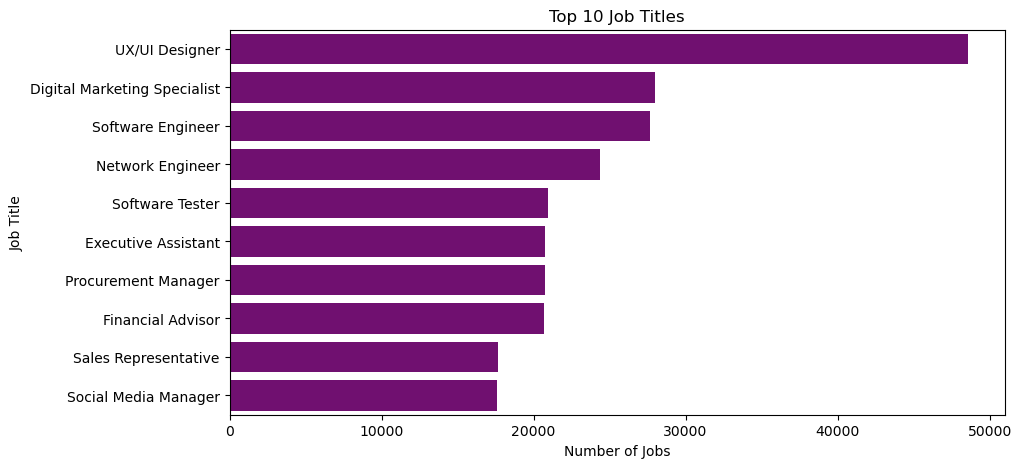

In [15]:
# Top 10 Job Titles
top_titles = df["Job Title"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, color="purple")

plt.title("Top 10 Job Titles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")
plt.show()

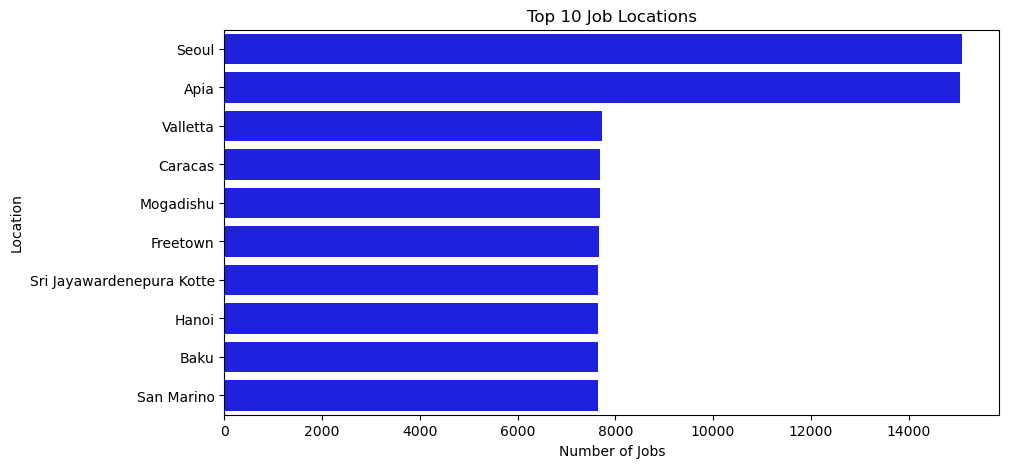

In [16]:
# Top 10 Locations
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_locations.values, y=top_locations.index, color="blue")

plt.title("Top 10 Job Locations")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.show()

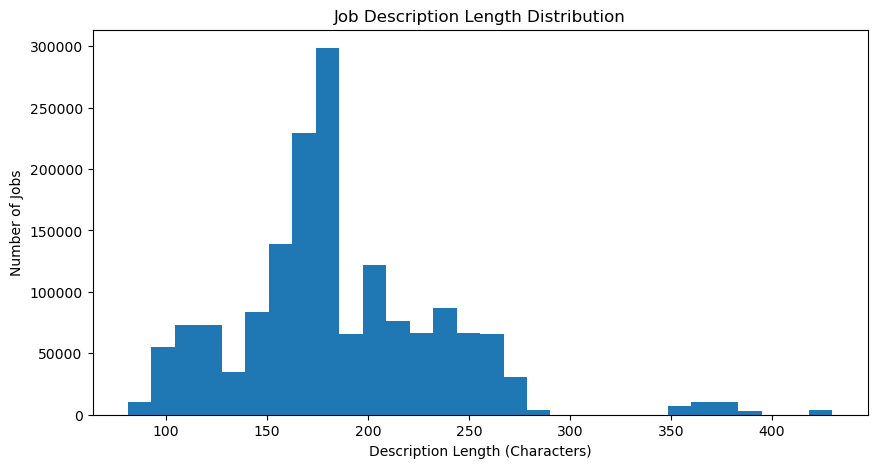

In [17]:
# Job Description Length Distribution
description_length = df["Job Description"].str.len()

plt.figure(figsize=(10, 5))

plt.hist(description_length, bins=30)

plt.title("Job Description Length Distribution")
plt.xlabel("Description Length (Characters)")
plt.ylabel("Number of Jobs")

plt.show()

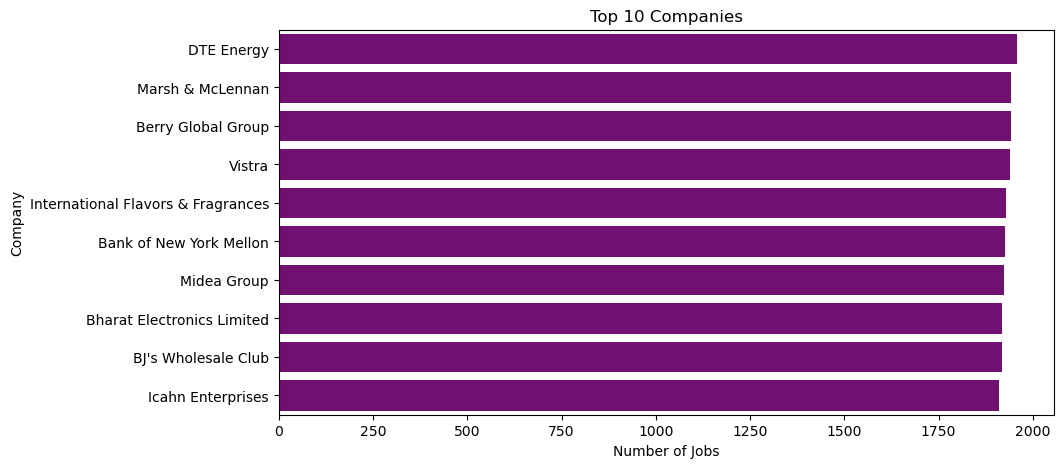

In [18]:
# Top 10 Companies
top_companies = df["Company"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_companies.values, y=top_companies.index, color="purple")

plt.title("Top 10 Companies")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")
plt.show()

In [19]:
import re
def clean_text(text):
    text = str(text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove phone numbers
    text = re.sub(r"\b\d{10}\b", " ", text)
    
    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    # Convert to lowercase
    text = text.lower()
    
    return text.strip()

In [20]:
df["clean_description"] = df["Job Description"].apply(clean_text)

In [21]:
df[["Job Description", "clean_description"]].head()

,Job Description,clean_description
0,Social Media Managers oversee an organizations...,social media managers oversee an organizations...
1,Frontend Web Developers design and implement u...,frontend web developers design and implement u...
2,Quality Control Managers establish and enforce...,quality control managers establish and enforce...
3,"Wireless Network Engineers design, implement, ...",wireless network engineers design implement an...
4,A Conference Manager coordinates and manages c...,a conference manager coordinates and manages c...


In [22]:
df.to_csv("clean_jobs.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [23]:
df

,Job Id,Experience,Qualifications,Salary Range,location,Country,Work Type,Job Posting Date,Preference,Contact Person,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,clean_description
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,Intern,2022-04-24,Female,Brandon Cunningham,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,social media managers oversee an organizations...
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,Intern,2022-12-19,Female,Francisco Larsen,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,frontend web developers design and implement u...
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",Temporary,2022-09-14,Male,Gary Gibson,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,quality control managers establish and enforce...
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,Full-Time,2023-02-25,Female,Joy Lucero,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,wireless network engineers design implement an...
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,Intern,2022-10-11,Female,Julie Johnson,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,a conference manager coordinates and manages c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615935,134563577088850,0 to 12 Years,B.Tech,$64K-$114K,"Malabo (de jure),",Equatorial Guinea,Full-Time,2022-05-19,Both,Shawn Cortez,950-451-5843,Mechanical Engineer,Mechanical Design Engineer,ZipRecruiter,Mechanical Design Engineers create and develop...,"{'Employee Assistance Programs (EAP), Tuition ...","Mechanical engineering CAD software (e.g., Sol...","Design mechanical systems, components, and pro...",The Hershey Company,mechanical design engineers create and develop...
1615936,618604818190827,2 to 14 Years,M.Tech,$62K-$130K,Warsaw,Poland,Intern,2023-03-14,Male,Steven Diaz,676.387.1572x71877,IT Manager,IT Director,USAJOBS,An IT Director oversees an organizations IT de...,"{'Health Insurance, Retirement Plans, Paid Tim...",Strategic IT planning Leadership and managemen...,Provide strategic leadership for IT department...,EQT,an it director oversees an organizations it de...
1615937,615471367712200,4 to 15 Years,BCA,$60K-$96K,Ashgabat,Turkmenistan,Part-Time,2022-01-23,Female,Bryan Morales,537.384.6193x5284,Mechanical Engineer,Mechanical Design Engineer,Indeed,Mechanical Design Engineers create and develop...,"{'Tuition Reimbursement, Stock Options or Equi...","Mechanical engineering CAD software (e.g., Sol...","Design mechanical systems, components, and pro...",KLA,mechanical design engineers create and develop...
1615938,804137342023945,5 to 15 Years,BCA,$65K-$103K,Ouagadougou,Burkina Faso,Full-Time,2021-12-28

# Skill Taxonomy

In [24]:
taxonomy = [
    
    # Programming
    ["Python", "Programming", "python, python3"],
    ["Java", "Programming", "java"],
    ["C++", "Programming", "c++, cpp"],
    ["JavaScript", "Programming", "javascript, js"],
    
    # Web Development
    ["HTML", "Web Development", "html, html5"],
    ["CSS", "Web Development", "css, css3"],
    ["React", "Web Development", "react, reactjs, react.js"],
    ["Angular", "Web Development", "angular, angularjs"],
    
    # Database
    ["SQL", "Database", "sql"],
    ["MySQL", "Database", "mysql"],
    ["PostgreSQL", "Database", "postgres, postgresql"],
    ["MongoDB", "Database", "mongodb, mongo"],
    
    # Data Analytics
    ["Power BI", "Data Analytics", "power bi, powerbi, power-bi"],
    ["Tableau", "Data Analytics", "tableau"],
    ["Excel", "Data Analytics", "excel, ms excel, microsoft excel"],
    ["Pandas", "Data Analytics", "pandas"],
    ["NumPy", "Data Analytics", "numpy"],
    
    # Machine Learning
    ["Machine Learning", "Machine Learning", "machine learning, ml"],
    ["Scikit-learn", "Machine Learning", "scikit learn, scikit-learn, sklearn"],
    ["TensorFlow", "Machine Learning", "tensorflow"],
    ["PyTorch", "Machine Learning", "pytorch"],
    
    # Cloud
    ["AWS", "Cloud", "aws, amazon web services"],
    ["Azure", "Cloud", "azure, microsoft azure"],
    ["GCP", "Cloud", "gcp, google cloud"],
    
    # Big Data
    ["Spark", "Big Data", "spark, apache spark, pyspark"],
    ["Hadoop", "Big Data", "hadoop, apache hadoop"],
    ["Kafka", "Big Data", "kafka, apache kafka"],
    
    # DevOps
    ["Git", "DevOps", "git"],
    ["GitHub", "DevOps", "github"],
    ["Docker", "DevOps", "docker"],
    ["Kubernetes", "DevOps", "kubernetes, k8s"],
    
    # Networking
    ["TCP/IP", "Networking", "tcp/ip, tcp ip"],
    ["Wi-Fi", "Networking", "wi-fi, wifi"],
    ["Networking", "Networking", "networking, computer networking"],
    
    # Project Management
    ["Agile", "Project Management", "agile"],
    ["Scrum", "Project Management", "scrum"],
    ["Jira", "Project Management", "jira"],
    
    # HR
    ["Recruitment", "Human Resources", "recruitment, recruiting"],
    ["Talent Acquisition", "Human Resources", "talent acquisition"],
    ["Employee Training", "Human Resources", "employee training, training"],
    
    # Marketing
    ["Digital Marketing", "Marketing", "digital marketing"],
    ["SEO", "Marketing", "seo, search engine optimization"],
    ["Social Media Marketing", "Marketing", "social media marketing"],
    ["Content Marketing", "Marketing", "content marketing"],
    
    # Engineering
    ["CAD", "Engineering", "cad, computer aided design"],
    ["AutoCAD", "Engineering", "autocad"],
    ["Mechanical Design", "Engineering", "mechanical design"],
    
    # Soft Skills
    ["Communication", "Soft Skills", "communication, communication skills"],
    ["Leadership", "Soft Skills", "leadership"],
    ["Problem Solving", "Soft Skills", "problem solving, problem-solving"],
    ["Teamwork", "Soft Skills", "teamwork, team work"]
]

skill_taxonomy = pd.DataFrame(
    taxonomy,
    columns=["skill", "category", "aliases"]
)

In [25]:
skill_taxonomy.to_csv(
    "skill_taxonomy.csv",
    index=False
)

print("skill_taxonomy.csv created successfully!")

skill_taxonomy.csv created successfully!


In [26]:
skill_taxonomy.head(20)

,skill,category,aliases
0,Python,Programming,"python, python3"
1,Java,Programming,java
2,C++,Programming,"c++, cpp"
3,JavaScript,Programming,"javascript, js"
4,HTML,Web Development,"html, html5"
5,CSS,Web Development,"css, css3"
6,React,Web Development,"react, reactjs, react.js"
7,Angular,Web Development,"angular, angularjs"
8,SQL,Database,sql
9,MySQL,Database,mysql


In [27]:
print("Total skills in taxonomy:", len(skill_taxonomy))
print("\nCategories:")
print(skill_taxonomy["category"].value_counts())

Total skills in taxonomy: 51

Categories:
category
Data Analytics        5
Programming           4
Web Development       4
Database              4
Machine Learning      4
DevOps                4
Marketing             4
Soft Skills           4
Cloud                 3
Big Data              3
Networking            3
Project Management    3
Human Resources       3
Engineering           3
Name: count, dtype: int64


# NLP Preprocessing

In [28]:
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

In [29]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91838\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91838\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91838\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91838\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\91838\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [30]:
df["clean_description"].head()

0    social media managers oversee an organizations...
1    frontend web developers design and implement u...
2    quality control managers establish and enforce...
3    wireless network engineers design implement an...
4    a conference manager coordinates and manages c...
Name: clean_description, dtype: str

In [31]:
test_df = df.head(1000).copy()

print(test_df.shape)

(1000, 20)


# Tokenization

In [32]:
test_df["tokens"] = test_df["Job Description"].apply(
    word_tokenize
)

In [33]:
display(
    test_df[
        ["Job Title", "tokens"]
    ].head(5)
)

,Job Title,tokens
0,Digital Marketing Specialist,"[Social, Media, Managers, oversee, an, organiz..."
1,Web Developer,"[Frontend, Web, Developers, design, and, imple..."
2,Operations Manager,"[Quality, Control, Managers, establish, and, e..."
3,Network Engineer,"[Wireless, Network, Engineers, design, ,, impl..."
4,Event Manager,"[A, Conference, Manager, coordinates, and, man..."


# Lowercasing

In [34]:
test_df["lowercase_text"] = test_df["Job Description"].str.lower()

In [35]:
print(test_df.loc[0, "lowercase_text"])

social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.


# Stopword Removal

In [36]:
stop_words = set(stopwords.words("english"))
test_df["tokens_no_stopwords"] = test_df["tokens"].apply(
    lambda tokens: [
        word for word in tokens
        if word.lower() not in stop_words
        and word.isalpha()
    ]
)
display(
    test_df[
        ["Job Title", "tokens", "tokens_no_stopwords"]
    ].head(5)
)

,Job Title,tokens,tokens_no_stopwords
0,Digital Marketing Specialist,"[Social, Media, Managers, oversee, an, organiz...","[Social, Media, Managers, oversee, organizatio..."
1,Web Developer,"[Frontend, Web, Developers, design, and, imple...","[Frontend, Web, Developers, design, implement,..."
2,Operations Manager,"[Quality, Control, Managers, establish, and, e...","[Quality, Control, Managers, establish, enforc..."
3,Network Engineer,"[Wireless, Network, Engineers, design, ,, impl...","[Wireless, Network, Engineers, design, impleme..."
4,Event Manager,"[A, Conference, Manager, coordinates, and, man...","[Conference, Manager, coordinates, manages, co..."


# Lemmatization

In [37]:
lemmatizer = WordNetLemmatizer()
test_df["lemmatized_tokens"] = test_df["tokens_no_stopwords"].apply(
    lambda tokens: [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
)
display(
    test_df[
        ["Job Title", "tokens_no_stopwords", "lemmatized_tokens"]
    ].head(5)
)

,Job Title,tokens_no_stopwords,lemmatized_tokens
0,Digital Marketing Specialist,"[Social, Media, Managers, oversee, organizatio...","[Social, Media, Managers, oversee, organizatio..."
1,Web Developer,"[Frontend, Web, Developers, design, implement,...","[Frontend, Web, Developers, design, implement,..."
2,Operations Manager,"[Quality, Control, Managers, establish, enforc...","[Quality, Control, Managers, establish, enforc..."
3,Network Engineer,"[Wireless, Network, Engineers, design, impleme...","[Wireless, Network, Engineers, design, impleme..."
4,Event Manager,"[Conference, Manager, coordinates, manages, co...","[Conference, Manager, coordinate, manages, con..."


# Stemming

In [38]:
stemmer = PorterStemmer()
test_df["stemmed_tokens"] = test_df["tokens_no_stopwords"].apply(
    lambda tokens: [
        stemmer.stem(word)
        for word in tokens
    ]
)


In [39]:
comparison = test_df[
    [
        "Job Title",
        "lemmatized_tokens",
        "stemmed_tokens"
    ]
].head(10)

display(comparison)

,Job Title,lemmatized_tokens,stemmed_tokens
0,Digital Marketing Specialist,"[Social, Media, Managers, oversee, organizatio...","[social, media, manag, overse, organ, social, ..."
1,Web Developer,"[Frontend, Web, Developers, design, implement,...","[frontend, web, develop, design, implement, us..."
2,Operations Manager,"[Quality, Control, Managers, establish, enforc...","[qualiti, control, manag, establish, enforc, q..."
3,Network Engineer,"[Wireless, Network, Engineers, design, impleme...","[wireless, network, engin, design, implement, ..."
4,Event Manager,"[Conference, Manager, coordinate, manages, con...","[confer, manag, coordin, manag, confer, meet, ..."
5,Software Tester,"[Quality, Assurance, Analyst, test, software, ...","[qualiti, assur, analyst, test, softwar, produ..."
6,Teacher,"[Classroom, Teacher, educates, student, specif...","[classroom, teacher, educ, student, specif, su..."
7,UX/UI Designer,"[User, Interface, Designers, focus, visual, in...","[user, interfac, design, focu, visual, interac..."
8,UX/UI Designer,"[Interaction, Designers, specialize, designing...","[interact, design, special, design, user, inte..."
9,Wedding Planner,"[Wedding, Consultant, assist, couple, planning...","[wed, consult, assist, coupl, plan, coordin, w..."


# Sentence Segmentation

In [40]:
test_df["sentences"] = test_df["Job Description"].apply(
    sent_tokenize
)
display(
    test_df[
        ["Job Title", "sentences"]
    ].head(5)
)

,Job Title,sentences
0,Digital Marketing Specialist,[Social Media Managers oversee an organization...
1,Web Developer,[Frontend Web Developers design and implement ...
2,Operations Manager,[Quality Control Managers establish and enforc...
3,Network Engineer,"[Wireless Network Engineers design, implement,..."
4,Event Manager,[A Conference Manager coordinates and manages ...


In [41]:
test_df["clean_text"] = test_df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

In [42]:
row = test_df.iloc[0]

print("JOB TITLE:")
print(row["Job Title"])

print("\n1. ORIGINAL:")
print(row["Job Description"])

print("\n2. TOKENS:")
print(row["tokens"])

print("\n3. LOWERCASE:")
print(row["lowercase_text"])

print("\n4. WITHOUT STOPWORDS:")
print(row["tokens_no_stopwords"])

print("\n5. LEMMATIZATION:")
print(row["lemmatized_tokens"])

print("\n6. STEMMING:")
print(row["stemmed_tokens"])

print("\n7. SENTENCES:")
print(row["sentences"])

print("\n8. FINAL CLEAN TEXT:")
print(row["clean_text"])

JOB TITLE:
Digital Marketing Specialist

1. ORIGINAL:
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

2. TOKENS:
['Social', 'Media', 'Managers', 'oversee', 'an', 'organizations', 'social', 'media', 'presence', '.', 'They', 'create', 'and', 'schedule', 'content', ',', 'engage', 'with', 'followers', ',', 'and', 'analyze', 'social', 'media', 'metrics', 'to', 'drive', 'brand', 'awareness', 'and', 'engagement', '.']

3. LOWERCASE:
social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

4. WITHOUT STOPWORDS:
['Social', 'Media', 'Managers', 'oversee', 'organizations', 'social', 'media', 'presence', 'create', 'schedule', 'content', 'engage', 'followers', 'analyze', 'social', 'media', 'metrics', 'dri

# Skill Extractor

In [43]:
skill_taxonomy = pd.read_csv("skill_taxonomy.csv")

skill_taxonomy.head()

,skill,category,aliases
0,Python,Programming,"python, python3"
1,Java,Programming,java
2,C++,Programming,"c++, cpp"
3,JavaScript,Programming,"javascript, js"
4,HTML,Web Development,"html, html5"


In [44]:
# Display only Job Title and Job Description
test_df[["Job Title", "Job Description"]].head(20)

,Job Title,Job Description
0,Digital Marketing Specialist,Social Media Managers oversee an organizations...
1,Web Developer,Frontend Web Developers design and implement u...
2,Operations Manager,Quality Control Managers establish and enforce...
3,Network Engineer,"Wireless Network Engineers design, implement, ..."
4,Event Manager,A Conference Manager coordinates and manages c...
5,Software Tester,A Quality Assurance Analyst tests software and...
6,Teacher,A Classroom Teacher educates students in a spe...
7,UX/UI Designer,User Interface Designers focus on the visual a...
8,UX/UI Designer,Interaction Designers specialize in designing ...
9,Wedding Planner,A Wedding Consultant assists couples in planni...


In [46]:
# from IPython.display import display

# job_data = df[["Job Title", "Job Description", "skills"]].copy()

# display(
#     job_data.head(20).style
#     .set_properties(**{
#         "text-align": "left",
#         "white-space": "normal"
#     })
#     .set_table_styles([
#         {
#             "selector": "th",
#             "props": [
#                 ("text-align", "left")
#             ]
#         }
#     ])
# )
from IPython.display import display

job_data = df[["Job Title", "Job Description", "skills"]].copy()

display(job_data.head(20))

,Job Title,Job Description,skills
0,Digital Marketing Specialist,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte..."
1,Web Developer,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g..."
2,Operations Manager,Quality Control Managers establish and enforce...,Quality control processes and methodologies St...
3,Network Engineer,"Wireless Network Engineers design, implement, ...",Wireless network design and architecture Wi-Fi...
4,Event Manager,A Conference Manager coordinates and manages c...,Event planning Conference logistics Budget man...
5,Software Tester,A Quality Assurance Analyst tests software and...,Quality assurance processes Testing methodolog...
6,Teacher,A Classroom Teacher educates students in a spe...,Teaching pedagogy Classroom management Curricu...
7,UX/UI Designer,User Interface Designers focus on the visual a...,UI design principles and best practices Graphi...
8,UX/UI Designer,Interaction Designers specialize in designing ...,Interaction design principles User behavior an...
9,Wedding Planner,A Wedding Consultant assists couples in planni...,Wedding planning Vendor coordination Event man...


In [47]:
import re
import pandas as pd

skill_patterns = {
    "Social Media": [
        "social media",
        "social media presence",
        "social media platforms"
    ],
    
    "Content Creation": [
        "create content",
        "creating content",
        "content creation",
        "content development",
        "create and schedule content"
    ],
    
    "Content Scheduling": [
        "schedule content",
        "scheduling content",
        "content scheduling"
    ],
    
    "Social Media Analytics": [
        "social media metrics",
        "social media analytics",
        "analytics and insights"
    ],
    
    "Community Engagement": [
        "community engagement",
        "engage with followers",
        "audience engagement"
    ],
    
    "Brand Awareness": [
        "brand awareness"
    ],
    
    "Paid Social Advertising": [
        "paid social advertising",
        "social advertising"
    ],
    "Web Development": [
    "web development",
    "web developer",
    "web developers",
    "frontend development",
    "front-end development",
    "backend development",
    "back-end development",
    "website development",
    "web application development",
    "web applications",
    "websites",
    "user interfaces",
    "user interface"
],

    "HTML": ["html"],
    "CSS": ["css"],
    "JavaScript": ["javascript"],
    "React": ["react"],
    "Angular": ["angular"],
    "UX": ["user experience", "ux"],
    "UI Design": ["ui design", "user interface"],
    
    "Quality Control": [
        "quality control",
        "quality standards"
    ],

    "UX/UI Designer": [
        "UI Design",
        "UX Design",
        "User Experience",
        "User Interface",
        "Interaction Design",
        "Wireframing",
        "Prototyping",
        "Visual Design"
    ],

    "Social Worker": [
        "Social Work",
        "Case Management",
        "Counseling",
        "Crisis Management",
        "Family Support",
        "Community Outreach",
        "Advocacy",
        "Communication"
    ],
    "Statistical Process Control": [
        "statistical process control",
        "spc"
    ],
    
    "Root Cause Analysis": [
        "root cause analysis"
    ],
    
    "ISO 9001": [
        "iso 9001"
    ],

    "Wireless Networking": [
        "wireless network",
        "wireless network solutions",
        "wireless network design"
    ],
    
    "Wi-Fi": [
        "wi-fi",
        "wifi",
        "wi-fi standards"
    ],
    
    "Network Security": [
        "network security",
        "wireless security"
    ],
    
    "Troubleshooting": [
        "troubleshoot",
        "troubleshooting"
    ],

    "Event Planning": [
        "event planning",
        "planning events"
    ],
    
    "Conference Management": [
        "conference",
        "conference logistics"
    ],
    
    "Budget Management": [
        "budget management",
        "budgeting"
    ],
    
    "Vendor Coordination": [
        "vendor coordination",
        "liaise with vendors"
    ],

    "Quality Assurance": [
        "quality assurance",
        "quality standards"
    ],
    
    "Software Testing": [
        "software testing",
        "testing software"
    ],
    
    "Manual Testing": [
        "manual testing"
    ],
    
    "Automation Testing": [
        "automated testing",
        "automation testing"
    ],
    
    "Bug Tracking": [
        "bug tracking",
        "report issues",
        "defects"
    ],
    
    "Regression Testing": [
        "regression testing"
    ],

    "Teaching": [
        "teaching",
        "educates students",
        "deliver instruction"
    ],
    
    "Classroom Management": [
        "classroom management"
    ],
    
    "Lesson Planning": [
        "lesson plans",
        "lesson planning"
    ],
    
    "Student Assessment": [
        "student assessment",
        "assess student progress"
    ],

    "Graphic Design": [
        "graphic design",
        "graphic design tools"
    ],
    
    "Adobe Photoshop": [
        "adobe photoshop",
        "photoshop"
    ],
    
    "Adobe Illustrator": [
        "adobe illustrator",
        "illustrator"
    ],
    
    "Typography": [
        "typography"
    ],
    
    "Responsive Design": [
        "responsive design"
    ],

    "Wedding Planning": [
        "wedding planning",
        "planning weddings"
    ],
    
    "Event Management": [
        "event management"
    ],

    "Performance Testing": [
        "performance testing"
    ],
    
    "Load Testing": [
        "load testing"
    ],
    
    "Stress Testing": [
        "stress testing"
    ],
    
    "Performance Monitoring": [
        "performance monitoring"
    ],
    
    "Benchmarking": [
        "benchmarking"
    ],

    "Family Law": [
        "family law",
        "family relationships"
    ],
    
    "Legal Counseling": [
        "legal guidance",
        "legal counseling"
    ],
    
    "Mediation": [
        "mediation"
    ],

    "Mechanical Engineering": [
        "mechanical engineering",
        "mechanical systems",
        "mechanical components"
    ],
    
    "CAD": [
        "cad software",
        "cad"
    ],
    
    "SolidWorks": [
        "solidworks"
    ],
    
    "AutoCAD": [
        "autocad"
    ],
    
    "Finite Element Analysis": [
        "finite element analysis"
    ],
    
    "Prototyping": [
        "prototyping"
    ],

    "Network Security": [
        "network security protocols",
        "computer networks",
        "security threats"
    ],
    
    "Intrusion Detection": [
        "intrusion detection",
        "intrusion prevention"
    ],
    
    "Firewall Administration": [
        "firewall administration",
        "firewall"
    ],
    
    "Vulnerability Assessment": [
        "vulnerability assessment"
    ],
    
    "Ethical Hacking": [
        "ethical hacking"
    ],
    
    "Log Analysis": [
        "log analysis"
    ],

    "Account Management": [
        "account management",
        "maintaining relationships with clients"
    ],
    
    "Sales": [
        "sales",
        "sales targets"
    ],
    
    "Sales Strategy": [
        "sales strategy"
    ],
    
    "Negotiation": [
        "negotiation",
        "negotiating"
    ],

    "Product Branding": [
        "product branding",
        "brand identity"
    ],
    
    "Product Marketing": [
        "product marketing"
    ],
    
    "Product Lifecycle Management": [
        "product lifecycle management"
    ],
    
    "Market Segmentation": [
        "market segmentation"
    ],

    "Social Work": [
        "social work",
        "social worker",
        "school social work"
    ],
    
    "Crisis Management": [
        "crisis management"
    ],
    
    "Family Engagement": [
        "family engagement"
    ],
    
    "Advocacy": [
        "advocacy"
    ],

    "SEO": [
        "seo",
        "seo optimization",
        "search engine optimization"
    ],
    
    "Content Marketing": [
        "content marketing"
    ],
    
    "Creative Storytelling": [
        "creative storytelling"
    ],
    
    "Analytics": [
        "analytics",
        "analytics and reporting"
    ],

    "Email Deliverability": [
        "email deliverability",
        "deliverability rates"
    ],
    
    "Spam Filter Testing": [
        "spam filter testing"
    ],
    
    "Email Authentication": [
        "email authentication",
        "spf",
        "dkim"
    ],
    
    "Data Analysis": [
        "data analysis",
        "data analysis"
    ],

    "Recruitment": [
        "recruitment",
        "recruiting"
    ],
    
    "Employee Onboarding": [
        "employee onboarding",
        "onboarding"
    ],
    
    "HRIS": [
        "hris",
        "human resources information system"
    ],
    
    "Record Keeping": [
        "record keeping",
        "employee record maintenance"
    ]
}


def extract_skills_fast(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    found_skills = []

    for skill, patterns in skill_patterns.items():
        for pattern in patterns:
            if re.search(r'(?<!\w)' + re.escape(pattern.lower()) + r'(?!\w)', text):
                found_skills.append(skill)
                break

    return found_skills

In [48]:
test_df = df.head(1000).copy()

test_df["extracted_skills"] = (
    test_df["Job Description"]
    .fillna("")
    .apply(extract_skills_fast)
)

result = test_df[
    ["Job Title", "Job Description", "extracted_skills"]
].copy()

display(result.head(20))

,Job Title,Job Description,extracted_skills
0,Digital Marketing Specialist,Social Media Managers oversee an organizations...,"[Social Media, Content Creation, Content Sched..."
1,Web Developer,Frontend Web Developers design and implement u...,[Web Development]
2,Operations Manager,Quality Control Managers establish and enforce...,"[Quality Control, Quality Assurance]"
3,Network Engineer,"Wireless Network Engineers design, implement, ...","[Wireless Networking, Troubleshooting]"
4,Event Manager,A Conference Manager coordinates and manages c...,"[Conference Management, Budget Management, Ven..."
5,Software Tester,A Quality Assurance Analyst tests software and...,"[Quality Control, Quality Assurance, Bug Track..."
6,Teacher,A Classroom Teacher educates students in a spe...,"[Teaching, Lesson Planning, Student Assessment]"
7,UX/UI Designer,User Interface Designers focus on the visual a...,"[Web Development, UI Design, UX/UI Designer]"
8,UX/UI Designer,Interaction Designers specialize in designing ...,[]
9,Wedding Planner,A Wedding Consultant assists couples in planni...,[Budget Management]


In [49]:
skill_taxonomy = {
    # Programming
    "Python": ["python"],
    "Java": ["java"],
    "JavaScript": ["javascript", "java script"],
    "C++": ["c++"],
    "C#": ["c#", "c sharp"],
    "R": ["r programming", "r language"],

    # Web Development
    "HTML": ["html"],
    "CSS": ["css"],
    "React": ["react", "react.js", "reactjs"],
    "Angular": ["angular", "angular.js", "angularjs"],
    "Vue.js": ["vue", "vue.js", "vuejs"],
    "Node.js": ["node.js", "nodejs", "node"],
    "Web Development": [
        "web development",
        "frontend development",
        "front-end development",
        "backend development",
        "back-end development",
        "website development",
        "web application development"
    ],

    # Database
    "SQL": ["sql", "structured query language"],
    "MySQL": ["mysql"],
    "PostgreSQL": ["postgresql", "postgres"],
    "MongoDB": ["mongodb", "mongo db"],
    "Oracle": ["oracle database", "oracle"],

    # Data
    "Data Analysis": ["data analysis", "data analytics"],
    "Data Science": ["data science"],
    "Data Visualization": ["data visualization", "data visualisation"],
    "Machine Learning": ["machine learning"],
    "Deep Learning": ["deep learning"],
    "NLP": ["nlp", "natural language processing"],
    "Pandas": ["pandas"],
    "NumPy": ["numpy"],

    # Cloud
    "AWS": ["aws", "amazon web services"],
    "Azure": ["azure", "microsoft azure"],
    "Google Cloud": ["google cloud", "gcp"],
    "Docker": ["docker"],
    "Kubernetes": ["kubernetes"],

    # Testing
    "Software Testing": ["software testing"],
    "Manual Testing": ["manual testing"],
    "Automation Testing": ["automation testing", "automated testing"],
    "Selenium": ["selenium"],
    "API Testing": ["api testing"],
    "Regression Testing": ["regression testing"],

    # Digital Marketing
    "Digital Marketing": ["digital marketing"],
    "Social Media": ["social media"],
    "Social Media Marketing": ["social media marketing"],
    "Email Marketing": ["email marketing"],
    "SEO": ["seo", "search engine optimization"],
    "SEM": ["sem", "search engine marketing"],
    "Content Marketing": ["content marketing"],
    "Content Creation": ["content creation"],
    "Google Ads": ["google ads"],
    "Google Analytics": ["google analytics"],

    # UI/UX
    "UI Design": ["ui design", "user interface"],
    "UX Design": ["ux design", "user experience"],
    "Interaction Design": ["interaction design"],
    "Wireframing": ["wireframing", "wireframes"],
    "Prototyping": ["prototyping", "prototype"],
    "Figma": ["figma"],

    # HR
    "Recruitment": ["recruitment", "recruiting"],
    "Talent Acquisition": ["talent acquisition"],
    "Employee Training": ["employee training"],
    "Onboarding": ["onboarding"],
    "Human Resources": ["human resources", "hr"],

    # Business
    "Sales": ["sales", "sales management"],
    "Account Management": ["account management"],
    "Customer Service": ["customer service", "customer support"],
    "Project Management": ["project management"],
    "Communication": ["communication skills"],
    "Negotiation": ["negotiation"],
    "Leadership": ["leadership"],
    "Team Management": ["team management"],

    # Engineering
    "Mechanical Engineering": ["mechanical engineering"],
    "Mechanical Design": ["mechanical design"],
    "AutoCAD": ["autocad", "auto cad"],
    "SolidWorks": ["solidworks", "solid works"],
    "CAD": ["cad", "cad software"],
    "Finite Element Analysis": ["finite element analysis"],

    # Networking
    "Networking": ["networking", "computer networks"],
    "Network Security": ["network security"],
    "Firewall": ["firewall", "firewall administration"],
    "Intrusion Detection": ["intrusion detection"],
    "Vulnerability Assessment": ["vulnerability assessment"],

    # Social Work
    "Social Work": ["social work"],
    "Counseling": ["counseling", "counselling"],
    "Crisis Management": ["crisis management"],
    "Advocacy": ["advocacy"],
    "Family Engagement": ["family engagement"],
    "Community Outreach": ["community outreach"]
}

In [50]:
import re
import pandas as pd

def apply_skill_taxonomy(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    standardized_skills = []

    for standard_skill, variations in skill_taxonomy.items():

        for variation in variations:

            pattern = r'(?<!\w)' + re.escape(variation.lower()) + r'(?!\w)'

            if re.search(pattern, text):
                standardized_skills.append(standard_skill)
                break

    return list(dict.fromkeys(standardized_skills))

In [51]:
import re
import pandas as pd

def clean_skill_text(text):
    if pd.isna(text):
        return []

    text = str(text)

    # Split skills using common separators
    skills = re.split(r'\n|;|\||,', text)

    cleaned = []

    for skill in skills:
        skill = skill.strip()

        if skill:
            cleaned.append(skill)

    return cleaned

In [52]:
test_df = df.head(1000).copy()

test_df["extracted_skills"] = (
    test_df["skills"]
    .fillna("")
    .apply(clean_skill_text)
)

In [53]:
display(
    test_df[
        ["Job Title", "skills", "extracted_skills"]
    ].head(20)
)

,Job Title,skills,extracted_skills
0,Digital Marketing Specialist,"Social media platforms (e.g., Facebook, Twitte...","[Social media platforms (e.g., Facebook, Twitt..."
1,Web Developer,"HTML, CSS, JavaScript Frontend frameworks (e.g...","[HTML, CSS, JavaScript Frontend frameworks (e...."
2,Operations Manager,Quality control processes and methodologies St...,[Quality control processes and methodologies S...
3,Network Engineer,Wireless network design and architecture Wi-Fi...,[Wireless network design and architecture Wi-F...
4,Event Manager,Event planning Conference logistics Budget man...,[Event planning Conference logistics Budget ma...
5,Software Tester,Quality assurance processes Testing methodolog...,[Quality assurance processes Testing methodolo...
6,Teacher,Teaching pedagogy Classroom management Curricu...,[Teaching pedagogy Classroom management Curric...
7,UX/UI Designer,UI design principles and best practices Graphi...,[UI design principles and best practices Graph...
8,UX/UI Designer,Interaction design principles User behavior an...,[Interaction design principles User behavior a...
9,Wedding Planner,Wedding planning Vendor coordination Event man...,[Wedding planning Vendor coordination Event ma...


In [54]:
skill_taxonomy = {

    # Quality
    "Quality Control": [
        "quality control",
        "quality control processes",
        "quality standards"
    ],

    "Statistical Process Control": [
        "statistical process control",
        "spc"
    ],

    "Root Cause Analysis": [
        "root cause analysis",
        "corrective action"
    ],

    "Quality Management": [
        "quality management systems",
        "quality management"
    ],

    # Networking
    "Wireless Networking": [
        "wireless network",
        "wireless network design",
        "wireless network architecture"
    ],

    "Wi-Fi": [
        "wi-fi",
        "wifi",
        "wi-fi standards"
    ],

    "Network Security": [
        "network security",
        "wireless security",
        "security protocols"
    ],

    "RF Planning": [
        "rf planning",
        "rf planning and optimization"
    ],

    # Events
    "Event Planning": [
        "event planning",
        "event management"
    ],

    "Conference Management": [
        "conference logistics",
        "conference management"
    ],

    "Budget Management": [
        "budget management",
        "budgeting"
    ],

    "Vendor Coordination": [
        "vendor coordination"
    ],

    # Testing
    "Software Testing": [
        "software testing",
        "testing methodologies"
    ],

    "Manual Testing": [
        "manual testing"
    ],

    "Automation Testing": [
        "automated testing",
        "automation testing"
    ],

    "Bug Tracking": [
        "bug tracking",
        "bug reporting"
    ],

    "Regression Testing": [
        "regression testing"
    ],

    "Performance Testing": [
        "performance testing"
    ],

    "Load Testing": [
        "load testing"
    ],

    "Stress Testing": [
        "stress testing"
    ],

    "Performance Monitoring": [
        "performance monitoring"
    ],

    # Teaching
    "Teaching": [
        "teaching pedagogy",
        "teaching",
        "instruction"
    ],

    "Classroom Management": [
        "classroom management"
    ],

    "Curriculum Development": [
        "curriculum development"
    ],

    "Student Assessment": [
        "student assessment"
    ],

    "Differentiated Instruction": [
        "differentiated instruction"
    ],

    # UI/UX
    "UI Design": [
        "ui design",
        "user interface"
    ],

    "UX Design": [
        "ux design",
        "user experience"
    ],

    "Interaction Design": [
        "interaction design"
    ],

    "Wireframing": [
        "wireframing",
        "wireframe"
    ],

    "Prototyping": [
        "prototyping",
        "prototype"
    ],

    "Visual Design": [
        "visual design",
        "layout"
    ],

    # Wedding / Events
    "Wedding Planning": [
        "wedding planning"
    ],

    "Vendor Coordination": [
        "vendor coordination"
    ],

    "Event Management": [
        "event management"
    ],

    # Digital Marketing
    "Social Media": [
        "social media"
    ],

    "Content Creation": [
        "content creation",
        "content development"
    ],

    "Content Marketing": [
        "content marketing"
    ],

    "SEO": [
        "seo",
        "seo optimization"
    ],

    "Analytics": [
        "analytics",
        "analytics and reporting"
    ],

    # HR
    "Human Resources": [
        "human resources",
        "hr"
    ],

    "Recruitment": [
        "recruitment",
        "recruiting"
    ],

    "Employee Onboarding": [
        "employee onboarding",
        "onboarding"
    ],

    # Engineering
    "Mechanical Engineering": [
        "mechanical engineering"
    ],

    "CAD": [
        "cad",
        "cad software"
    ],

    "SolidWorks": [
        "solidworks"
    ],

    "AutoCAD": [
        "autocad"
    ]
}

In [55]:
test_df = df.head(1000).copy()

test_df["extracted_skills"] = (
    test_df["Job Description"]
    .fillna("")
    .apply(extract_skills_fast)
)

In [56]:
def normalize_skills(extracted_skills):

    if not extracted_skills:
        return []

    normalized = []

    for skill in extracted_skills:

        skill_text = str(skill).lower().strip()
        matched = False

        for standard_skill, variations in skill_taxonomy.items():

            for variation in variations:

                if variation.lower() in skill_text:
                    normalized.append(standard_skill)
                    matched = True
                    break

            if matched:
                break

        # Keep skill if no taxonomy match
        if not matched:
            normalized.append(skill)

    return list(dict.fromkeys(normalized))

In [57]:
test_df["standardized_skills"] = (
    test_df["extracted_skills"]
    .apply(normalize_skills)
)

In [58]:
result = test_df[
    ["Job Title", "Job Description", "extracted_skills"]
]

display(result.head(20))

,Job Title,Job Description,extracted_skills
0,Digital Marketing Specialist,Social Media Managers oversee an organizations...,"[Social Media, Content Creation, Content Sched..."
1,Web Developer,Frontend Web Developers design and implement u...,[Web Development]
2,Operations Manager,Quality Control Managers establish and enforce...,"[Quality Control, Quality Assurance]"
3,Network Engineer,"Wireless Network Engineers design, implement, ...","[Wireless Networking, Troubleshooting]"
4,Event Manager,A Conference Manager coordinates and manages c...,"[Conference Management, Budget Management, Ven..."
5,Software Tester,A Quality Assurance Analyst tests software and...,"[Quality Control, Quality Assurance, Bug Track..."
6,Teacher,A Classroom Teacher educates students in a spe...,"[Teaching, Lesson Planning, Student Assessment]"
7,UX/UI Designer,User Interface Designers focus on the visual a...,"[Web Development, UI Design, UX/UI Designer]"
8,UX/UI Designer,Interaction Designers specialize in designing ...,[]
9,Wedding Planner,A Wedding Consultant assists couples in planni...,[Budget Management]


# Improve Extraction Using Regex and Phrase Matching

In [59]:
# Create the working dataframe
test_df = df[
    ["Job Title", "Job Description", "skills"]
].copy()

test_df["Job Description"] = (
    test_df["Job Description"]
    .fillna("")
    .astype(str)
)

print(test_df.shape)

(1615940, 3)


In [60]:
test_df = test_df.head(1000).copy()

In [61]:
import re

regex_patterns = {

    # =========================================================
    # PROGRAMMING / WEB DEVELOPMENT
    # =========================================================

    "Python":
        r"\bpython(?:\s*3(?:\.\d+)?)?(?:\s+programming)?\b",

    "Java":
        r"\bjava\b",

    "JavaScript":
        r"\bjava\s*script\b|\bjavascript\b",

    "C++":
        r"\bc\+\+\b",

    "C#":
        r"\bc#\b",

    "HTML":
        r"\bhtml5?\b",

    "CSS":
        r"\bcss3?\b",

    "React":
        r"\breact(?:\.js|js)?\b",

    "Angular":
        r"\bangular(?:\.js|js)?\b",

    "Node.js":
        r"\bnode(?:\.js|js)?\b",

    "Frontend Development":
        r"\bfront[-\s]?end\s+(?:web\s+)?developers?\b"
        r"|\bfront[-\s]?end\s+(?:web\s+)?development\b",

    "Backend Development":
        r"\bback[-\s]?end\s+(?:web\s+)?developers?\b"
        r"|\bback[-\s]?end\s+(?:web\s+)?development\b",

    "Web Development":
        r"\bweb\s+development\b|\bweb\s+developers?\b",

    "User Experience":
        r"\buser\s+experience\b|\bux\b",

    "User Interface":
        r"\buser\s+interface\b|\bui\b",


    # =========================================================
    # DATABASE
    # =========================================================

    "SQL":
        r"\bsql\b",

    "MySQL":
        r"\bmysql\b",

    "PostgreSQL":
        r"\bpostgres(?:ql)?\b",

    "MongoDB":
        r"\bmongodb\b|\bmongo\s+db\b",

    "Oracle":
        r"\boracle\b",


    # =========================================================
    # DATA / BI
    # =========================================================

    "Power BI":
        r"\bpower\s*bi\b",

    "Power Query":
        r"\bpower\s+query\b",

    "Tableau":
        r"\btableau\b",

    "Excel":
        r"\b(?:microsoft\s+)?excel\b",

    "DAX":
        r"\bdax\b",

    "Machine Learning":
        r"\bmachine[-\s]+learning\b",

    "Deep Learning":
        r"\bdeep[-\s]+learning\b",

    "Natural Language Processing":
        r"\bnatural\s+language\s+processing\b|\bnlp\b",

    "Data Science":
        r"\bdata\s+science\b",

    "Data Analysis":
        r"\bdata\s+analysis\b|\bdata\s+analytics\b",

    "Data Visualization":
        r"\bdata\s+visuali[sz]ation\b",

    "Artificial Intelligence":
        r"\bartificial\s+intelligence\b|\bai\b",


    # =========================================================
    # CLOUD
    # =========================================================

    "AWS":
        r"\baws\b|\bamazon\s+web\s+services\b",

    "Azure":
        r"\bazure\b|\bmicrosoft\s+azure\b",

    "Google Cloud":
        r"\bgoogle\s+cloud\b|\bgcp\b",

    "Docker":
        r"\bdocker\b",

    "Kubernetes":
        r"\bkubernetes\b|\bk8s\b",


    # =========================================================
    # QUALITY ASSURANCE / TESTING
    # =========================================================

    "Quality Assurance":
        r"\bquality\s+assurance\b",

    "Software Testing":
        r"\bsoftware\s+testing\b|\btests?\s+software\b"
        r"|\btesting\s+methodolog(?:y|ies)\b",

    "Manual Testing":
        r"\bmanual\s+testing\b|\bmanual(?:ly)?\s+test(?:ing|ed)?\b",

    "Automation Testing":
        r"\bautomation\s+testing\b|\bautomated\s+testing\b"
        r"|\bautomation\b",

    "Regression Testing":
        r"\bregression\s+testing\b",

    "API Testing":
        r"\bapi\s+testing\b",

    "Performance Testing":
        r"\bperformance\s+testing\b",

    "Load Testing":
        r"\bload\s+testing\b",

    "Stress Testing":
        r"\bstress\s+testing\b",

    "Selenium":
        r"\bselenium\b",

    "Bug Tracking":
        r"\bbug\s+tracking\b|\bbug\s+tracking\s+and\s+reporting\b",

    "Test Case Development":
        r"\btest\s+case\s+development\b",

    "Test Scenarios":
        r"\btest\s+scenarios?\b",

    "Performance Monitoring":
        r"\bperformance\s+monitoring\b",

    "Benchmarking":
        r"\bbenchmarking\b",

    "Performance Analysis":
        r"\bperformance\s+analysis\b",

    "Defect Identification":
        r"\bidentif(?:y|ies|ying)\s+defects?\b",

    "Bug Reporting":
        r"\breport\s+(?:bugs?|issues?)\b",


    # =========================================================
    # DIGITAL MARKETING
    # =========================================================

    "Digital Marketing":
        r"\bdigital\s+marketing\b",

    "Social Media":
        r"\bsocial\s+media\b",

    "Social Media Management":
        r"\bsocial\s+media\s+management\b"
        r"|\bmanage\s+(?:an?\s+)?(?:organization'?s?\s+)?social\s+media\b",

    "Social Media Analytics":
        r"\bsocial\s+media\s+analytics\b|\bsocial\s+media\s+metrics?\b",

    "Content Creation":
        r"\bcontent\s+creation\b|\bcreate\s+and\s+schedule\s+content\b"
        r"|\bcreate\s+content\b",

    "Content Marketing":
        r"\bcontent\s+marketing\b",

    "Email Marketing":
        r"\bemail\s+marketing\b",

    "SEO":
        r"\bseo\b|\bsearch\s+engine\s+optimization\b",

    "Paid Social Advertising":
        r"\bpaid\s+social\s+advertising\b",

    "Community Engagement":
        r"\bcommunity\s+engagement\b|\bengage\s+with\s+followers\b",

    "Audience Engagement":
        r"\baudience\s+engagement\b",

    "Creative Storytelling":
        r"\bcreative\s+storytelling\b",

    "Analytics and Reporting":
        r"\banalytics\s+and\s+reporting\b",

    "Email Deliverability":
        r"\bemail\s+deliverability\b",

    "Spam Filter Testing":
        r"\bspam\s+filter\s+testing\b",

    "List Hygiene":
        r"\blist\s+hygiene\b",

    "Blacklist Monitoring":
        r"\bblacklist\s+monitoring\b",

    "Email Authentication":
        r"\bemail\s+authentication\b",

    "SPF":
        r"\bspf\b",

    "DKIM":
        r"\bdkim\b",

    "Deliverability Metrics":
        r"\bdeliverability\s+metrics?\b",

    "Data Analysis":
        r"\bdata\s+analysis\b|\bdata\s+analytics\b",


    # =========================================================
    # UI / UX
    # =========================================================

    "UI Design":
        r"\bui\s+design\b|\buser\s+interface\s+design\b"
        r"|\buser\s+interface\s+designers?\b",

    "UX Design":
        r"\bux\s+design\b|\buser\s+experience\s+design\b",

    "Interaction Design":
        r"\binteraction\s+design\b"
        r"|\bdesigning\s+user\s+interactions?\b",

    "Wireframing":
        r"\bwireframing\b|\bwireframes?\b",

    "Prototyping":
        r"\bprototyping\b|\bprototypes?\b",

    "Figma":
        r"\bfigma\b",

    "Graphic Design":
        r"\bgraphic\s+design\b",

    "Typography":
        r"\btypography\b",

    "Color Theory":
        r"\bcolor\s+theory\b",

    "Visual Design":
        r"\bvisual\s+design\b",

    "Responsive Design":
        r"\bresponsive\s+design\b",

    "User Behavior":
        r"\buser\s+behavio[u]?r\b",

    "Psychology":
        r"\bpsychology\b",

    "Animation":
        r"\banimation\b",

    "Micro-interaction Design":
        r"\bmicro[-\s]?interaction\s+design\b",

    "Collaborative Design":
        r"\bcollaborative\s+design\b",


    # =========================================================
    # BUSINESS / MANAGEMENT
    # =========================================================

    "Project Management":
        r"\bproject\s+management\b",

    "Operations Management":
        r"\boperations?\s+management\b",

    "Account Management":
        r"\baccount\s+management\b",

    "Sales":
        r"\bsales\b",

    "Sales Strategy":
        r"\bsales\s+strategy\b",

    "Negotiation":
        r"\bnegotiation\b",

    "Leadership":
        r"\bleadership\b",

    "Communication":
        r"\bcommunication(?:\s+skills?)?\b",

    "Customer Service":
        r"\bcustomer\s+service\b",

    "Client Relations":
        r"\bclient\s+relations?\b",

    "Relationship Management":
        r"\bbuilding\s+and\s+maintaining\s+relationships?\b",

    "Problem Solving":
        r"\bproblem[-\s]?solving\b",

    "Attention to Detail":
        r"\battention\s+to\s+detail\b",


    # =========================================================
    # QUALITY CONTROL
    # =========================================================

    "Quality Control":
        r"\bquality\s+control\b",

    "Quality Standards":
        r"\bquality\s+standards?\b",

    "Quality Control Processes":
        r"\bquality\s+control\s+processes?\b",

    "Statistical Process Control":
        r"\bstatistical\s+process\s+control\b|\bspc\b",

    "Root Cause Analysis":
        r"\broot\s+cause\s+analysis\b",

    "Corrective Action":
        r"\bcorrective\s+actions?\b",

    "Quality Management Systems":
        r"\bquality\s+management\s+systems?\b",

    "Compliance":
        r"\bcompliance\b",

    "Regulatory Knowledge":
        r"\bregulatory\s+knowledge\b",

    "Inspection":
        r"\binspections?\b",


    # =========================================================
    # NETWORK / SECURITY
    # =========================================================

    "Network Design":
        r"\bnetwork\s+design\b",

    "Network Architecture":
        r"\bnetwork\s+architecture\b",

    "Wireless Networking":
        r"\bwireless\s+network(?:ing)?\b",

    "Wireless Network Design":
        r"\bwireless\s+network\s+design\b",

    "Wi-Fi":
        r"\bwi[-\s]?fi\b",

    "Wi-Fi Standards":
        r"\bwi[-\s]?fi\s+standards?\b",

    "RF Planning":
        r"\brf\s*\(?radio\s+frequency\)?\s+planning\b"
        r"|\bradio\s+frequency\s+planning\b",

    "Wireless Security":
        r"\bwireless\s+security\b",

    "Network Security":
        r"\bnetwork\s+security\b",

    "Network Security Protocols":
        r"\bnetwork\s+security\s+protocols\b",

    "Firewall Administration":
        r"\bfirewall\s+administration\b",

    "Vulnerability Assessment":
        r"\bvulnerability\s+assessment\b",

    "Intrusion Detection":
        r"\bintrusion\s+detection\b",

    "Intrusion Prevention":
        r"\bintrusion\s+prevention\b",

    "Incident Response":
        r"\b(?:security\s+)?incident\s+response\b",

    "Security Incident Response":
        r"\bsecurity\s+incident\s+response\b",

    "Security Policies":
        r"\bsecurity\s+policies?\s+and\s+procedures?\b",

    "Log Analysis":
        r"\blog\s+analysis\b",

    "Ethical Hacking":
        r"\bethical\s+hacking\b",

    "Troubleshooting":
        r"\btroubleshooting\b",

    "Network Troubleshooting":
        r"\bnetwork\s+troubleshooting\b"
        r"|\btroubleshoot(?:ing)?\s+(?:wireless\s+)?network\b",

    "RF Optimization":
        r"\brf\s*\(?radio\s+frequency\)?\s+planning\s+and\s+optimization\b"
        r"|\bradio\s+frequency\s+planning\s+and\s+optimization\b",


    # =========================================================
    # EVENTS
    # =========================================================

    "Event Planning":
        r"\bevent\s+planning\b|\bplanning\s+(?:events?|conferences?)\b",

    "Event Management":
        r"\bevent\s+management\b|\bmanage(?:s|ing)?\s+(?:events?|conferences?)\b",

    "Conference Management":
        r"\bconference\s+management\b"
        r"|\bcoordinates?\s+and\s+manages?\s+conferences?\b",

    "Conference Logistics":
        r"\bconference\s+logistics\b|\bconference\s+logistic\b",

    "Event Logistics":
        r"\bevent\s+logistics\b|\bplan\s+logistics\b",

    "Budget Management":
        r"\bbudget\s+management\b|\bmanage\s+budgets?\b"
        r"|\bhandling?\s+budget(?:ing)?\b",

    "Vendor Coordination":
        r"\bvendor\s+coordination\b"
        r"|\bcoordinate\s+(?:with\s+)?vendors?\b"
        r"|\bliaise\s+with\s+vendors?\b",

    "Marketing and Promotion":
        r"\bmarketing\s+and\s+promotion\b",

    "Event Marketing":
        r"\bevent\s+marketing\b",

    "Client Relations":
        r"\bclient\s+relations?\b",

    "Vendor Selection":
        r"\bvendor\s+selection\b",


    # =========================================================
    # EDUCATION
    # =========================================================

    "Teaching":
        r"\bteaching\b|\bteach(?:es|ing)?\b"
        r"|\beducat(?:e|es|ing)\s+students?\b",

    "Teaching Pedagogy":
        r"\bteaching\s+pedagogy\b",

    "Classroom Management":
        r"\bclassroom\s+management\b",

    "Curriculum Development":
        r"\bcurriculum\s+development\b"
        r"|\bcreate\s+(?:lesson\s+plans?|curriculum)\b",

    "Student Assessment":
        r"\bstudent\s+assessment\b"
        r"|\bassess\s+student\s+progress\b"
        r"|\bstudent\s+progress\b",

    "Differentiated Instruction":
        r"\bdifferentiated\s+instruction\b",

    "Lesson Planning":
        r"\blesson\s+plans?\b|\blesson\s+planning\b",

    "Instruction":
        r"\binstruction\b",


    # =========================================================
    # HR
    # =========================================================

    "Human Resources":
        r"\bhuman\s+resources\b|\bhr\b",

    "Recruitment":
        r"\brecruitment\b|\brecruiting\b|\brecruit\b",

    "Employee Onboarding":
        r"\bemployee\s+onboarding\b|\bonboarding\b",

    "HRIS":
        r"\bhris\b|\bhr\s+information\s+systems?\b",

    "Record Keeping":
        r"\brecord\s+keeping\b|\bmaint(?:ain|aining)\s+employee\s+records?\b",

    "Employee Training":
        r"\bemployee\s+training\b|\btraining\s+programs?\b",

    "Administrative Tasks":
        r"\badministrative\s+tasks?\b",


    # =========================================================
    # MECHANICAL ENGINEERING
    # =========================================================

    "Mechanical Engineering":
        r"\bmechanical\s+engineering\b",

    "Mechanical Design":
        r"\bmechanical\s+design\b",

    "CAD":
        r"\bcad\b|\bcomputer[-\s]+aided\s+design\b",

    "AutoCAD":
        r"\bauto[-\s]?cad\b",

    "SolidWorks":
        r"\bsolid[-\s]?works\b",

    "Finite Element Analysis":
        r"\bfinite\s+element\s+analysis\b",

    "Product Development":
        r"\bproduct\s+development\b",

    "Prototyping":
        r"\bprototyping\b|\bprototypes?\b",

    "Manufacturing":
        r"\bmanufacturing\b",

    "Mechanical Systems":
        r"\bmechanical\s+systems?\b",

    "Mechanical Components":
        r"\bmechanical\s+components?\b",


    # =========================================================
    # LEGAL
    # =========================================================

    "Family Law":
        r"\bfamily\s+law\b",

    "Divorce Proceedings":
        r"\bdivorce\s+proceedings?\b|\bdivorce\b",

    "Child Custody":
        r"\bchild\s+custody\b",

    "Mediation":
        r"\bmediation\b",

    "Legal Counseling":
        r"\blegal\s+counsel(?:ing|ling)\b"
        r"|\blegal\s+guidance\b",

    "Court Representation":
        r"\bcourt\s+representation\b",

    "Adoption":
        r"\badoption\b",

    "Domestic Disputes":
        r"\bdomestic\s+disputes?\b",


    # =========================================================
    # SOCIAL WORK
    # =========================================================

    "Social Work":
        r"\bsocial\s+work\b|\bsocial\s+worker\b",

    "School Social Work":
        r"\bschool\s+social\s+work\b",

    "Student Assessment":
        r"\bstudent\s+assessment\b",

    "Student Intervention":
        r"\bstudent\s+assessment\s+and\s+intervention\b"
        r"|\bintervention\b",

    "Special Education Laws":
        r"\bspecial\s+education\s+laws?\b",

    "Individualized Education Plans":
        r"\bindividualized\s+education\s+plans?\b|\bieps?\b",

    "Crisis Management":
        r"\bcrisis\s+management\b",

    "Family Engagement":
        r"\bfamily\s+engagement\b"
        r"|\bconnect\s+famil(?:y|ies)\s+with\s+resources\b",

    "Advocacy":
        r"\badvocacy\b|\badvocate\b",

    "Documentation":
        r"\bdocumentation\b",

    "Cultural Competence":
        r"\bcultural\s+competence\b",

    "Empathy":
        r"\bempathy\b",

    "Licensing":
        r"\blicensing\b",

    "Certification":
        r"\bcertification\b",

    # =========================================================
    # BRAND MANAGEMENT
    # =========================================================

    "Product Branding":
        r"\bproduct\s+branding\b",

    "Product Marketing":
        r"\bproduct\s+marketing\b",

    "Product Lifecycle Management":
        r"\bproduct\s+lifecycle\s+management\b",

    "Cross-functional Collaboration":
        r"\bcross[-\s]?functional\s+team\s+collaboration\b",

    "Product Launch Planning":
        r"\bproduct\s+launch\s+planning\b",

    "Market Segmentation":
        r"\bmarket\s+segmentation\b",

    "Targeting":
        r"\btargeting\b",

    "Brand Identity":
        r"\bbrand\s+identity\b",

    # =========================================================
    # GENERAL
    # =========================================================

    "Problem Solving":
        r"\bproblem[-\s]?solving\b",

    "Communication Skills":
        r"\bcommunication\s+skills?\b",

    "Attention to Detail":
        r"\battention\s+to\s+detail\b",

    "Data Analysis":
        r"\bdata\s+analysis\b|\bdata\s+analytics\b",

}

In [62]:
def regex_skill_extractor(text):

    if pd.isna(text):
        return []

    text = str(text).lower()

    extracted = []

    for skill, pattern in regex_patterns.items():

        if re.search(pattern, text, flags=re.IGNORECASE):
            extracted.append(skill)

    return list(dict.fromkeys(extracted))

In [63]:
test_df["regex_skills"] = (
    test_df["Job Description"]
    .fillna("")
    .apply(regex_skill_extractor)
)

In [64]:
pd.set_option("display.max_colwidth", None)

display(
    test_df[
        ["Job Title", "Job Description", "regex_skills"]
    ].head(20)
)

,Job Title,Job Description,regex_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[Social Media, Social Media Analytics, Content Creation, Community Engagement]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","[Frontend Development, Backend Development, Web Development]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",[Wireless Networking]
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.","[Event Management, Conference Management, Event Logistics, Vendor Coordination]"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","[Teaching, Curriculum Development, Lesson Planning, Instruction]"
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","[User Interface, UI Design]"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,[Interaction Design]
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.","[Budget Management, Vendor Selection]"


# Implement spaCy Phrase Matching

In [65]:
%pip install spacy

In [66]:
import spacy
from spacy.matcher import PhraseMatcher

print(spacy.__version__)

3.8.16


In [67]:
nlp = spacy.blank("en")

In [68]:
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

In [69]:
def clean_skill_text(skill_text):

    if pd.isna(skill_text):
        return []

    skill_text = str(skill_text)

    # Split common separators
    parts = re.split(r",|\n|;", skill_text)

    cleaned = []

    for part in parts:

        part = part.strip()

        # Remove examples like "(e.g., React, Angular)"
        part = re.sub(r"\(.*?\)", "", part)

        part = part.strip()

        if part:
            cleaned.append(part)

    return cleaned

In [70]:
skill_phrases = set()

for value in test_df["skills"].dropna():

    phrases = clean_skill_text(value)

    for phrase in phrases:
        skill_phrases.add(phrase.lower())

In [71]:
print("Number of skill phrases:", len(skill_phrases))

Number of skill phrases: 496


In [72]:
print(list(skill_phrases)[:50])

['twitter', 'javascript responsive design web performance optimization cross-browser compatibility', 'key account management sales strategy development negotiation and closing skills relationship building industry and market knowledge', 'adobe analytics) brand performance measurement consumer behavior analysis campaign effectiveness evaluation', 'strategic hr planning employee relations talent management hr policy development leadership skills', 'data collection and analysis market research tools and techniques survey design and analysis qualitative and quantitative research methods report writing and presentation skills', 'semrush)', 'terraform', 'medical product knowledge understanding of healthcare regulations relationship building with healthcare professionals sales forecasting and planning medical sales techniques', 'editing', 'architectural design software (e.g.', 'content creation (e.g.', 'landscape design plant selection and care hardscape design', 'react', 'clinical nursing pa

In [73]:
phrase_skills_dict = {
    
    # Programming / Web
    "Python": ["python", "python 3", "python programming"],
    "Java": ["java"],
    "JavaScript": ["javascript", "java script"],
    "C++": ["c++"],
    "C#": ["c#"],
    "HTML": ["html", "html5"],
    "CSS": ["css", "css3"],
    "React": ["react", "react.js", "reactjs"],
    "Angular": ["angular", "angular.js", "angularjs"],
    "Node.js": ["node.js", "nodejs", "node js"],
    "Frontend Development": [
        "frontend development",
        "front-end development",
        "frontend web developers",
        "front-end web developers"
    ],
    "Backend Development": [
        "backend development",
        "back-end development",
        "backend developers",
        "back-end developers"
    ],
    "Web Development": [
        "web development",
        "web developer",
        "web developers"
    ],

    # Data / BI
    "Machine Learning": [
        "machine learning"
    ],
    "Deep Learning": [
        "deep learning"
    ],
    "Natural Language Processing": [
        "natural language processing",
        "nlp"
    ],
    "Data Science": [
        "data science"
    ],
    "Data Analysis": [
        "data analysis",
        "data analytics"
    ],
    "Data Visualization": [
        "data visualization",
        "data visualisation"
    ],
    "Power BI": [
        "power bi"
    ],
    "Power Query": [
        "power query"
    ],
    "Tableau": [
        "tableau"
    ],
    "Excel": [
        "excel",
        "microsoft excel"
    ],
    "SQL": [
        "sql"
    ],

    # Testing
    "Quality Assurance": [
        "quality assurance"
    ],
    "Software Testing": [
        "software testing",
        "testing software"
    ],
    "Manual Testing": [
        "manual testing"
    ],
    "Automation Testing": [
        "automation testing",
        "automated testing"
    ],
    "Regression Testing": [
        "regression testing"
    ],
    "Performance Testing": [
        "performance testing"
    ],
    "Load Testing": [
        "load testing"
    ],
    "Stress Testing": [
        "stress testing"
    ],
    "Bug Tracking": [
        "bug tracking"
    ],

    # Marketing
    "Digital Marketing": [
        "digital marketing"
    ],
    "Social Media": [
        "social media"
    ],
    "Social Media Analytics": [
        "social media analytics",
        "social media metrics"
    ],
    "Content Creation": [
        "content creation",
        "create content"
    ],
    "Content Marketing": [
        "content marketing"
    ],
    "Email Marketing": [
        "email marketing"
    ],
    "SEO": [
        "seo",
        "search engine optimization"
    ],
    "Community Engagement": [
        "community engagement"
    ],

    # UI / UX
    "UI Design": [
        "ui design",
        "user interface design"
    ],
    "User Interface": [
        "user interface"
    ],
    "UX Design": [
        "ux design",
        "user experience design"
    ],
    "User Experience": [
        "user experience",
        "ux"
    ],
    "Interaction Design": [
        "interaction design"
    ],
    "Wireframing": [
        "wireframing",
        "wireframes"
    ],
    "Prototyping": [
        "prototyping",
        "prototypes"
    ],
    "Graphic Design": [
        "graphic design"
    ],
    "Typography": [
        "typography"
    ],
    "Responsive Design": [
        "responsive design"
    ],

    # Management
    "Project Management": [
        "project management"
    ],
    "Operations Management": [
        "operations management"
    ],
    "Account Management": [
        "account management"
    ],
    "Sales": [
        "sales",
        "sales targets"
    ],
    "Sales Strategy": [
        "sales strategy"
    ],
    "Negotiation": [
        "negotiation"
    ],
    "Communication": [
        "communication",
        "communication skills"
    ],
    "Client Relations": [
        "client relations"
    ],

    # Quality Control
    "Quality Control": [
        "quality control"
    ],
    "Quality Control Processes": [
        "quality control processes"
    ],
    "Quality Standards": [
        "quality standards"
    ],
    "Statistical Process Control": [
        "statistical process control",
        "spc"
    ],
    "Root Cause Analysis": [
        "root cause analysis"
    ],
    "Corrective Action": [
        "corrective action",
        "corrective actions"
    ],
    "Inspection": [
        "inspections",
        "inspection"
    ],
    "Compliance": [
        "compliance"
    ],

    # Network
    "Network Design": [
        "network design"
    ],
    "Network Architecture": [
        "network architecture"
    ],
    "Wireless Networking": [
        "wireless networking",
        "wireless network"
    ],
    "Wi-Fi": [
        "wi-fi",
        "wifi"
    ],
    "Wireless Security": [
        "wireless security"
    ],
    "Network Security": [
        "network security"
    ],
    "Firewall Administration": [
        "firewall administration"
    ],
    "Vulnerability Assessment": [
        "vulnerability assessment"
    ],
    "Intrusion Detection": [
        "intrusion detection"
    ],
    "Intrusion Prevention": [
        "intrusion prevention"
    ],
    "Incident Response": [
        "incident response",
        "security incident response"
    ],
    "Log Analysis": [
        "log analysis"
    ],
    "Ethical Hacking": [
        "ethical hacking"
    ],
    "Troubleshooting": [
        "troubleshooting"
    ],

    # Events
    "Event Planning": [
        "event planning"
    ],
    "Event Management": [
        "event management"
    ],
    "Conference Management": [
        "conference management"
    ],
    "Conference Logistics": [
        "conference logistics"
    ],
    "Event Logistics": [
        "event logistics"
    ],
    "Budget Management": [
        "budget management"
    ],
    "Vendor Coordination": [
        "vendor coordination"
    ],
    "Vendor Selection": [
        "vendor selection"
    ],
    "Marketing and Promotion": [
        "marketing and promotion"
    ],
    "Client Relations": [
        "client relations"
    ],

    # Education
    "Teaching": [
        "teaching",
        "educates students",
        "educate students"
    ],
    "Teaching Pedagogy": [
        "teaching pedagogy"
    ],
    "Classroom Management": [
        "classroom management"
    ],
    "Curriculum Development": [
        "curriculum development"
    ],
    "Lesson Planning": [
        "lesson plans",
        "lesson planning"
    ],
    "Instruction": [
        "instruction"
    ],
    "Student Assessment": [
        "student assessment",
        "assess student progress"
    ],

    # HR
    "Human Resources": [
        "human resources",
        "hr"
    ],
    "Recruitment": [
        "recruitment",
        "recruiting"
    ],
    "Employee Onboarding": [
        "employee onboarding",
        "onboarding"
    ],
    "HRIS": [
        "hris",
        "hr information systems"
    ],
    "Record Keeping": [
        "record keeping",
        "employee record maintenance"
    ],
    "Employee Training": [
        "employee training",
        "training programs"
    ],

    # Mechanical
    "Mechanical Engineering": [
        "mechanical engineering"
    ],
    "Mechanical Design": [
        "mechanical design"
    ],
    "CAD": [
        "cad",
        "computer-aided design"
    ],
    "AutoCAD": [
        "autocad",
        "auto cad"
    ],
    "SolidWorks": [
        "solidworks",
        "solid works"
    ],
    "Finite Element Analysis": [
        "finite element analysis"
    ],
    "Product Development": [
        "product development"
    ],
    "Prototyping": [
        "prototyping"
    ],

    # Legal
    "Family Law": [
        "family law"
    ],
    "Divorce": [
        "divorce"
    ],
    "Child Custody": [
        "child custody"
    ],
    "Mediation": [
        "mediation"
    ],
    "Legal Counseling": [
        "legal counseling",
        "legal guidance"
    ],
    "Court Representation": [
        "court representation"
    ],

    # Social Work
    "Social Work": [
        "social work",
        "social worker"
    ],
    "School Social Work": [
        "school social work"
    ],
    "Crisis Management": [
        "crisis management"
    ],
    "Family Engagement": [
        "family engagement"
    ],
    "Advocacy": [
        "advocacy"
    ],
    "Documentation": [
        "documentation"
    ],
    "Cultural Competence": [
        "cultural competence"
    ],
    "Empathy": [
        "empathy"
    ],
    # --------------------------------------------------
    # EVENT MANAGER
    # --------------------------------------------------
    "Conference Management": [
        "conference manager",
        "conferences",
        "manage conferences",
        "manages conferences"
    ],

    "Event Planning": [
        "event planning",
        "planning events",
        "plan logistics"
    ],

    "Conference Logistics": [
        "conference logistics",
        "logistics"
    ],

    "Budget Management": [
        "budget management",
        "budgeting",
        "handle budgeting"
    ],

    "Vendor Coordination": [
        "vendor coordination",
        "liaise with vendors"
    ],

    "Event Management": [
        "event management",
        "coordinates and manages conferences",
        "coordinate and manage conferences"
    ],


    # --------------------------------------------------
    # INTERACTION DESIGNER / UX
    # --------------------------------------------------
    "Interaction Design": [
        "interaction design",
        "designing user interactions",
        "design user interactions"
    ],

    "User Interaction": [
        "user interactions",
        "digital interfaces"
    ],

    "User Behavior": [
        "user behaviors",
        "user behavior"
    ],

    "User Experience": [
        "user experience",
        "engaging user experiences"
    ],

    "System Responses": [
        "system responses"
    ],


    # --------------------------------------------------
    # NETWORK ADMINISTRATOR
    # --------------------------------------------------
    "Network Security": [
        "network security",
        "computer networks and systems",
        "security threats"
    ],

    "Network Monitoring": [
        "monitor network traffic",
        "monitoring network traffic"
    ],

    "Intrusion Detection": [
        "intrusion detection",
        "intrusion detection and prevention"
    ],

    "Intrusion Prevention": [
        "intrusion prevention",
        "intrusion detection and prevention"
    ],

    "Security Incident Response": [
        "security incident response",
        "respond to incidents"
    ],

    "Firewall Administration": [
        "firewall administration"
    ],

    "Vulnerability Assessment": [
        "vulnerability assessment"
    ],

    "Security Policies": [
        "security policies",
        "security policies and procedures"
    ],

    "Log Analysis": [
        "log analysis"
    ],

    "Ethical Hacking": [
        "ethical hacking"
    ],

    "Problem Solving": [
        "problem-solving",
        "problem solving"
    ],

    "Communication": [
        "communication skills"
    ],

    "Attention to Detail": [
        "attention to detail"
    ],


    # --------------------------------------------------
    # BRAND MANAGER
    # --------------------------------------------------
    "Brand Management": [
        "brand manager",
        "managing the brand",
        "managing the brand identity"
    ],

    "Brand Identity": [
        "brand identity"
    ],

    "Product Branding": [
        "product branding",
        "product branding and marketing"
    ],

    "Product Marketing": [
        "product marketing",
        "promoting and managing"
    ],

    "Product Lifecycle Management": [
        "product lifecycle management"
    ],

    "Cross Functional Collaboration": [
        "cross-functional team collaboration",
        "cross functional team collaboration"
    ],

    "Product Launch Planning": [
        "product launch planning"
    ],

    "Market Segmentation": [
        "market segmentation"
    ],

    "Targeting": [
        "targeting"
    ],


    # --------------------------------------------------
    # SOCIAL WORKER
    # --------------------------------------------------
    "School Social Work": [
        "school social work",
        "in schools"
    ],

    "Student Assessment": [
        "student assessment",
        "student assessment and intervention"
    ],

    "Student Intervention": [
        "student intervention",
        "assessment and intervention"
    ],

    "Special Education Laws": [
        "special education laws"
    ],

    "Individualized Education Plans": [
        "individualized education plans",
        "ieps",
        "ieps"
    ],

    "Crisis Management": [
        "crisis management"
    ],

    "Collaboration": [
        "collaboration with educators",
        "collaborate with educators"
    ],

    "Family Engagement": [
        "family engagement"
    ],

    "Advocacy": [
        "advocacy"
    ],

    "Empathy": [
        "empathy"
    ],

    "Communication": [
        "communication",
        "communication skills"
    ],

    "Documentation": [
        "documentation"
    ],

    "Cultural Competence": [
        "cultural competence"
    ],

    "Licensing and Certification": [
        "licensing and certification"
    ],


    # --------------------------------------------------
    # EMAIL MARKETING
    # --------------------------------------------------
    "Email Deliverability": [
        "email deliverability",
        "email deliverability rates",
        "improve email deliverability"
    ],

    "Spam Filter Testing": [
        "spam filter testing"
    ],

    "List Hygiene": [
        "list hygiene",
        "clean email list"
    ],

    "Blacklist Monitoring": [
        "blacklist monitoring"
    ],

    "Email Authentication": [
        "email authentication"
    ],

    "SPF": [
        "spf"
    ],

    "DKIM": [
        "dkim"
    ],

    "Deliverability Metrics": [
        "deliverability metrics",
        "deliverability metrics analysis"
    ],

    "Troubleshooting": [
        "troubleshoot delivery issues",
        "troubleshooting deliverability issues"
    ],

    "Data Analysis": [
        "data analysis"
    ],

    "Attention to Detail": [
        "attention to detail"
    ]
}

In [74]:
for skill, phrases in phrase_skills_dict.items():

    patterns = [
        nlp.make_doc(phrase)
        for phrase in phrases
    ]

    matcher.add(skill, patterns)

In [75]:
print("Number of skills:", len(phrase_skills_dict))

Number of skills: 154


In [76]:
def phrase_skill_extractor(text):

    if pd.isna(text):
        return []

    doc = nlp(str(text))

    matches = matcher(doc)

    extracted = []

    for match_id, start, end in matches:

        skill_name = nlp.vocab.strings[match_id]

        extracted.append(skill_name)

    return list(dict.fromkeys(extracted))

In [77]:
test_df["phrase_skills"] = (
    test_df["Job Description"]
    .fillna("")
    .apply(phrase_skill_extractor)
)

In [78]:
display(
    test_df[
        [
            "Job Title",
            "Job Description",
            "regex_skills",
            "phrase_skills"
        ]
    ].head(20)
)

,Job Title,Job Description,regex_skills,phrase_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[Social Media, Social Media Analytics]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","[Frontend Development, Backend Development, Web Development]","[Frontend Development, Web Development, Backend Development]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Control, Quality Standards, Quality Control Processes, Inspection, Corrective Action]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",[Wireless Networking],[Wireless Networking]
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.","[Event Management, Conference Management, Event Logistics, Vendor Coordination]","[Conference Management, Event Management, Event Planning, Conference Logistics, Budget Management, Vendor Coordination]"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[Quality Assurance, Quality Standards]"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","[Teaching, Curriculum Development, Lesson Planning, Instruction]","[Teaching, Lesson Planning, Instruction]"
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","[User Interface, UI Design]","[User Interface, User Interaction]"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,[Interaction Design],"[Interaction Design, User Interaction, User Experience, User Behavior, System Responses]"
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.","[Budget Management, Vendor Selection]","[Vendor Selection, Budget Management]"


In [79]:
def combine_skills(row):

    regex = row["regex_skills"]
    phrase = row["phrase_skills"]

    combined = regex + phrase

    return list(dict.fromkeys(combined))

In [80]:
test_df["extracted_skills"] = test_df.apply(
    combine_skills,
    axis=1
)

In [81]:
final_result = test_df[
    [
        "Job Title",
        "Job Description",
        "skills",
        "regex_skills",
        "phrase_skills",
        "extracted_skills"
    ]
]

display(final_result.head(20))

,Job Title,Job Description,skills,regex_skills,phrase_skills,extracted_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[Social Media, Social Media Analytics]","[Social Media, Social Media Analytics, Content Creation, Community Engagement]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","[Frontend Development, Backend Development, Web Development]","[Frontend Development, Web Development, Backend Development]","[Frontend Development, Backend Development, Web Development]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Control, Quality Standards, Quality Control Processes, Inspection, Corrective Action]","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,[Wireless Networking],[Wireless Networking],[Wireless Networking]
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations,"[Event Management, Conference Management, Event Logistics, Vendor Coordination]","[Conference Management, Event Management, Event Planning, Conference Logistics, Budget Management, Vendor Coordination]","[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing","[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[Quality Assurance, Quality Standards]","[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",Teaching pedagogy Classroom management Curriculum development Stude

# TF-IDF ANALYSIS

In [82]:
test_df["tfidf_text"] = (
    test_df["Job Description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

In [83]:
display(
    test_df[
        ["Job Title", "Job Description", "tfidf_text"]
    ].head(5)
)

,Job Title,Job Description,tfidf_text
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement."
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","frontend web developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create seamless web experiences for users."
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","quality control managers establish and enforce quality standards within an organization. they develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality."
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","wireless network engineers design, implement, and maintain wireless network solutions. they optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications."
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.","a conference manager coordinates and manages conferences, meetings, and events. they plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees."


In [84]:
#Import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [85]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

In [86]:
#Create the TF-IDF matrix
X_tfidf = vectorizer.fit_transform(
    test_df["tfidf_text"]
)

print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (1000, 1000)


In [87]:
#Get the TF-IDF terms
terms = vectorizer.get_feature_names_out()

print("Number of terms:", len(terms))

Number of terms: 1000


In [88]:
print(terms[:50])

['account' 'account executive' 'account manager' 'accountants'
 'accounting' 'accounting standards' 'accounts' 'accurate'
 'accurate financial' 'achieve' 'acquisitions' 'activities' 'address'
 'administrative' 'administrative support' 'administrators'
 'administrators manage' 'advertising' 'advice' 'advise' 'aesthetics'
 'ages' 'agile' 'align' 'analysis' 'analyst' 'analyst analyzes'
 'analyst tests' 'analysts' 'analysts analyze' 'analytics' 'analyze'
 'analyze data' 'analyze financial' 'analyze procurement' 'analyze social'
 'analyzes' 'analyzes historical' 'answer' 'answer customer' 'appealing'
 'appealing functional' 'appealing user' 'application' 'application runs'
 'applications' 'applications work' 'architect' 'architects'
 'architectural']


In [89]:
import numpy as np

mean_scores = np.asarray(
    X_tfidf.mean(axis=0)
).flatten()

tfidf_keywords = pd.DataFrame({
    "term": terms,
    "tfidf_score": mean_scores
})

tfidf_keywords = tfidf_keywords.sort_values(
    by="tfidf_score",
    ascending=False
).reset_index(drop=True)

In [90]:
display(
    tfidf_keywords.head(30)
)

,term,tfidf_score
0,data,0.029650
1,user,0.025879
2,ensure,0.024533
3,support,0.020973
4,manage,0.020271
5,design,0.020188
6,provide,0.019117
7,quality,0.018761
8,create,0.018750
9,financial,0.018024


In [91]:
top_20_tfidf = tfidf_keywords.head(20)

display(top_20_tfidf)

,term,tfidf_score
0,data,0.029650
1,user,0.025879
2,ensure,0.024533
3,support,0.020973
4,manage,0.020271
5,design,0.020188
6,provide,0.019117
7,quality,0.018761
8,create,0.018750
9,financial,0.018024


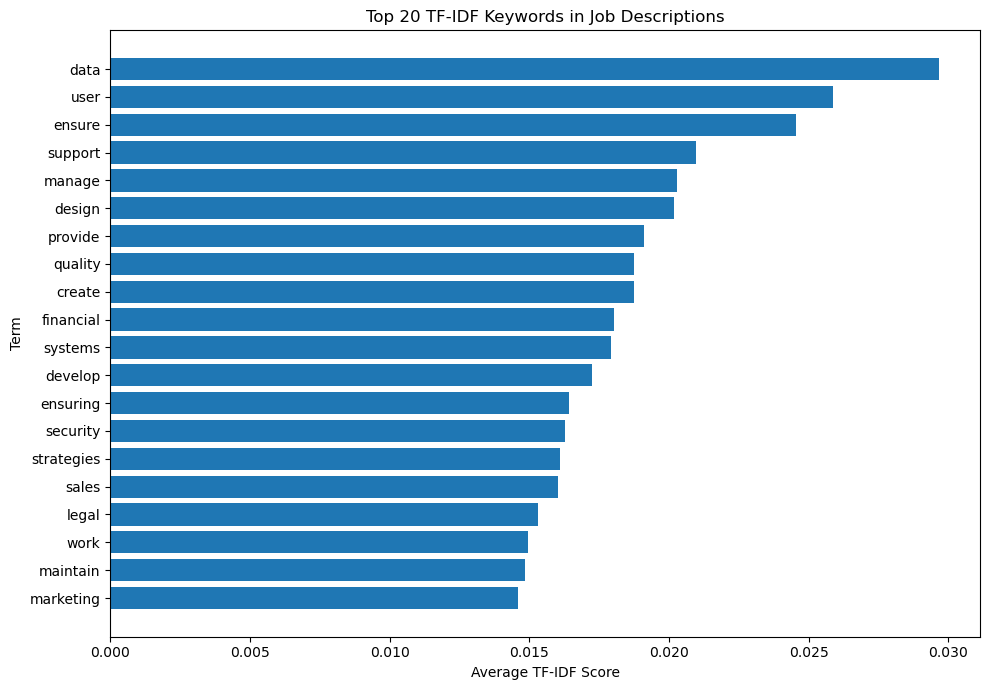

In [92]:
#Create a graph
import matplotlib.pyplot as plt

top_20_tfidf = tfidf_keywords.head(20).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_tfidf["term"],
    top_20_tfidf["tfidf_score"]
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.title("Top 20 TF-IDF Keywords in Job Descriptions")

plt.tight_layout()
plt.show()

In [93]:
# TF-IDF keywords for each job

def get_top_tfidf_terms(row_index, top_n=10):

    row = X_tfidf[row_index]

    scores = row.toarray().flatten()

    top_indices = scores.argsort()[-top_n:][::-1]

    return [
        (terms[i], round(scores[i], 4))
        for i in top_indices
        if scores[i] > 0
    ]

In [94]:
test_df["tfidf_keywords"] = [
    get_top_tfidf_terms(i, 10)
    for i in range(len(test_df))
]

In [95]:
display(
    test_df[
        [
            "Job Title",
            "Job Description",
            "tfidf_keywords"
        ]
    ].head(20)
)

,Job Title,Job Description,tfidf_keywords
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[(social media, 0.3607), (media, 0.3496), (social, 0.3496), (awareness engagement, 0.1577), (followers, 0.1577), (followers analyze, 0.1577), (organizations social, 0.1577), (media presence, 0.1577), (media metrics, 0.1577), (content engage, 0.1577)]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","[(developers, 0.3667), (web, 0.3061), (user, 0.2536), (developers design, 0.2131), (interfaces websites, 0.2131), (frontend web, 0.2131), (collaborate designers, 0.2056), (frontend, 0.1917), (user interfaces, 0.1894), (appealing user, 0.1815)]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","[(quality, 0.5528), (quality control, 0.4062), (control, 0.34), (maintain product, 0.2148), (service quality, 0.2066), (service, 0.2066), (develop quality, 0.2066), (organization develop, 0.1917), (perform, 0.1728), (quality standards, 0.1661)]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","[(wireless, 0.8409), (network, 0.2724), (reliable, 0.1701), (implement maintain, 0.1674), (engineers design, 0.1586), (troubleshoot, 0.1549), (design implement, 0.1487), (engineers, 0.1204), (solutions, 0.1178), (optimize, 0.1153)]"
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.","[(events, 0.4862), (execution, 0.2826), (conferences, 0.2727), (ensure smooth, 0.2727), (budgeting, 0.2684), (coordinates, 0.2607), (meetings, 0.2541), (smooth, 0.2483), (logistics, 0.2247), (plan, 0.214)]"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","[(quality, 0.2574), (report issues, 0.1892), (standards identify, 0.1892), (issues work, 0.1892), (analyst tests, 0.1892), (tests software, 0.1892), (teams resolve, 0.1892), (defects report, 0.1892), (assurance analyst, 0.1892), (work development, 0.1834)]"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","[(teacher, 0.3639), (level, 0.3639), (specific, 0.3376), (learning, 0.3334), (positive, 0.3334), (environment, 0.3334), (students, 0.3071), (plans, 0.2864), (assess, 0.2739), (create, 0.1908)]"
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","[(user interface, 0.3223), (interface, 0.3223), (user, 0.2229), (interface designers, 0.1728), (layouts buttons, 0.1728), (visual interactive, 0.1728), (focus visual, 0.1728), (elements ensure, 0.1728), (buttons elements, 0.1728), (interactive aspects, 0.1728)]"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,"[(

In [96]:
#Compare TF-IDF with your extracted skills
display(
    test_df[
        [
            "Job Title",
            "extracted_skills",
            "tfidf_keywords"
        ]
    ].head(20)
)

,Job Title,extracted_skills,tfidf_keywords
0,Digital Marketing Specialist,"[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[(social media, 0.3607), (media, 0.3496), (social, 0.3496), (awareness engagement, 0.1577), (followers, 0.1577), (followers analyze, 0.1577), (organizations social, 0.1577), (media presence, 0.1577), (media metrics, 0.1577), (content engage, 0.1577)]"
1,Web Developer,"[Frontend Development, Backend Development, Web Development]","[(developers, 0.3667), (web, 0.3061), (user, 0.2536), (developers design, 0.2131), (interfaces websites, 0.2131), (frontend web, 0.2131), (collaborate designers, 0.2056), (frontend, 0.1917), (user interfaces, 0.1894), (appealing user, 0.1815)]"
2,Operations Manager,"[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[(quality, 0.5528), (quality control, 0.4062), (control, 0.34), (maintain product, 0.2148), (service quality, 0.2066), (service, 0.2066), (develop quality, 0.2066), (organization develop, 0.1917), (perform, 0.1728), (quality standards, 0.1661)]"
3,Network Engineer,[Wireless Networking],"[(wireless, 0.8409), (network, 0.2724), (reliable, 0.1701), (implement maintain, 0.1674), (engineers design, 0.1586), (troubleshoot, 0.1549), (design implement, 0.1487), (engineers, 0.1204), (solutions, 0.1178), (optimize, 0.1153)]"
4,Event Manager,"[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]","[(events, 0.4862), (execution, 0.2826), (conferences, 0.2727), (ensure smooth, 0.2727), (budgeting, 0.2684), (coordinates, 0.2607), (meetings, 0.2541), (smooth, 0.2483), (logistics, 0.2247), (plan, 0.214)]"
5,Software Tester,"[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[(quality, 0.2574), (report issues, 0.1892), (standards identify, 0.1892), (issues work, 0.1892), (analyst tests, 0.1892), (tests software, 0.1892), (teams resolve, 0.1892), (defects report, 0.1892), (assurance analyst, 0.1892), (work development, 0.1834)]"
6,Teacher,"[Teaching, Curriculum Development, Lesson Planning, Instruction]","[(teacher, 0.3639), (level, 0.3639), (specific, 0.3376), (learning, 0.3334), (positive, 0.3334), (environment, 0.3334), (students, 0.3071), (plans, 0.2864), (assess, 0.2739), (create, 0.1908)]"
7,UX/UI Designer,"[User Interface, UI Design, User Interaction]","[(user interface, 0.3223), (interface, 0.3223), (user, 0.2229), (interface designers, 0.1728), (layouts buttons, 0.1728), (visual interactive, 0.1728), (focus visual, 0.1728), (elements ensure, 0.1728), (buttons elements, 0.1728), (interactive aspects, 0.1728)]"
8,UX/UI Designer,"[Interaction Design, User Interaction, User Experience, User Behavior, System Responses]","[(user, 0.3751), (create meaningful, 0.1808), (considering user, 0.1808), (user behaviors, 0.1808), (responses, 0.1808), (behaviors responses, 0.1808), (meaningful, 0.1808), (meaningful engaging, 0.1808), (interaction, 0.1808), (interaction designers, 0.1808)]"
9,Wedding Planner,"[Budget Management, Vendor Selection]","[(wedding, 0.5489), (day, 0.2745), (coordinating, 0.2595), (ensuring seamless, 0.2554), (assists, 0.2481), (helping, 0.2449), (consultant, 0.2449), (vendor, 0.2449), (budget, 0.2449), (seamless, 0.2138)]"


In [97]:
#Make TF-IDF keywords easier to read
test_df["tfidf_terms"] = test_df["tfidf_keywords"].apply(
    lambda x: [term for term, score in x]
)

In [98]:
display(
    test_df[
        [
            "Job Title",
            "extracted_skills",
            "tfidf_terms"
        ]
    ].head(20)
)

,Job Title,extracted_skills,tfidf_terms
0,Digital Marketing Specialist,"[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[social media, media, social, awareness engagement, followers, followers analyze, organizations social, media presence, media metrics, content engage]"
1,Web Developer,"[Frontend Development, Backend Development, Web Development]","[developers, web, user, developers design, interfaces websites, frontend web, collaborate designers, frontend, user interfaces, appealing user]"
2,Operations Manager,"[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[quality, quality control, control, maintain product, service quality, service, develop quality, organization develop, perform, quality standards]"
3,Network Engineer,[Wireless Networking],"[wireless, network, reliable, implement maintain, engineers design, troubleshoot, design implement, engineers, solutions, optimize]"
4,Event Manager,"[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]","[events, execution, conferences, ensure smooth, budgeting, coordinates, meetings, smooth, logistics, plan]"
5,Software Tester,"[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[quality, report issues, standards identify, issues work, analyst tests, tests software, teams resolve, defects report, assurance analyst, work development]"
6,Teacher,"[Teaching, Curriculum Development, Lesson Planning, Instruction]","[teacher, level, specific, learning, positive, environment, students, plans, assess, create]"
7,UX/UI Designer,"[User Interface, UI Design, User Interaction]","[user interface, interface, user, interface designers, layouts buttons, visual interactive, focus visual, elements ensure, buttons elements, interactive aspects]"
8,UX/UI Designer,"[Interaction Design, User Interaction, User Experience, User Behavior, System Responses]","[user, create meaningful, considering user, user behaviors, responses, behaviors responses, meaningful, meaningful engaging, interaction, interaction designers]"
9,Wedding Planner,"[Budget Management, Vendor Selection]","[wedding, day, coordinating, ensuring seamless, assists, helping, consultant, vendor, budget, seamless]"


In [99]:
#Automatically check which TF-IDF terms are in your skill dictionary
known_skills = set(
    skill.lower()
    for skill in regex_patterns.keys()
)

print("Number of known skills:", len(known_skills))

Number of known skills: 202


In [100]:
tfidf_keywords["is_known_skill"] = (
    tfidf_keywords["term"]
    .str.lower()
    .isin(known_skills)
)

display(
    tfidf_keywords.head(30)
)

,term,tfidf_score,is_known_skill
0,data,0.029650,False
1,user,0.025879,False
2,ensure,0.024533,False
3,support,0.020973,False
4,manage,0.020271,False
5,design,0.020188,False
6,provide,0.019117,False
7,quality,0.018761,False
8,create,0.018750,False
9,financial,0.018024,False


In [101]:
#Find TF-IDF terms that match known skills
tfidf_skill_matches = tfidf_keywords[
    tfidf_keywords["is_known_skill"] == True
]

display(
    tfidf_skill_matches.head(30)
)

,term,tfidf_score,is_known_skill
15,sales,0.016027,True
43,compliance,0.010972,True
58,communication,0.010168,True
65,social media,0.009734,True
150,seo,0.006177,True
158,user experience,0.005960,True
177,user interface,0.005548,True
200,troubleshooting,0.005221,True
218,manufacturing,0.004959,True
236,quality standards,0.004643,True


In [102]:
#Calculate how many TF-IDF terms are known skills
total_tfidf_terms = len(tfidf_keywords)

matched_skills = tfidf_keywords[
    "is_known_skill"
].sum()

print("Total TF-IDF terms:", total_tfidf_terms)
print("Known skill terms:", matched_skills)

percentage = (
    matched_skills / total_tfidf_terms
) * 100

print(
    f"Percentage of TF-IDF terms matching known skills: {percentage:.2f}%"
)

Total TF-IDF terms: 1000
Known skill terms: 22
Percentage of TF-IDF terms matching known skills: 2.20%


In [103]:
final_tfidf_df = test_df[
    [
        "Job Title",
        "Job Description",
        "skills",
        "regex_skills",
        "phrase_skills",
        "extracted_skills",
        "tfidf_terms"
    ]
].copy()

In [104]:
display(final_tfidf_df.head(20))

,Job Title,Job Description,skills,regex_skills,phrase_skills,extracted_skills,tfidf_terms
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[Social Media, Social Media Analytics]","[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[social media, media, social, awareness engagement, followers, followers analyze, organizations social, media presence, media metrics, content engage]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","[Frontend Development, Backend Development, Web Development]","[Frontend Development, Web Development, Backend Development]","[Frontend Development, Backend Development, Web Development]","[developers, web, user, developers design, interfaces websites, frontend web, collaborate designers, frontend, user interfaces, appealing user]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Control, Quality Standards, Quality Control Processes, Inspection, Corrective Action]","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[quality, quality control, control, maintain product, service quality, service, develop quality, organization develop, perform, quality standards]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,[Wireless Networking],[Wireless Networking],[Wireless Networking],"[wireless, network, reliable, implement maintain, engineers design, troubleshoot, design implement, engineers, solutions, optimize]"
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations,"[Event Management, Conference Management, Event Logistics, Vendor Coordination]","[Conference Management, Event Management, Event Planning, Conference Logistics, Budget Management, Vendor Coordination]","[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]","[events, execution, conferences, ensure smooth, budgeting, coordinates, meetings, smooth, logistics, plan]"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and

# N-Gram Analysis

In [105]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [106]:
test_df["ngram_text"] = (
    test_df["Job Description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

In [107]:
display(
    test_df[
        ["Job Title", "Job Description", "ngram_text"]
    ].head(10)
)

,Job Title,Job Description,ngram_text
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","social media managers oversee an organizations social media presence. they create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement."
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","frontend web developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. they collaborate with designers and backend developers to create seamless web experiences for users."
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","quality control managers establish and enforce quality standards within an organization. they develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality."
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","wireless network engineers design, implement, and maintain wireless network solutions. they optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications."
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.","a conference manager coordinates and manages conferences, meetings, and events. they plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees."
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","a quality assurance analyst tests software and products to ensure they meet quality standards. they identify defects, report issues, and work with development teams to resolve problems."
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","a classroom teacher educates students in a specific subject or grade level. they create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment."
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","user interface designers focus on the visual and interactive aspects of digital interfaces. they design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface."
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,interaction designers specialize in designing user interactions within digital interfaces. they create meaningful and engaging user experiences by considering user behaviors and system responses.
9,Wedding Planner,"A Wedding 

# Generate Unigrams

In [108]:
unigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english",
    max_features=1000
)

X_unigram = unigram_vectorizer.fit_transform(
    test_df["ngram_text"]
)

unigram_terms = unigram_vectorizer.get_feature_names_out()

unigram_scores = np.asarray(
    X_unigram.mean(axis=0)
).flatten()

unigram_df = pd.DataFrame({
    "term": unigram_terms,
    "score": unigram_scores
}).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

In [109]:
display(unigram_df.head(20))

,term,score
0,data,0.034448
1,user,0.032906
2,ensure,0.027128
3,support,0.023379
4,manage,0.021880
5,quality,0.020908
6,provide,0.020214
7,design,0.020136
8,create,0.019818
9,systems,0.019468


# Generate Bigrams

In [110]:
bigram_vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=1000
)

X_bigram = bigram_vectorizer.fit_transform(
    test_df["ngram_text"]
)

bigram_terms = bigram_vectorizer.get_feature_names_out()

bigram_scores = np.asarray(
    X_bigram.mean(axis=0)
).flatten()

bigram_df = pd.DataFrame({
    "term": bigram_terms,
    "score": bigram_scores
}).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

In [111]:
display(bigram_df.head(20))

,term,score
0,social media,0.013160
1,decision making,0.010179
2,managers oversee,0.009771
3,supply chain,0.009348
4,visually appealing,0.009189
5,provide legal,0.008534
6,mergers acquisitions,0.008160
7,designers create,0.008136
8,provide insights,0.008071
9,ensure compliance,0.007936


# Generate Trigrams

In [112]:
trigram_vectorizer = TfidfVectorizer(
    ngram_range=(3, 3),
    stop_words="english",
    max_features=1000
)

X_trigram = trigram_vectorizer.fit_transform(
    test_df["ngram_text"]
)

trigram_terms = trigram_vectorizer.get_feature_names_out()

trigram_scores = np.asarray(
    X_trigram.mean(axis=0)
).flatten()

trigram_df = pd.DataFrame({
    "term": trigram_terms,
    "score": trigram_scores
}).sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

In [113]:
display(trigram_df.head(20))

,term,score
0,illnesses perform surgeries,0.008072
1,implement security measures,0.007425
2,speech language disorders,0.007000
3,strong client relationships,0.007000
4,design implement maintain,0.006743
5,drive revenue growth,0.006687
6,provide legal support,0.006000
7,designers specialize designing,0.005860
8,analyze financial data,0.005661
9,decision making organization,0.005587


# Generate all N-grams together

In [114]:
ngram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english",
    max_features=2000
)

X_ngram = ngram_vectorizer.fit_transform(
    test_df["ngram_text"]
)

ngram_terms = ngram_vectorizer.get_feature_names_out()

ngram_scores = np.asarray(
    X_ngram.mean(axis=0)
).flatten()

ngram_df = pd.DataFrame({
    "ngram": ngram_terms,
    "tfidf_score": ngram_scores
}).sort_values(
    "tfidf_score",
    ascending=False
).reset_index(drop=True)

In [115]:
display(ngram_df.head(20))

,ngram,tfidf_score
0,data,0.025550
1,user,0.021088
2,ensure,0.019991
3,support,0.017205
4,design,0.016846
5,manage,0.016637
6,quality,0.016373
7,financial,0.016316
8,provide,0.016114
9,create,0.015265


# discover multi-word skills.

In [116]:
multi_word_skills = ngram_df[
    ngram_df["ngram"].str.split().str.len() >= 2
].copy()

In [117]:
display(
    multi_word_skills.head(20)
)

,ngram,tfidf_score
69,social media,0.007978
118,visually appealing,0.006020
125,supply chain,0.005764
134,decision making,0.005615
165,provide insights,0.004902
176,managers oversee,0.004766
184,products services,0.004659
192,digital interfaces,0.004508
195,user experience,0.004473
201,strategies manage,0.004359


# Compare N-grams with your existing skills

In [118]:
known_skills = set()

for skill in regex_patterns.keys():
    known_skills.add(skill.lower())

for skill_list in test_df["extracted_skills"]:
    if isinstance(skill_list, list):
        for skill in skill_list:
            known_skills.add(str(skill).lower())

In [119]:
print("Total known skills:", len(known_skills))

Total known skills: 208


# Compare N-grams against known skills

In [120]:
multi_word_skills["is_known_skill"] = (
    multi_word_skills["ngram"]
    .str.lower()
    .isin(known_skills)
)

In [121]:
display(
    multi_word_skills.head(20)
)

,ngram,tfidf_score,is_known_skill
69,social media,0.007978,True
118,visually appealing,0.006020,False
125,supply chain,0.005764,False
134,decision making,0.005615,False
165,provide insights,0.004902,False
176,managers oversee,0.004766,False
184,products services,0.004659,False
192,digital interfaces,0.004508,False
195,user experience,0.004473,True
201,strategies manage,0.004359,False


In [122]:
final_ngram_df = ngram_df.copy()

final_ngram_df["word_count"] = (
    final_ngram_df["ngram"]
    .str.split()
    .str.len()
)
display(
    final_ngram_df.head(50)
)

,ngram,tfidf_score,word_count
0,data,0.025550,1
1,user,0.021088,1
2,ensure,0.019991,1
3,support,0.017205,1
4,design,0.016846,1
5,manage,0.016637,1
6,quality,0.016373,1
7,financial,0.016316,1
8,provide,0.016114,1
9,create,0.015265,1


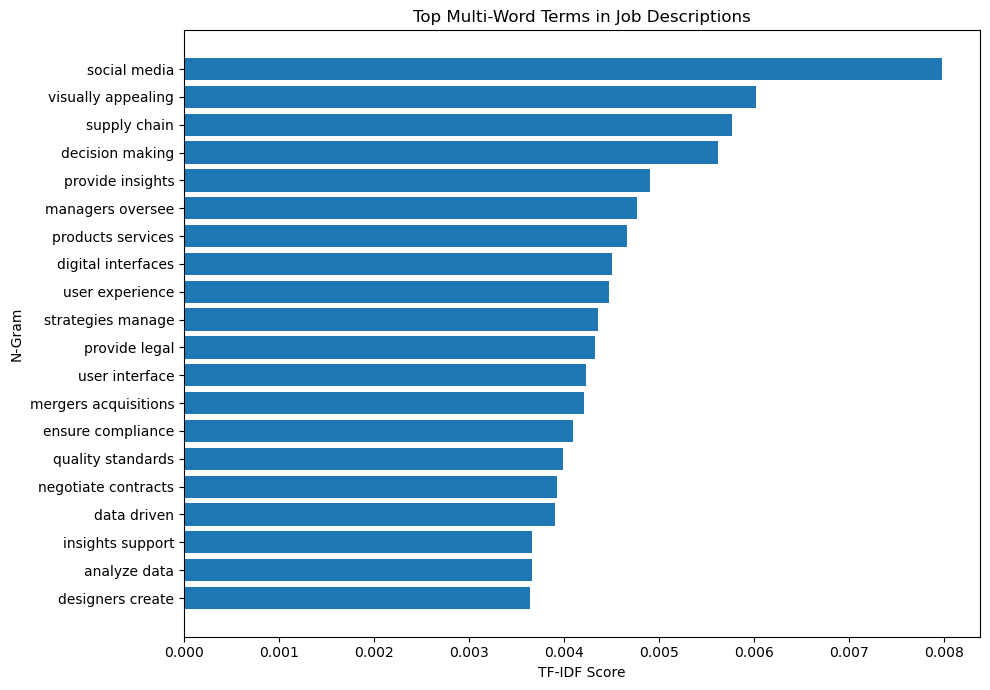

In [123]:
# top 20 multi-word phrases
import matplotlib.pyplot as plt

top_multi = multi_word_skills.head(20).sort_values(
    "tfidf_score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_multi["ngram"],
    top_multi["tfidf_score"]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("N-Gram")
plt.title("Top Multi-Word Terms in Job Descriptions")

plt.tight_layout()
plt.show()

# Word Embeddings & Semantic Similarity

In [124]:
!pip install sentence-transformers
!pip install --user sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


In [125]:
# Load the embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully


In [126]:
skill_dictionary = list(regex_patterns.keys())

print("Total skills:", len(skill_dictionary))

Total skills: 202


In [127]:
print(skill_dictionary[:20])

['Python', 'Java', 'JavaScript', 'C++', 'C#', 'HTML', 'CSS', 'React', 'Angular', 'Node.js', 'Frontend Development', 'Backend Development', 'Web Development', 'User Experience', 'User Interface', 'SQL', 'MySQL', 'PostgreSQL', 'MongoDB', 'Oracle']


In [128]:
skill_aliases = {
    "Machine Learning": "ML Machine Learning",
    "Deep Learning": "DL Deep Learning",
    "Natural Language Processing": "NLP Natural Language Processing",
    "Artificial Intelligence": "AI Artificial Intelligence",
    "Power BI": "Microsoft Power BI",
    "User Experience": "UX User Experience",
    "User Interface": "UI User Interface"
}

In [129]:
skill_embedding_text = []

for skill in skill_dictionary:

    if skill in skill_aliases:
        skill_embedding_text.append(
            skill_aliases[skill]
        )
    else:
        skill_embedding_text.append(skill)

In [130]:
# Generate skill embeddings
skill_embeddings = model.encode(
    skill_embedding_text,
    convert_to_numpy=True,
    show_progress_bar=False
)

print("Skill embedding shape:", skill_embeddings.shape)

Skill embedding shape: (202, 384)


In [131]:
show_progress_bar=True

In [132]:
show_progress_bar=False

In [133]:
#Generate Job Description embeddings
job_embeddings = model.encode(
    test_df["Job Description"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print(
    "Job description embedding shape:",
    job_embeddings.shape
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Job description embedding shape: (1000, 384)


In [134]:
#Calculate similarity
similarity_matrix = cosine_similarity(
    job_embeddings,
    skill_embeddings
)

print(
    "Similarity matrix shape:",
    similarity_matrix.shape
)

Similarity matrix shape: (1000, 202)


In [135]:
#Extract possible skills
SIMILARITY_THRESHOLD = 0.50

In [136]:
def semantic_skill_extractor(
    similarity_scores,
    skills,
    threshold=0.50
):

    matched_skills = []

    for i, score in enumerate(similarity_scores):

        if score >= threshold:

            matched_skills.append(
                (
                    skills[i],
                    round(float(score), 4)
                )
            )

    matched_skills.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return matched_skills

In [137]:
test_df["semantic_skills"] = [
    semantic_skill_extractor(
        similarity_matrix[i],
        skill_dictionary,
        SIMILARITY_THRESHOLD
    )
    for i in range(len(test_df))
]
display(
    test_df[
        [
            "Job Title",
            "semantic_skills"
        ]
    ].head(20)
)

,Job Title,semantic_skills
0,Digital Marketing Specialist,"[(Social Media Management, 0.7816)]"
1,Web Developer,"[(Frontend Development, 0.7237), (Backend Development, 0.666), (Web Development, 0.6003)]"
2,Operations Manager,"[(Quality Management Systems, 0.7435), (Quality Control Processes, 0.7408), (Quality Control, 0.7061), (Quality Assurance, 0.5843), (Quality Standards, 0.5607)]"
3,Network Engineer,"[(Wireless Networking, 0.5725), (Wireless Security, 0.5585), (Wireless Network Design, 0.5494)]"
4,Event Manager,"[(Conference Management, 0.7453), (Conference Logistics, 0.577), (Event Management, 0.5487)]"
5,Software Tester,"[(Quality Assurance, 0.6964), (Software Testing, 0.5004)]"
6,Teacher,"[(Classroom Management, 0.5853), (Teaching, 0.5734), (Lesson Planning, 0.563)]"
7,UX/UI Designer,"[(User Interface, 0.6639), (UI Design, 0.6187), (Visual Design, 0.5796), (UX Design, 0.5192), (Interaction Design, 0.5029)]"
8,UX/UI Designer,"[(Interaction Design, 0.6797), (Micro-interaction Design, 0.56), (User Interface, 0.5333), (User Experience, 0.5144), (UX Design, 0.5001)]"
9,Wedding Planner,[]


In [138]:
test_df["semantic_skill_names"] = (
    test_df["semantic_skills"]
    .apply(
        lambda x: [skill for skill, score in x]
    )
)
display(
    test_df[
        [
            "Job Title",
            "semantic_skill_names"
        ]
    ].head(20)
)

,Job Title,semantic_skill_names
0,Digital Marketing Specialist,[Social Media Management]
1,Web Developer,"[Frontend Development, Backend Development, Web Development]"
2,Operations Manager,"[Quality Management Systems, Quality Control Processes, Quality Control, Quality Assurance, Quality Standards]"
3,Network Engineer,"[Wireless Networking, Wireless Security, Wireless Network Design]"
4,Event Manager,"[Conference Management, Conference Logistics, Event Management]"
5,Software Tester,"[Quality Assurance, Software Testing]"
6,Teacher,"[Classroom Management, Teaching, Lesson Planning]"
7,UX/UI Designer,"[User Interface, UI Design, Visual Design, UX Design, Interaction Design]"
8,UX/UI Designer,"[Interaction Design, Micro-interaction Design, User Interface, User Experience, UX Design]"
9,Wedding Planner,[]


In [139]:
# Show similarity scores separately
display(
    test_df[
        [
            "Job Title",
            "semantic_skills"
        ]
    ].head(20)
)

,Job Title,semantic_skills
0,Digital Marketing Specialist,"[(Social Media Management, 0.7816)]"
1,Web Developer,"[(Frontend Development, 0.7237), (Backend Development, 0.666), (Web Development, 0.6003)]"
2,Operations Manager,"[(Quality Management Systems, 0.7435), (Quality Control Processes, 0.7408), (Quality Control, 0.7061), (Quality Assurance, 0.5843), (Quality Standards, 0.5607)]"
3,Network Engineer,"[(Wireless Networking, 0.5725), (Wireless Security, 0.5585), (Wireless Network Design, 0.5494)]"
4,Event Manager,"[(Conference Management, 0.7453), (Conference Logistics, 0.577), (Event Management, 0.5487)]"
5,Software Tester,"[(Quality Assurance, 0.6964), (Software Testing, 0.5004)]"
6,Teacher,"[(Classroom Management, 0.5853), (Teaching, 0.5734), (Lesson Planning, 0.563)]"
7,UX/UI Designer,"[(User Interface, 0.6639), (UI Design, 0.6187), (Visual Design, 0.5796), (UX Design, 0.5192), (Interaction Design, 0.5029)]"
8,UX/UI Designer,"[(Interaction Design, 0.6797), (Micro-interaction Design, 0.56), (User Interface, 0.5333), (User Experience, 0.5144), (UX Design, 0.5001)]"
9,Wedding Planner,[]


In [140]:
#Compare with your existing extraction
display(
    test_df[
        [
            "Job Title",
            "extracted_skills",
            "semantic_skill_names"
        ]
    ].head(20)
)

,Job Title,extracted_skills,semantic_skill_names
0,Digital Marketing Specialist,"[Social Media, Social Media Analytics, Content Creation, Community Engagement]",[Social Media Management]
1,Web Developer,"[Frontend Development, Backend Development, Web Development]","[Frontend Development, Backend Development, Web Development]"
2,Operations Manager,"[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Management Systems, Quality Control Processes, Quality Control, Quality Assurance, Quality Standards]"
3,Network Engineer,[Wireless Networking],"[Wireless Networking, Wireless Security, Wireless Network Design]"
4,Event Manager,"[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]","[Conference Management, Conference Logistics, Event Management]"
5,Software Tester,"[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[Quality Assurance, Software Testing]"
6,Teacher,"[Teaching, Curriculum Development, Lesson Planning, Instruction]","[Classroom Management, Teaching, Lesson Planning]"
7,UX/UI Designer,"[User Interface, UI Design, User Interaction]","[User Interface, UI Design, Visual Design, UX Design, Interaction Design]"
8,UX/UI Designer,"[Interaction Design, User Interaction, User Experience, User Behavior, System Responses]","[Interaction Design, Micro-interaction Design, User Interface, User Experience, UX Design]"
9,Wedding Planner,"[Budget Management, Vendor Selection]",[]


In [141]:
# Test the exact problem: ML vs Machine Learning
comparison_phrases = [
    "ML",
    "Machine Learning",
    "NLP",
    "Natural Language Processing",
    "AI",
    "Artificial Intelligence",
    "Power BI",
    "Microsoft Power BI"
]

comparison_embeddings = model.encode(
    comparison_phrases
)

comparison_matrix = cosine_similarity(
    comparison_embeddings
)
comparison_df = pd.DataFrame(
    comparison_matrix,
    index=comparison_phrases,
    columns=comparison_phrases
)

display(
    comparison_df.round(3)
)

,ML,Machine Learning,NLP,Natural Language Processing,AI,Artificial Intelligence,Power BI,Microsoft Power BI
ML,1.000,0.373,0.181,0.097,0.344,0.299,0.094,0.056
Machine Learning,0.373,1.000,0.416,0.482,0.546,0.703,0.198,0.184
NLP,0.181,0.416,1.000,0.602,0.402,0.413,0.123,0.015
Natural Language Processing,0.097,0.482,0.602,1.000,0.311,0.429,0.114,0.097
AI,0.344,0.546,0.402,0.311,1.000,0.791,0.204,0.104
Artificial Intelligence,0.299,0.703,0.413,0.429,0.791,1.000,0.169,0.101
Power BI,0.094,0.198,0.123,0.114,0.204,0.169,1.000,0.835
Microsoft Power BI,0.056,0.184,0.015,0.097,0.104,0.101,0.835,1.000


In [142]:
final_day11_df = test_df[
    [
        "Job Title",
        "Job Description",
        "skills",
        "regex_skills",
        "phrase_skills",
        "extracted_skills",
        "semantic_skill_names"
    ]
].copy()
display(
    final_day11_df.head(20)
)

,Job Title,Job Description,skills,regex_skills,phrase_skills,extracted_skills,semantic_skill_names
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[Social Media, Social Media Analytics]","[Social Media, Social Media Analytics, Content Creation, Community Engagement]",[Social Media Management]
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","[Frontend Development, Backend Development, Web Development]","[Frontend Development, Web Development, Backend Development]","[Frontend Development, Backend Development, Web Development]","[Frontend Development, Backend Development, Web Development]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Control, Quality Standards, Quality Control Processes, Inspection, Corrective Action]","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Management Systems, Quality Control Processes, Quality Control, Quality Assurance, Quality Standards]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,[Wireless Networking],[Wireless Networking],[Wireless Networking],"[Wireless Networking, Wireless Security, Wireless Network Design]"
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations,"[Event Management, Conference Management, Event Logistics, Vendor Coordination]","[Conference Management, Event Management, Event Planning, Conference Logistics, Budget Management, Vendor Coordination]","[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]","[Conference Management, Conference Logistics, Event Management]"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing","[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[Quality Assurance, Quality Standards]","[Quality A

In [143]:
final_day11_df.to_csv(
    "semantic_skill_extraction.csv",
    index=False
)

print(
    "Day 11 semantic skill extraction saved successfully."
)

Day 11 semantic skill extraction saved successfully.


In [144]:
jobs_with_semantic_skills = (
    test_df["semantic_skill_names"]
    .apply(len)
    .gt(0)
    .sum()
)

print(
    "Jobs with semantic skills:",
    jobs_with_semantic_skills
)

print(
    "Total jobs:",
    len(test_df)
)
percentage = (
    jobs_with_semantic_skills
    / len(test_df)
) * 100

print(
    f"Percentage of jobs with semantic skills: {percentage:.2f}%"
)

Jobs with semantic skills: 536
Total jobs: 1000
Percentage of jobs with semantic skills: 53.60%


In [145]:
def combine_skills(
    regex_skills,
    phrase_skills,
    semantic_skills
):

    combined = []

    for skills in [
        regex_skills,
        phrase_skills,
        semantic_skills
    ]:

        if isinstance(skills, list):

            for skill in skills:

                if isinstance(skill, tuple):
                    skill = skill[0]

                if skill not in combined:
                    combined.append(skill)

    return combined

test_df["final_extracted_skills"] = test_df.apply(
    lambda row: combine_skills(
        row["regex_skills"],
        row["phrase_skills"],
        row["semantic_skill_names"]
    ),
    axis=1
)
display(
    test_df[
        [
            "Job Title",
            "regex_skills",
            "phrase_skills",
            "semantic_skill_names",
            "final_extracted_skills"
        ]
    ].head(20)
)

,Job Title,regex_skills,phrase_skills,semantic_skill_names,final_extracted_skills
0,Digital Marketing Specialist,"[Social Media, Social Media Analytics, Content Creation, Community Engagement]","[Social Media, Social Media Analytics]",[Social Media Management],"[Social Media, Social Media Analytics, Content Creation, Community Engagement, Social Media Management]"
1,Web Developer,"[Frontend Development, Backend Development, Web Development]","[Frontend Development, Web Development, Backend Development]","[Frontend Development, Backend Development, Web Development]","[Frontend Development, Backend Development, Web Development]"
2,Operations Manager,"[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection]","[Quality Control, Quality Standards, Quality Control Processes, Inspection, Corrective Action]","[Quality Management Systems, Quality Control Processes, Quality Control, Quality Assurance, Quality Standards]","[Quality Control, Quality Standards, Quality Control Processes, Corrective Action, Inspection, Quality Management Systems, Quality Assurance]"
3,Network Engineer,[Wireless Networking],[Wireless Networking],"[Wireless Networking, Wireless Security, Wireless Network Design]","[Wireless Networking, Wireless Security, Wireless Network Design]"
4,Event Manager,"[Event Management, Conference Management, Event Logistics, Vendor Coordination]","[Conference Management, Event Management, Event Planning, Conference Logistics, Budget Management, Vendor Coordination]","[Conference Management, Conference Logistics, Event Management]","[Event Management, Conference Management, Event Logistics, Vendor Coordination, Event Planning, Conference Logistics, Budget Management]"
5,Software Tester,"[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]","[Quality Assurance, Quality Standards]","[Quality Assurance, Software Testing]","[Quality Assurance, Software Testing, Defect Identification, Bug Reporting, Quality Standards]"
6,Teacher,"[Teaching, Curriculum Development, Lesson Planning, Instruction]","[Teaching, Lesson Planning, Instruction]","[Classroom Management, Teaching, Lesson Planning]","[Teaching, Curriculum Development, Lesson Planning, Instruction, Classroom Management]"
7,UX/UI Designer,"[User Interface, UI Design]","[User Interface, User Interaction]","[User Interface, UI Design, Visual Design, UX Design, Interaction Design]","[User Interface, UI Design, User Interaction, Visual Design, UX Design, Interaction Design]"
8,UX/UI Designer,[Interaction Design],"[Interaction Design, User Interaction, User Experience, User Behavior, System Responses]","[Interaction Design, Micro-interaction Design, User Interface, User Experience, UX Design]","[Interaction Design, User Interaction, User Experience, User Behavior, System Responses, Micro-interaction Design, User Interface, UX Design]"
9,Wedding Planner,"[Budget Management, Vendor Selection]","[Vendor Selection, Budget Management]",[],"[Budget Management, Vendor Selection]"


# Named Entity Recognition

In [146]:
!pip install spacy
import spacy
print(spacy.__version__)
!python -m spacy download en_core_web_sm



     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.5 MB/s eta 0:00:09
     -- ------------------------------------- 0.8/12.8 MB 1.4 MB/s eta 0:00:09
     --- ------------------------------------ 1.0/12.8 MB 1.5 MB/s eta 0:00:08
     ---- ----------------------------------- 1.6/12.8 MB 1.5 MB/s eta 0:00:08
     ------ --------------------------------- 2.1/12.8 MB 1.7 MB/s eta 0:00:07
     -------- ------------------------------- 2.6/12.8 MB 1.9 MB/s eta 0:00:06
     ---------- ----------------------------- 3.4/12.8 MB 2.1 MB/s eta 0:00:05
     ------------ --------------------------- 3.9/12.8 MB 2.3 MB/s eta 0:00:04
     -------------- ------------------------- 4.7/12.8 MB 2.4 MB/s eta 0:00:04
     ----------------- ---------------------- 5.5/12.8 MB 2.5 MB/s eta 0:00:03
     -------------------- ------------------- 6.6/12.8 MB 2.8 MB/

In [147]:
lp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully")

spaCy model loaded successfully


In [148]:
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [149]:
import spacy

nlp = spacy.load("en_core_web_sm")

print(nlp.pipe_names)

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [150]:
def standard_ner(text):
    doc = nlp(text)

    return [
        (ent.text, ent.label_)
        for ent in doc.ents
    ]

test_df["standard_ner"] = (
    test_df["Job Description"]
    .fillna("")
    .apply(standard_ner)
)

display(
    test_df[
        ["Job Title", "standard_ner"]
    ].head(20)
)

,Job Title,standard_ner
0,Digital Marketing Specialist,"[(Social Media Managers, ORG)]"
1,Web Developer,[]
2,Operations Manager,"[(Quality Control Managers, ORG)]"
3,Network Engineer,"[(Wireless Network Engineers, ORG)]"
4,Event Manager,[]
5,Software Tester,"[(Quality Assurance, ORG)]"
6,Teacher,[]
7,UX/UI Designer,"[(Interface Designers, ORG)]"
8,UX/UI Designer,"[(Interaction Designers, ORG)]"
9,Wedding Planner,[]


In [151]:
custom_entities = {
    # Web Development
    "HTML": ["html", "html5"],
    "CSS": ["css", "css3"],
    "JavaScript": ["javascript", "java script"],
    "React": ["react", "react.js", "reactjs"],
    "Angular": ["angular", "angular.js", "angularjs"],
    "Frontend Development": [
        "frontend development",
        "front-end development",
        "frontend web developers",
        "front-end web developers"
    ],
    "Backend Development": [
        "backend development",
        "back-end development",
        "backend developers",
        "back-end developers"
    ],
    "Web Development": [
        "web development",
        "web developer",
        "web developers"
    ],
    "User Experience": [
        "user experience",
        "ux"
    ],
    "User Interface": [
        "user interface",
        "ui"
    ],

    # Marketing
    "Social Media": ["social media"],
    "Social Media Analytics": ["social media analytics"],
    "Content Creation": ["content creation"],
    "Community Engagement": ["community engagement"],
    "Email Marketing": ["email marketing"],
    "Email Deliverability": ["email deliverability"],
    "Content Marketing": ["content marketing"],
    "SEO": ["seo", "search engine optimization"],

    # Quality
    "Quality Control": ["quality control"],
    "Quality Standards": ["quality standards"],
    "Quality Control Processes": ["quality control processes"],
    "Corrective Action": ["corrective action", "corrective actions"],
    "Inspection": ["inspection", "inspections"],
    "Quality Assurance": ["quality assurance"],
    "Software Testing": ["software testing"],
    "Bug Tracking": ["bug tracking"],
    "Regression Testing": ["regression testing"],

    # Networking
    "Wireless Networking": ["wireless networking", "wireless network"],
    "Wireless Network Design": ["wireless network design"],
    "Wi-Fi": ["wi-fi", "wifi"],
    "Wireless Security": ["wireless security"],
    "Network Security": ["network security"],
    "Network Monitoring": ["network monitoring"],
    "Intrusion Detection": ["intrusion detection"],
    "Intrusion Prevention": ["intrusion prevention"],
    "Firewall Administration": ["firewall administration"],
    "Vulnerability Assessment": ["vulnerability assessment"],
    "Incident Response": ["incident response"],

    # Events
    "Event Planning": ["event planning"],
    "Event Management": ["event management"],
    "Conference Management": ["conference management"],
    "Conference Logistics": ["conference logistics"],
    "Budget Management": ["budget management"],
    "Vendor Coordination": ["vendor coordination"],
    "Vendor Selection": ["vendor selection"],
    "Marketing and Promotion": ["marketing and promotion"],

    # Education
    "Teaching": ["teaching"],
    "Teaching Pedagogy": ["teaching pedagogy"],
    "Classroom Management": ["classroom management"],
    "Curriculum Development": ["curriculum development"],
    "Lesson Planning": ["lesson plans", "lesson planning"],
    "Instruction": ["instruction"],
    "Student Assessment": ["student assessment"],
    "Differentiated Instruction": ["differentiated instruction"],

    # UX/UI
    "UI Design": ["ui design"],
    "UX Design": ["ux design"],
    "Interaction Design": ["interaction design"],
    "Wireframing": ["wireframing", "wireframes"],
    "Prototyping": ["prototyping", "prototypes"],
    "Visual Design": ["visual design"],
    "Graphic Design": ["graphic design"],
    "Typography": ["typography"],
    "Responsive Design": ["responsive design"],
    "User Behavior": ["user behavior"],
    "Psychology": ["psychology"],
    "Animation": ["animation"],
    "Micro-interaction Design": [
        "micro-interaction design",
        "micro interaction design"
    ],

    # Legal
    "Family Law": ["family law"],
    "Divorce": ["divorce"],
    "Divorce Proceedings": ["divorce proceedings"],
    "Child Custody": ["child custody"],
    "Mediation": ["mediation"],
    "Legal Counseling": ["legal counseling"],
    "Adoption": ["adoption"],
    "Domestic Disputes": ["domestic disputes"],

    # Mechanical
    "Mechanical Engineering": ["mechanical engineering"],
    "Mechanical Design": ["mechanical design"],
    "Mechanical Systems": ["mechanical systems"],
    "Manufacturing": ["manufacturing"],
    "CAD": ["cad", "computer aided design"],
    "AutoCAD": ["autocad", "auto cad"],
    "SolidWorks": ["solidworks", "solid works"],
    "Finite Element Analysis": ["finite element analysis"],
    "Product Development": ["product development"],

    # Business
    "Sales": ["sales"],
    "Relationship Management": ["relationship management"],
    "Account Management": ["account management"],
    "Negotiation": ["negotiation"],
    "Client Relations": ["client relations"],

    # Brand
    "Brand Identity": ["brand identity"],
    "Brand Management": ["brand management"],
    "Product Branding": ["product branding"],
    "Product Marketing": ["product marketing"],
    "Product Lifecycle Management": ["product lifecycle management"],
    "Product Launch Planning": ["product launch planning"],
    "Market Segmentation": ["market segmentation"],
    "Targeting": ["targeting"],

    # Social Work
    "School Social Work": ["school social work"],
    "Family Engagement": ["family engagement"],
    "Collaboration": ["collaboration"],
    "Advocacy": ["advocacy"],
    "Documentation": ["documentation"],
    "Crisis Management": ["crisis management"],
    "Cultural Competence": ["cultural competence"],

    # HR
    "Human Resources": ["human resources"],
    "Recruitment": ["recruitment", "recruiting"],
    "Employee Onboarding": ["employee onboarding", "onboarding"],
    "Employee Training": ["employee training"],
    "HRIS": ["hris", "hr information systems"],
    "Record Keeping": ["record keeping"],
    "Administrative Tasks": ["administrative tasks"],

    # Data / AI
    "Machine Learning": ["machine learning", "ml"],
    "Deep Learning": ["deep learning"],
    "Natural Language Processing": [
        "natural language processing",
        "nlp"
    ],
    
    "Data Science": ["data science"],
    "Data Analysis": ["data analysis", "data analytics"],
    "Power BI": ["power bi"],
    "SQL": ["sql"],
    "Python": ["python", "python3", "python 3"]
}

In [152]:
from spacy.matcher import PhraseMatcher

matcher = PhraseMatcher(
    nlp.vocab,
    attr="LOWER"
)

for label, phrases in custom_entities.items():

    patterns = [
        nlp.make_doc(phrase)
        for phrase in phrases
    ]

    matcher.add(label, patterns)

print("Custom matcher recreated successfully.")

Custom matcher recreated successfully.


In [153]:
def custom_ner(text):

    doc = nlp(text)

    matches = matcher(doc)

    entities = []
    seen = set()

    for match_id, start, end in matches:

        label = nlp.vocab.strings[match_id]
        entity_text = doc[start:end].text

        key = (
            entity_text.lower(),
            label
        )

        if key not in seen:

            entities.append(
                (entity_text, label)
            )

            seen.add(key)

    return entities

In [154]:
test_df["custom_ner"] = (
    test_df["Job Description"]
    .fillna("")
    .apply(custom_ner)
)

In [155]:
display(
    test_df[
        [
            "Job Title",
            "Job Description",
            "custom_ner"
        ]
    ].head(20)
)

,Job Title,Job Description,custom_ner
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[(Social Media, Social Media)]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","[(Frontend Web Developers, Frontend Development), (Web Developers, Web Development), (backend developers, Backend Development)]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","[(Quality Control, Quality Control), (quality standards, Quality Standards), (quality control processes, Quality Control Processes), (inspections, Inspection), (corrective actions, Corrective Action)]"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","[(Wireless Network, Wireless Networking)]"
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",[]
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","[(Quality Assurance, Quality Assurance), (quality standards, Quality Standards)]"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","[(lesson plans, Lesson Planning), (instruction, Instruction)]"
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","[(User Interface, User Interface)]"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,[]
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.","[(vendor selection, Vendor Selection), (budget management, Budget Management)]"


# Day13 Build a Machine Learning Skill Classifier

In [156]:
import pandas as pd

df = pd.read_csv("job_dataset_cleaned.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (1615940, 19)

Columns:
['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'Work Type', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company']


In [157]:
from IPython.display import display

display(
    df[
        [
            "Job Title",
            "Job Description",
            "skills"
        ]
    ].head(20)
)

,Job Title,Job Description,skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",Wedding planning Vendor coordination Event management


In [158]:
print(df["skills"].notna().sum())
print(df["skills"].head(20).tolist())

1615940
['Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising', 'HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)', 'Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge', 'Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues', 'Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations', 'Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing', 'Teaching pedagogy Classroom management Curriculum development Studen

In [159]:
skill_category = {

    # Programming / Web
    "Python": "PROGRAMMING",
    "Java": "PROGRAMMING",
    "JavaScript": "PROGRAMMING",
    "C++": "PROGRAMMING",
    "C#": "PROGRAMMING",
    "HTML": "WEB",
    "CSS": "WEB",
    "React": "WEB",
    "Angular": "WEB",
    "Node.js": "WEB",

    # Database
    "SQL": "DATABASE",
    "MySQL": "DATABASE",
    "PostgreSQL": "DATABASE",
    "MongoDB": "DATABASE",
    "Oracle": "DATABASE",

    # Data / BI
    "Power BI": "BI_TOOL",
    "Power Query": "BI_TOOL",
    "Tableau": "BI_TOOL",
    "Excel": "BI_TOOL",
    "DAX": "BI_TOOL",

    "Machine Learning": "AI_ML",
    "Deep Learning": "AI_ML",
    "Natural Language Processing": "NLP",
    "Data Science": "DATA",
    "Data Analysis": "DATA",
    "Data Visualization": "DATA",
    "Artificial Intelligence": "AI_ML",

    # Cloud
    "AWS": "CLOUD",
    "Azure": "CLOUD",
    "Google Cloud": "CLOUD",
    "Docker": "CLOUD",
    "Kubernetes": "CLOUD",

    # Testing
    "Software Testing": "TESTING",
    "Quality Assurance": "TESTING",
    "Manual Testing": "TESTING",
    "Automation Testing": "TESTING",
    "Regression Testing": "TESTING",
    "API Testing": "TESTING",
    "Performance Testing": "TESTING",
    "Load Testing": "TESTING",
    "Stress Testing": "TESTING",
    "Selenium": "TESTING",

    # Marketing
    "Digital Marketing": "MARKETING",
    "Social Media": "MARKETING",
    "Email Marketing": "MARKETING",
    "SEO": "MARKETING",
    "Content Marketing": "MARKETING",
    "Content Creation": "MARKETING",

    # UI / UX
    "UI Design": "UI_UX",
    "UX Design": "UI_UX",
    "Interaction Design": "UI_UX",
    "Wireframing": "UI_UX",
    "Prototyping": "UI_UX",
    "Figma": "UI_UX",
    "Graphic Design": "UI_UX",

    # Management
    "Project Management": "MANAGEMENT",
    "Operations Management": "MANAGEMENT",
    "Account Management": "MANAGEMENT",
    "Sales": "BUSINESS",
    "Negotiation": "BUSINESS",
    "Leadership": "MANAGEMENT",

    # Network / Security
    "Network Design": "NETWORK_SECURITY",
    "Network Architecture": "NETWORK_SECURITY",
    "Wireless Networking": "NETWORK_SECURITY",
    "Wi-Fi": "NETWORK_SECURITY",
    "Network Security": "NETWORK_SECURITY",
    "Firewall Administration": "NETWORK_SECURITY",
    "Vulnerability Assessment": "NETWORK_SECURITY",
    "Intrusion Detection": "NETWORK_SECURITY",
    "Ethical Hacking": "NETWORK_SECURITY",

    # HR
    "Recruitment": "HR",
    "Employee Onboarding": "HR",
    "HRIS": "HR",
    "Record Keeping": "HR",
    "Employee Training": "HR",
    "Human Resources": "HR",

    # Mechanical
    "Mechanical Engineering": "MECHANICAL",
    "Mechanical Design": "MECHANICAL",
    "CAD": "MECHANICAL",
    "AutoCAD": "MECHANICAL",
    "SolidWorks": "MECHANICAL",

    # Legal
    "Family Law": "LEGAL",
    "Divorce Proceedings": "LEGAL",
    "Child Custody": "LEGAL",
    "Mediation": "LEGAL",

    # Education
    "Teaching": "EDUCATION",
    "Teaching Pedagogy": "EDUCATION",
    "Classroom Management": "EDUCATION",
    "Curriculum Development": "EDUCATION",

    # Events
    "Event Planning": "EVENTS",
    "Event Management": "EVENTS",
    "Conference Logistics": "EVENTS",
    "Budget Management": "EVENTS",
    "Vendor Coordination": "EVENTS"
}

In [160]:
test_df.to_csv("job_skill_extracted.csv", index=False)

print("Saved successfully")

Saved successfully


In [161]:
df = pd.read_csv("job_skill_extracted.csv")

print(df.columns.tolist())

['Job Title', 'Job Description', 'skills', 'regex_skills', 'phrase_skills', 'extracted_skills', 'tfidf_text', 'tfidf_keywords', 'tfidf_terms', 'ngram_text', 'semantic_skills', 'semantic_skill_names', 'final_extracted_skills', 'standard_ner', 'custom_ner']


In [162]:
from IPython.display import display

display(
    df[
        [
            "Job Title",
            "Job Description",
            "extracted_skills"
        ]
    ].head(10)
)

,Job Title,Job Description,extracted_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","['Social Media', 'Social Media Analytics', 'Content Creation', 'Community Engagement']"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","['Frontend Development', 'Backend Development', 'Web Development']"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","['Quality Control', 'Quality Standards', 'Quality Control Processes', 'Corrective Action', 'Inspection']"
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",['Wireless Networking']
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.","['Event Management', 'Conference Management', 'Event Logistics', 'Vendor Coordination', 'Event Planning', 'Conference Logistics', 'Budget Management']"
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","['Quality Assurance', 'Software Testing', 'Defect Identification', 'Bug Reporting', 'Quality Standards']"
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.","['Teaching', 'Curriculum Development', 'Lesson Planning', 'Instruction']"
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","['User Interface', 'UI Design', 'User Interaction']"
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,"['Interaction Design', 'User Interaction', 'User Experience', 'User Behavior', 'System Responses']"
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.","['Budget Management', 'Vendor Selection']"


In [163]:
import pandas as pd
import numpy as np

df = pd.read_csv("job_dataset_cleaned.csv")

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (1615940, 19)
['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'Work Type', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company']


In [164]:
print(df["Job Description"].head(5))

0                                       Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.
1        Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.
2                 Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.
3                                       Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.
4    A Conference Manager coordinate

In [165]:
print("Missing Job Descriptions:",
      df["Job Description"].isna().sum())

Missing Job Descriptions: 0


In [166]:
skill_category_map = {

    # Programming / Development
    "python": "PROGRAMMING",
    "java": "PROGRAMMING",
    "javascript": "PROGRAMMING",
    "c++": "PROGRAMMING",
    "c#": "PROGRAMMING",
    "html": "WEB_DEVELOPMENT",
    "css": "WEB_DEVELOPMENT",
    "frontend": "WEB_DEVELOPMENT",
    "backend": "WEB_DEVELOPMENT",
    "web development": "WEB_DEVELOPMENT",
    "user interface": "UI_UX",

    # Database
    "sql": "DATABASE",
    "mysql": "DATABASE",
    "oracle": "DATABASE",
    "mongodb": "DATABASE",
    "database": "DATABASE",

    # Data / BI
    "power bi": "BI_TOOL",
    "tableau": "BI_TOOL",
    "data analysis": "DATA_ANALYTICS",
    "data analytics": "DATA_ANALYTICS",
    "data visualization": "DATA_ANALYTICS",
    "data analysis": "DATA_ANALYTICS",

    # Cloud
    "aws": "CLOUD",
    "azure": "CLOUD",
    "google cloud": "CLOUD",
    "cloud computing": "CLOUD",

    # Machine Learning / AI
    "machine learning": "ML",
    "deep learning": "ML",
    "artificial intelligence": "AI",
    "nlp": "NLP",
    "natural language processing": "NLP",
    "tensorflow": "ML",
    "pytorch": "ML",

    # Testing / QA
    "software testing": "TESTING",
    "quality assurance": "TESTING",
    "quality control": "QUALITY_CONTROL",
    "performance testing": "TESTING",
    "load testing": "TESTING",
    "stress testing": "TESTING",
    "scalability testing": "TESTING",
    "defect": "TESTING",
    "debugging": "TESTING",

    # Networking / Security
    "network": "NETWORKING",
    "networking": "NETWORKING",
    "wireless network": "NETWORKING",
    "wireless networking": "NETWORKING",
    "network security": "CYBER_SECURITY",
    "computer networks": "NETWORKING",
    "network traffic": "NETWORKING",
    "security threats": "CYBER_SECURITY",

    # Digital Marketing
    "social media": "DIGITAL_MARKETING",
    "social media marketing": "DIGITAL_MARKETING",
    "content creation": "DIGITAL_MARKETING",
    "content marketing": "DIGITAL_MARKETING",
    "email marketing": "DIGITAL_MARKETING",
    "email deliverability": "DIGITAL_MARKETING",
    "brand awareness": "DIGITAL_MARKETING",
    "brand management": "DIGITAL_MARKETING",
    "digital marketing": "DIGITAL_MARKETING",

    # UI / UX
    "ui design": "UI_UX",
    "ux design": "UI_UX",
    "user experience": "UI_UX",
    "user interface": "UI_UX",
    "interaction design": "UI_UX",
    "visual design": "UI_UX",
    "user behavior": "UI_UX",

    # Management
    "project management": "MANAGEMENT",
    "operations management": "MANAGEMENT",
    "budget management": "MANAGEMENT",
    "team management": "MANAGEMENT",
    "client management": "MANAGEMENT",
    "account management": "MANAGEMENT",

    # Events
    "event management": "EVENT_MANAGEMENT",
    "conference management": "EVENT_MANAGEMENT",
    "event planning": "EVENT_MANAGEMENT",
    "logistics": "EVENT_MANAGEMENT",
    "vendor management": "EVENT_MANAGEMENT",

    # HR
    "recruitment": "HR",
    "onboarding": "HR",
    "employee records": "HR",
    "human resources": "HR",
    "training": "HR",

    # Education
    "lesson planning": "EDUCATION",
    "teaching": "EDUCATION",
    "instruction": "EDUCATION",
    "student assessment": "EDUCATION",
    "classroom management": "EDUCATION",

    # Legal
    "family law": "LEGAL",
    "litigation": "LEGAL",
    "legal guidance": "LEGAL",
    "legal matters": "LEGAL",

    # Mechanical
    "mechanical design": "MECHANICAL",
    "mechanical engineering": "MECHANICAL",
    "mechanical systems": "MECHANICAL",
    "manufacturing": "MECHANICAL",
    "product design": "MECHANICAL",

    # Sales
    "sales": "SALES",
    "sales targets": "SALES",
    "client relationships": "SALES",
    "customer relationships": "SALES",

    # Social Work
    "social work": "SOCIAL_WORK",
    "social and emotional well-being": "SOCIAL_WORK",
    "family resources": "SOCIAL_WORK"
}

In [167]:
import re
import pandas as pd

def extract_skills(text):

    if pd.isna(text):
        return []

    text = str(text).lower()

    found_skills = []

    # Sort by length so multi-word skills are checked first
    sorted_skills = sorted(
        skill_category_map.keys(),
        key=len,
        reverse=True
    )

    for skill in sorted_skills:

        pattern = r'(?<!\w)' + re.escape(skill.lower()) + r'(?!\w)'

        if re.search(pattern, text):
            found_skills.append(skill)

    return found_skills

In [168]:
test_df = df.head(1000).copy()

test_df["extracted_skills"] = test_df["Job Description"].apply(
    extract_skills
)

In [169]:
display(
    test_df[
        ["Job Title", "Job Description", "extracted_skills"]
    ].head(20)
)

,Job Title,Job Description,extracted_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[brand awareness, social media]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","[frontend, backend]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.",[quality control]
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","[wireless network, network]"
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",[logistics]
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.",[quality assurance]
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",[instruction]
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.",[user interface]
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,[]
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",[budget management]


In [170]:
total_skills = test_df["extracted_skills"].apply(len).sum()

print("Total skills extracted:", total_skills)

Total skills extracted: 542


In [171]:
rows_with_skills = (
    test_df["extracted_skills"].apply(len) > 0
).sum()

print("Rows with at least one skill:", rows_with_skills)
print("Total rows:", len(test_df))

Rows with at least one skill: 374
Total rows: 1000


In [172]:
from collections import Counter

skill_counter = Counter()

for skills in test_df["extracted_skills"]:
    skill_counter.update(skills)

skill_frequency = pd.DataFrame(
    skill_counter.most_common(),
    columns=["Skill", "Frequency"]
)

display(skill_frequency.head(30))

,Skill,Frequency
0,sales,54
1,database,37
2,social media,34
3,network,32
4,logistics,28
5,user experience,26
6,backend,24
7,user interface,19
8,quality assurance,18
9,computer networks,18


In [173]:
training_rows = []

for skills in test_df["extracted_skills"]:

    for skill in skills:

        training_rows.append({
            "Text": skill,
            "Entity": skill,
            "Label": skill_category_map[skill]
        })

training_df = pd.DataFrame(training_rows)

print("Training dataset shape:", training_df.shape)

display(training_df.head(30))

Training dataset shape: (542, 3)


,Text,Entity,Label
0,brand awareness,brand awareness,DIGITAL_MARKETING
1,social media,social media,DIGITAL_MARKETING
2,frontend,frontend,WEB_DEVELOPMENT
3,backend,backend,WEB_DEVELOPMENT
4,quality control,quality control,QUALITY_CONTROL
5,wireless network,wireless network,NETWORKING
6,network,network,NETWORKING
7,logistics,logistics,EVENT_MANAGEMENT
8,quality assurance,quality assurance,TESTING
9,instruction,instruction,EDUCATION


In [174]:
print(training_df["Label"].value_counts())

Label
DIGITAL_MARKETING    81
SALES                69
NETWORKING           60
WEB_DEVELOPMENT      45
UI_UX                45
LEGAL                41
DATABASE             38
EVENT_MANAGEMENT     28
HR                   25
TESTING              24
MECHANICAL           22
CYBER_SECURITY       12
QUALITY_CONTROL      10
DATA_ANALYTICS       10
PROGRAMMING          10
EDUCATION             7
CLOUD                 6
ML                    5
MANAGEMENT            3
SOCIAL_WORK           1
Name: count, dtype: int64


In [175]:
training_df = training_df.drop_duplicates(
    subset=["Text", "Label"]
).reset_index(drop=True)

print("Training dataset after removing duplicates:")
print(training_df.shape)

display(training_df.head(20))

Training dataset after removing duplicates:
(51, 3)


,Text,Entity,Label
0,brand awareness,brand awareness,DIGITAL_MARKETING
1,social media,social media,DIGITAL_MARKETING
2,frontend,frontend,WEB_DEVELOPMENT
3,backend,backend,WEB_DEVELOPMENT
4,quality control,quality control,QUALITY_CONTROL
5,wireless network,wireless network,NETWORKING
6,network,network,NETWORKING
7,logistics,logistics,EVENT_MANAGEMENT
8,quality assurance,quality assurance,TESTING
9,instruction,instruction,EDUCATION


In [176]:
X = training_df["Text"].astype(str)
y = training_df["Label"].astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (51,)
y shape: (51,)


In [177]:
print("Number of categories:", y.nunique())
print("Categories:")
print(y.unique())

Number of categories: 20
Categories:
<ArrowStringArray>
['DIGITAL_MARKETING',   'WEB_DEVELOPMENT',   'QUALITY_CONTROL',
        'NETWORKING',  'EVENT_MANAGEMENT',           'TESTING',
         'EDUCATION',             'UI_UX',        'MANAGEMENT',
             'LEGAL',        'MECHANICAL',    'CYBER_SECURITY',
             'SALES',       'SOCIAL_WORK',                'HR',
          'DATABASE',    'DATA_ANALYTICS',       'PROGRAMMING',
                'ML',             'CLOUD']
Length: 20, dtype: str


In [178]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
df = pd.read_csv("job_dataset_cleaned.csv")

print("Dataset Shape:", df.shape)

display(df.head())
print(df.columns.tolist())
df["Job Description"] = df["Job Description"].fillna("").astype(str)

print(df["Job Description"].head())

Dataset Shape: (1615940, 19)


,Job Id,Experience,Qualifications,Salary Range,location,Country,Work Type,Job Posting Date,Preference,Contact Person,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,Intern,2022-04-24,Female,Brandon Cunningham,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","{'Flexible Spending Accounts (FSAs), Relocation Assistance, Legal Assistance, Employee Recognition Programs, Financial Counseling'}","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","Manage and grow social media accounts, create engaging content, and interact with the online community. Develop social media content calendars and strategies. Monitor social media trends and engagement metrics.",Icahn Enterprises
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,Intern,2022-12-19,Female,Francisco Larsen,461-509-4216,Web Developer,Frontend Web Developer,Idealist,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","{'Health Insurance, Retirement Plans, Paid Time Off (PTO), Flexible Work Arrangements, Employee Assistance Programs (EAP)'}","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","Design and code user interfaces for websites, ensuring a seamless and visually appealing user experience. Collaborate with UX designers to optimize user journeys. Ensure cross-browser compatibility and responsive design.",PNC Financial Services Group
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",Temporary,2022-09-14,Male,Gary Gibson,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","{'Legal Assistance, Bonuses and Incentive Programs, Wellness Programs, Employee Discounts, Retirement Plans'}","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge",Establish and enforce quality control standards and procedures. Conduct quality audits and inspections. Collaborate with production teams to address quality issues and implement improvements.,United Services Automobile Assn.
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,Full-Time,2023-02-25,Female,Joy Lucero,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","{'Transportation Benefits, Professional Development, Bonuses and Incentive Programs, Profit-Sharing, Employee Discounts'}",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,"Design, configure, and optimize wireless networks, ensuring reliable and secure wireless connectivity. Troubleshoot wireless network issues. Plan and implement wireless network upgrades.",Hess
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,Intern,2022-10-11,Female,Julie Johnson,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Caree

['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'Work Type', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company']
0                                       Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.
1        Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.
2                 Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.
3           

In [179]:
skill_category_map = {

    # Programming
    "python": "PROGRAMMING",
    "java": "PROGRAMMING",
    "javascript": "PROGRAMMING",
    "c++": "PROGRAMMING",
    "c#": "PROGRAMMING",
    "r programming": "PROGRAMMING",

    # Web Development
    "frontend": "WEB_DEVELOPMENT",
    "frontend development": "WEB_DEVELOPMENT",
    "backend": "WEB_DEVELOPMENT",
    "backend development": "WEB_DEVELOPMENT",
    "web development": "WEB_DEVELOPMENT",
    "html": "WEB_DEVELOPMENT",
    "css": "WEB_DEVELOPMENT",

    # Database
    "sql": "DATABASE",
    "mysql": "DATABASE",
    "oracle": "DATABASE",
    "mongodb": "DATABASE",
    "postgresql": "DATABASE",
    "database": "DATABASE",

    # Data / BI
    "data analysis": "DATA_ANALYTICS",
    "data analytics": "DATA_ANALYTICS",
    "data visualization": "DATA_ANALYTICS",
    "power bi": "BI_TOOL",
    "tableau": "BI_TOOL",

    # Cloud
    "aws": "CLOUD",
    "azure": "CLOUD",
    "google cloud": "CLOUD",
    "cloud computing": "CLOUD",

    # AI / ML
    "machine learning": "MACHINE_LEARNING",
    "deep learning": "MACHINE_LEARNING",
    "artificial intelligence": "AI",
    "nlp": "NLP",
    "natural language processing": "NLP",
    "tensorflow": "MACHINE_LEARNING",
    "pytorch": "MACHINE_LEARNING",

    # Testing
    "software testing": "TESTING",
    "quality assurance": "TESTING",
    "quality control": "QUALITY_CONTROL",
    "performance testing": "TESTING",
    "load testing": "TESTING",
    "stress testing": "TESTING",
    "scalability testing": "TESTING",
    "defect": "TESTING",
    "debugging": "TESTING",

    # Networking
    "network": "NETWORKING",
    "networking": "NETWORKING",
    "wireless network": "NETWORKING",
    "wireless networking": "NETWORKING",
    "network traffic": "NETWORKING",
    "computer networks": "NETWORKING",

    # Cyber Security
    "network security": "CYBER_SECURITY",
    "security threats": "CYBER_SECURITY",
    "security": "CYBER_SECURITY",

    # Digital Marketing
    "social media": "DIGITAL_MARKETING",
    "social media marketing": "DIGITAL_MARKETING",
    "content creation": "DIGITAL_MARKETING",
    "content marketing": "DIGITAL_MARKETING",
    "email marketing": "DIGITAL_MARKETING",
    "email deliverability": "DIGITAL_MARKETING",
    "brand awareness": "DIGITAL_MARKETING",
    "digital marketing": "DIGITAL_MARKETING",

    # UI / UX
    "ui design": "UI_UX",
    "ux design": "UI_UX",
    "user interface": "UI_UX",
    "user experience": "UI_UX",
    "interaction design": "UI_UX",
    "visual design": "UI_UX",
    "user behavior": "UI_UX",

    # Management
    "project management": "MANAGEMENT",
    "operations management": "MANAGEMENT",
    "budget management": "MANAGEMENT",
    "team management": "MANAGEMENT",
    "client management": "MANAGEMENT",
    "account management": "MANAGEMENT",

    # Events
    "event management": "EVENT_MANAGEMENT",
    "event planning": "EVENT_MANAGEMENT",
    "conference management": "EVENT_MANAGEMENT",
    "logistics": "EVENT_MANAGEMENT",
    "vendor management": "EVENT_MANAGEMENT",

    # HR
    "recruitment": "HR",
    "onboarding": "HR",
    "employee records": "HR",
    "human resources": "HR",
    "training": "HR",

    # Education
    "lesson planning": "EDUCATION",
    "teaching": "EDUCATION",
    "instruction": "EDUCATION",
    "student assessment": "EDUCATION",
    "classroom management": "EDUCATION",

    # Legal
    "family law": "LEGAL",
    "litigation": "LEGAL",
    "legal guidance": "LEGAL",
    "legal matters": "LEGAL",

    # Mechanical
    "mechanical design": "MECHANICAL",
    "mechanical engineering": "MECHANICAL",
    "mechanical systems": "MECHANICAL",
    "manufacturing": "MECHANICAL",
    "product design": "MECHANICAL",

    # Sales
    "sales": "SALES",
    "sales targets": "SALES",
    "client relationships": "SALES",
    "customer relationships": "SALES",

    # Social Work
    "social work": "SOCIAL_WORK",
    "social and emotional well-being": "SOCIAL_WORK"
}

In [180]:
def extract_skills(text):

    text = str(text).lower()

    found_skills = []

    # Check longer phrases first
    sorted_skills = sorted(
        skill_category_map.keys(),
        key=len,
        reverse=True
    )

    for skill in sorted_skills:

        pattern = r'(?<!\w)' + re.escape(skill.lower()) + r'(?!\w)'

        if re.search(pattern, text):
            found_skills.append(skill)

    return found_skills

In [181]:
model_df = df.head(10000).copy()

model_df["extracted_skills"] = model_df["Job Description"].apply(
    extract_skills
)

print("Total records:", len(model_df))

print(
    "Records with extracted skills:",
    (model_df["extracted_skills"].apply(len) > 0).sum()
)

Total records: 10000
Records with extracted skills: 3576


In [182]:
display(
    model_df[
        ["Job Title", "Job Description", "extracted_skills"]
    ].head(20)
)

,Job Title,Job Description,extracted_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[brand awareness, social media]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","[frontend, backend]"
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.",[quality control]
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.","[wireless network, network]"
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",[logistics]
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.",[quality assurance]
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",[instruction]
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.",[user interface]
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,[]
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",[budget management]


In [183]:
training_rows = []

for _, row in model_df.iterrows():

    description = row["Job Description"]

    for skill in row["extracted_skills"]:

        training_rows.append({
            "Text": skill,
            "Entity": skill,
            "Label": skill_category_map[skill]
        })

training_df = pd.DataFrame(training_rows)

print("Training dataset shape:", training_df.shape)

display(training_df.head(30))

Training dataset shape: (5485, 3)


,Text,Entity,Label
0,brand awareness,brand awareness,DIGITAL_MARKETING
1,social media,social media,DIGITAL_MARKETING
2,frontend,frontend,WEB_DEVELOPMENT
3,backend,backend,WEB_DEVELOPMENT
4,quality control,quality control,QUALITY_CONTROL
5,wireless network,wireless network,NETWORKING
6,network,network,NETWORKING
7,logistics,logistics,EVENT_MANAGEMENT
8,quality assurance,quality assurance,TESTING
9,instruction,instruction,EDUCATION


In [184]:
print(
    training_df["Label"].value_counts()
)

Label
DIGITAL_MARKETING    797
SALES                668
CYBER_SECURITY       641
NETWORKING           577
UI_UX                499
WEB_DEVELOPMENT      356
LEGAL                320
DATABASE             298
HR                   284
EVENT_MANAGEMENT     265
TESTING              172
MECHANICAL           148
PROGRAMMING           95
QUALITY_CONTROL       78
DATA_ANALYTICS        77
MACHINE_LEARNING      65
EDUCATION             59
CLOUD                 38
SOCIAL_WORK           27
MANAGEMENT            21
Name: count, dtype: int64


In [185]:
training_df = training_df.drop_duplicates(
    subset=["Text", "Label"]
).reset_index(drop=True)

print("Training data after duplicates:", training_df.shape)

display(training_df.head(30))

Training data after duplicates: (52, 3)


,Text,Entity,Label
0,brand awareness,brand awareness,DIGITAL_MARKETING
1,social media,social media,DIGITAL_MARKETING
2,frontend,frontend,WEB_DEVELOPMENT
3,backend,backend,WEB_DEVELOPMENT
4,quality control,quality control,QUALITY_CONTROL
5,wireless network,wireless network,NETWORKING
6,network,network,NETWORKING
7,logistics,logistics,EVENT_MANAGEMENT
8,quality assurance,quality assurance,TESTING
9,instruction,instruction,EDUCATION


In [186]:
description_training_rows = []

for _, row in model_df.iterrows():

    description = row["Job Description"]
    extracted = row["extracted_skills"]

    categories = set()

    for skill in extracted:

        category = skill_category_map.get(skill)

        if category:
            categories.add(category)

    for category in categories:

        description_training_rows.append({
            "Text": description,
            "Label": category
        })

description_training_df = pd.DataFrame(
    description_training_rows
)

print(
    "Description training dataset:",
    description_training_df.shape
)

display(description_training_df.head(20))

Description training dataset: (4373, 2)


,Text,Label
0,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.",DIGITAL_MARKETING
1,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.",WEB_DEVELOPMENT
2,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.",QUALITY_CONTROL
3,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",NETWORKING
4,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",EVENT_MANAGEMENT
5,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.",TESTING
6,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",EDUCATION
7,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.",UI_UX
8,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",MANAGEMENT
9,"Performance Testing Specialists assess the performance of software applications by conducting load, stress, and scalability tests. They identify bottlenecks, optimize performance, and ensure software can handle user demands effectively.",TESTING


In [187]:
print(
    description_training_df["Label"].value_counts()
)

Label
CYBER_SECURITY       564
SALES                554
DIGITAL_MARKETING    548
UI_UX                451
NETWORKING           309
DATABASE             283
EVENT_MANAGEMENT     265
WEB_DEVELOPMENT      259
LEGAL                219
HR                   214
TESTING              172
PROGRAMMING           95
MECHANICAL            94
QUALITY_CONTROL       78
DATA_ANALYTICS        77
MACHINE_LEARNING      65
EDUCATION             59
SOCIAL_WORK           27
MANAGEMENT            21
CLOUD                 19
Name: count, dtype: int64


In [188]:
label_counts = description_training_df["Label"].value_counts()

valid_labels = label_counts[
    label_counts >= 2
].index

description_training_df = description_training_df[
    description_training_df["Label"].isin(valid_labels)
].copy()

print(
    description_training_df["Label"].value_counts()
)

Label
CYBER_SECURITY       564
SALES                554
DIGITAL_MARKETING    548
UI_UX                451
NETWORKING           309
DATABASE             283
EVENT_MANAGEMENT     265
WEB_DEVELOPMENT      259
LEGAL                219
HR                   214
TESTING              172
PROGRAMMING           95
MECHANICAL            94
QUALITY_CONTROL       78
DATA_ANALYTICS        77
MACHINE_LEARNING      65
EDUCATION             59
SOCIAL_WORK           27
MANAGEMENT            21
CLOUD                 19
Name: count, dtype: int64


In [189]:
X = description_training_df["Text"].astype(str)

y = description_training_df["Label"].astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4373,)
y shape: (4373,)


In [190]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3498
Testing samples: 875


In [191]:
skill_classifier = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [192]:
skill_classifier.fit(
    X_train,
    y_train
)

print("Model training completed successfully!")

Model training completed successfully!


In [193]:
y_pred = skill_classifier.predict(X_test)

print(y_pred[:20])

['WEB_DEVELOPMENT' 'DIGITAL_MARKETING' 'HR' 'TESTING' 'UI_UX'
 'EVENT_MANAGEMENT' 'DATABASE' 'PROGRAMMING' 'CYBER_SECURITY' 'UI_UX'
 'CYBER_SECURITY' 'MECHANICAL' 'SALES' 'DIGITAL_MARKETING'
 'MACHINE_LEARNING' 'TESTING' 'CYBER_SECURITY' 'CYBER_SECURITY'
 'NETWORKING' 'SALES']


In [194]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(
    "Accuracy (%):",
    round(accuracy * 100, 2)
)

Accuracy: 0.8091428571428572
Accuracy (%): 80.91


In [195]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

            CLOUD       0.00      0.00      0.00         4
   CYBER_SECURITY       0.61      0.76      0.68       113
         DATABASE       0.49      0.68      0.57        57
   DATA_ANALYTICS       1.00      0.27      0.42        15
DIGITAL_MARKETING       0.99      1.00      1.00       110
        EDUCATION       1.00      1.00      1.00        12
 EVENT_MANAGEMENT       0.88      1.00      0.94        53
               HR       0.87      0.91      0.89        43
            LEGAL       1.00      1.00      1.00        44
 MACHINE_LEARNING       0.39      0.54      0.45        13
       MANAGEMENT       1.00      1.00      1.00         4
       MECHANICAL       1.00      1.00      1.00        19
       NETWORKING       0.90      0.29      0.44        62
      PROGRAMMING       1.00      0.42      0.59        19
  QUALITY_CONTROL       1.00      1.00      1.00        15
            SALES       0.95      0.99      0.97       

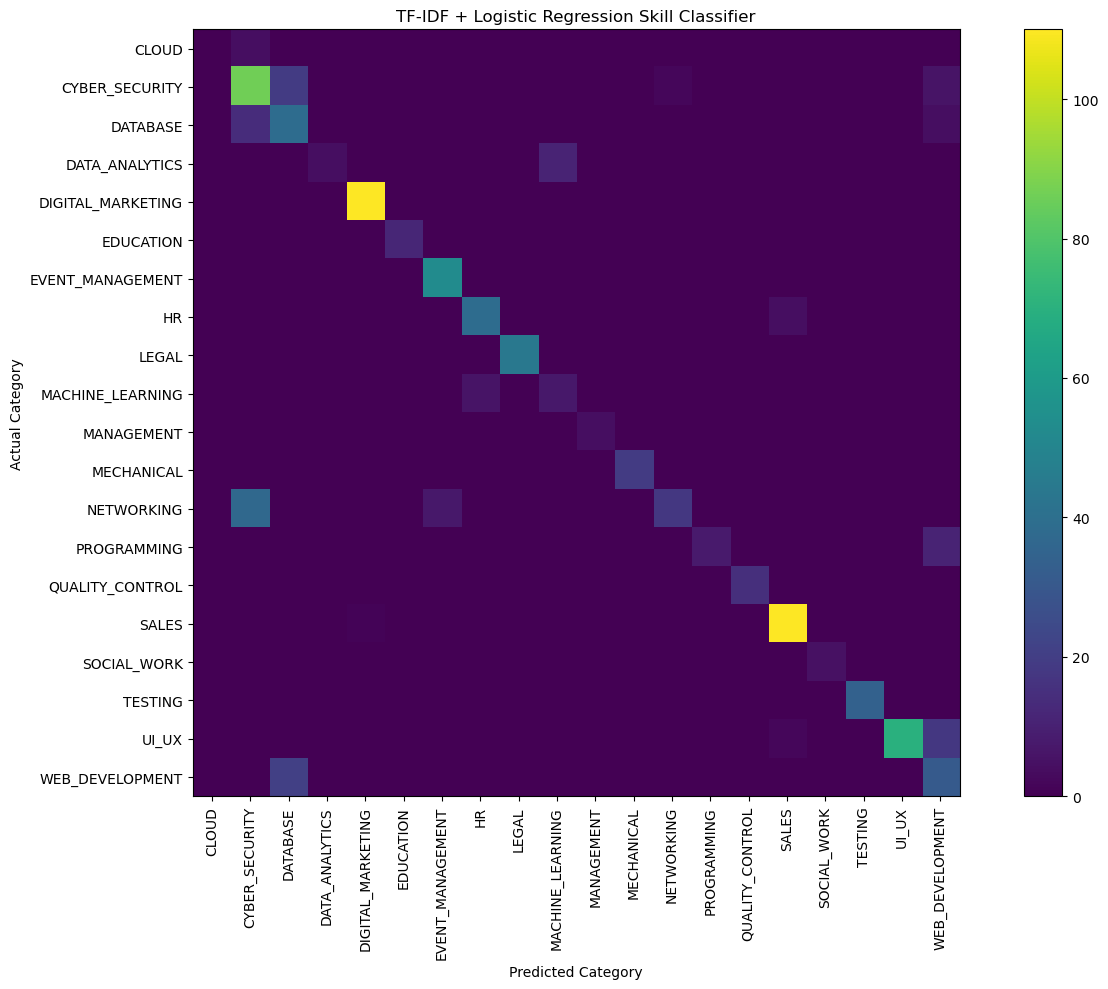

In [196]:
labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(14, 10))

plt.imshow(cm)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.title(
    "TF-IDF + Logistic Regression Skill Classifier"
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [197]:
sample_text = df["Job Description"].iloc[0]

print(sample_text)

Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.


In [198]:
prediction = skill_classifier.predict(
    [sample_text]
)

print("Predicted Category:", prediction[0])

Predicted Category: DIGITAL_MARKETING


In [199]:
sample_jobs = df[
    ["Job Title", "Job Description"]
].head(10).copy()

sample_jobs["Predicted_Category"] = skill_classifier.predict(
    sample_jobs["Job Description"]
)

display(sample_jobs)

,Job Title,Job Description,Predicted_Category
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.",DIGITAL_MARKETING
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.",WEB_DEVELOPMENT
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.",QUALITY_CONTROL
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",NETWORKING
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",EVENT_MANAGEMENT
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.",TESTING
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",EDUCATION
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.",UI_UX
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,UI_UX
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",MANAGEMENT


# DAY 14 — Advanced Transformer-Based Skill Extraction

In [200]:
!pip install transformers torch datasets seqeval accelerate

  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [57 lines of output]
  C:\Users\91838\anaconda3\Lib\site-packages\setuptools\__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
  !!
  
          ********************************************************************************
          Requirements should be satisfied by a PEP 517 installer.
          If you are using pip, you can try `pip install --use-pep517`.
  
          This deprecation is overdue, please update your project and remove deprecated
          calls to avoid build errors in the future.
          ********************************************************************************
  
  !!
    dist.fetch_build_eggs(dist.setup_requires)
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\91838\AppData\Local\Temp\pip-in


  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


In [201]:
import pandas as pd
import numpy as np
import re
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.13.0+cpu
CUDA available: False


In [202]:
df["Job Description"] = (
    df["Job Description"]
    .fillna("")
    .astype(str)
)

display(
    df[["Job Title", "Job Description"]].head(10)
)

,Job Title,Job Description
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement."
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users."
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality."
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications."
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees."
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems."
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment."
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface."
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience."


In [203]:
transformer_df = df.sample(
    n=5000,
    random_state=42
).copy()

print("Transformer dataset shape:", transformer_df.shape)

Transformer dataset shape: (5000, 19)


In [204]:
#Load a pretrained BERT-NER model

model_name = "dslim/bert-base-NER"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForTokenClassification.from_pretrained(
    model_name
)

print("BERT-NER model loaded successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT-NER model loaded successfully!


In [205]:
ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

print("NER pipeline created successfully!")

NER pipeline created successfully!


In [206]:
text = "Experience with Python, SQL and AWS."

entities = ner_pipeline(text)

display(pd.DataFrame(entities))

,entity_group,score,word,start,end
0,MISC,0.993960,Python,16,22
1,MISC,0.984175,SQL,24,27
2,MISC,0.976253,AWS,32,35


In [207]:
import pandas as pd
import numpy as np
import re
import os

In [208]:
print("Number of skills:", len(skill_category_map))

Number of skills: 104


In [209]:
skill_taxonomy = pd.read_csv("skill_taxonomy.csv")

print(skill_taxonomy.columns.tolist())

display(skill_taxonomy.head(20))

['skill', 'category', 'aliases']


,skill,category,aliases
0,Python,Programming,"python, python3"
1,Java,Programming,java
2,C++,Programming,"c++, cpp"
3,JavaScript,Programming,"javascript, js"
4,HTML,Web Development,"html, html5"
5,CSS,Web Development,"css, css3"
6,React,Web Development,"react, reactjs, react.js"
7,Angular,Web Development,"angular, angularjs"
8,SQL,Database,sql
9,MySQL,Database,mysql


In [210]:
# Remove accidental spaces from column names
skill_taxonomy.columns = (
    skill_taxonomy.columns
    .str.strip()
)

print("Columns:", skill_taxonomy.columns.tolist())

Columns: ['skill', 'category', 'aliases']


In [211]:
for col in skill_taxonomy.columns:
    print(f"{col} -> {skill_taxonomy[col].dropna().head(3).tolist()}")

skill -> ['Python', 'Java', 'C++']
category -> ['Programming', 'Programming', 'Programming']
aliases -> ['python, python3', 'java', 'c++, cpp']


In [212]:
skills_list = sorted(
    skill_category_map.keys(),
    key=len,
    reverse=True
)

print("Total skills:", len(skills_list))
print(skills_list[:30])

Total skills: 104
['social and emotional well-being', 'natural language processing', 'artificial intelligence', 'social media marketing', 'mechanical engineering', 'customer relationships', 'operations management', 'conference management', 'frontend development', 'email deliverability', 'classroom management', 'client relationships', 'backend development', 'performance testing', 'scalability testing', 'wireless networking', 'data visualization', 'interaction design', 'project management', 'account management', 'student assessment', 'mechanical systems', 'quality assurance', 'computer networks', 'content marketing', 'digital marketing', 'budget management', 'client management', 'vendor management', 'mechanical design']


In [213]:
import re

def find_skills(text):
    
    text = str(text)
    found = []
    
    for skill in skills_list:
        
        pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
        
        for match in re.finditer(
            pattern,
            text,
            flags=re.IGNORECASE
        ):
            
            found.append({
                "skill": match.group(),
                "start": match.start(),
                "end": match.end(),
                "category": skill_category_map[skill]
            })
    
    return found

In [214]:
test_text = "Experience with Python, SQL and AWS."

result = find_skills(test_text)

display(pd.DataFrame(result))

,skill,start,end,category
0,Python,16,22,PROGRAMMING
1,SQL,24,27,DATABASE
2,AWS,32,35,CLOUD


In [215]:
df["ner_text"] = (
    df["Job Description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df = df[df["ner_text"].str.len() > 0].copy()

print("Usable job descriptions:", len(df))

Usable job descriptions: 1615940


In [216]:
ner_df = df.sample(
    n=min(5000, len(df)),
    random_state=42
).copy()

print("Day 14 dataset:", ner_df.shape)

Day 14 dataset: (5000, 20)


In [217]:
ner_df["matched_skills"] = ner_df["ner_text"].apply(
    find_skills
)

In [218]:
display(
    ner_df[
        [
            "Job Title",
            "Job Description",
            "matched_skills"
        ]
    ].head(20)
)

,Job Title,Job Description,matched_skills
108318,Procurement Manager,"Promote diversity and inclusion in the supply chain, manage supplier diversity programs, and assess supplier performance.",[]
7787,Architectural Designer,Architectural Drafters assist architects and engineers in creating detailed technical drawings and plans for buildings and structures. They use computer-aided design (CAD) software to produce accurate and precise architectural drawings.,[]
1237496,Art Teacher,"An Art Education Coordinator plans and manages art education programs, curriculum development, and educational outreach to promote art appreciation and learning within communities.",[]
55757,Environmental Consultant,"Environmental Impact Analysts assess the environmental consequences of projects or activities. They conduct studies, analyze data, and provide recommendations to minimize adverse environmental effects and promote sustainable practices.",[]
818970,Art Teacher,"An Art Education Coordinator plans and manages art education programs, curriculum development, and educational outreach to promote art appreciation and learning within communities.",[]
403614,Event Planner,"Wedding Planners specialize in organizing weddings, assisting couples with every aspect of wedding planning, from venue selection to catering and decor.",[]
1369376,Architect,"Architectural Designers create architectural plans and designs for buildings and structures, considering aesthetics, functionality, and safety standards.",[]
447926,Family Lawyer,Mediators facilitate negotiations and dispute resolution between parties in conflict. They remain neutral and help parties reach mutually acceptable agreements through effective communication and problem-solving techniques.,[]
272262,Account Manager,"Build and maintain strong client relationships, understand their needs, and ensure client satisfaction.","[{'skill': 'client relationships', 'start': 26, 'end': 46, 'category': 'SALES'}]"
1222281,Business Development Manager,"A Market Expansion Manager strategizes and executes plans to expand the companys presence in new markets, identifying growth opportunities and optimizing market penetration.",[]


In [219]:
ner_df["skill_count"] = ner_df["matched_skills"].apply(len)

print(
    "Descriptions with skills:",
    (ner_df["skill_count"] > 0).sum()
)

print(
    "Descriptions without skills:",
    (ner_df["skill_count"] == 0).sum()
)

Descriptions with skills: 1845
Descriptions without skills: 3155


In [220]:
def create_ner_entities(text):
    
    matches = find_skills(text)
    
    entities = []
    
    for item in matches:
        
        entities.append({
            "start": item["start"],
            "end": item["end"],
            "label": "SKILL",
            "text": item["skill"]
        })
    
    return entities

In [221]:
text = "Experience with Python, SQL and AWS."

print(create_ner_entities(text))

[{'start': 16, 'end': 22, 'label': 'SKILL', 'text': 'Python'}, {'start': 24, 'end': 27, 'label': 'SKILL', 'text': 'SQL'}, {'start': 32, 'end': 35, 'label': 'SKILL', 'text': 'AWS'}]


In [222]:
ner_training_rows = []

for _, row in ner_df.iterrows():
    
    text = row["ner_text"]
    
    entities = create_ner_entities(text)
    
    if entities:
        
        ner_training_rows.append({
            "text": text,
            "entities": entities
        })

print(
    "NER training records:",
    len(ner_training_rows)
)

NER training records: 1845


In [223]:
display(
    pd.DataFrame(ner_training_rows).head(10)
)

,text,entities
0,"Build and maintain strong client relationships, understand their needs, and ensure client satisfaction.","[{'start': 26, 'end': 46, 'label': 'SKILL', 'text': 'client relationships'}]"
1,"Network Administrators manage an organizations computer networks. They configure, monitor, and maintain network infrastructure, ensuring optimal performance and security.","[{'start': 47, 'end': 64, 'label': 'SKILL', 'text': 'computer networks'}, {'start': 161, 'end': 169, 'label': 'SKILL', 'text': 'security'}, {'start': 0, 'end': 7, 'label': 'SKILL', 'text': 'Network'}, {'start': 104, 'end': 111, 'label': 'SKILL', 'text': 'network'}]"
2,"Training Coordinators design and implement employee training programs. They assess training needs, develop training materials, and facilitate training sessions to enhance employees skills and knowledge.","[{'start': 0, 'end': 8, 'label': 'SKILL', 'text': 'Training'}, {'start': 52, 'end': 60, 'label': 'SKILL', 'text': 'training'}, {'start': 83, 'end': 91, 'label': 'SKILL', 'text': 'training'}, {'start': 107, 'end': 115, 'label': 'SKILL', 'text': 'training'}, {'start': 142, 'end': 150, 'label': 'SKILL', 'text': 'training'}]"
3,"Content Strategists develop and execute content strategies that align with business objectives. They plan content creation, distribution, and promotion to engage audiences and drive brand growth.","[{'start': 106, 'end': 122, 'label': 'SKILL', 'text': 'content creation'}]"
4,"Protect an organizations computer networks and systems from security threats, monitor network traffic, and respond to incidents.","[{'start': 25, 'end': 42, 'label': 'SKILL', 'text': 'computer networks'}, {'start': 60, 'end': 76, 'label': 'SKILL', 'text': 'security threats'}, {'start': 86, 'end': 101, 'label': 'SKILL', 'text': 'network traffic'}, {'start': 60, 'end': 68, 'label': 'SKILL', 'text': 'security'}, {'start': 86, 'end': 93, 'label': 'SKILL', 'text': 'network'}]"
5,"In the role of a Quality Control Analyst, you will be responsible for inspecting and testing products to ensure they meet quality standards and specifications. You will use quality control tools and processes to identify defects, document findings, and recommend improvements. Your role is essential in maintaining product quality and customer satisfaction.","[{'start': 17, 'end': 32, 'label': 'SKILL', 'text': 'Quality Control'}, {'start': 173, 'end': 188, 'label': 'SKILL', 'text': 'quality control'}]"
6,"A Backend Developer is tasked with building and maintaining the server-side logic and database infrastructure of web applications. They work on the core functionality, data storage, and server communication to ensure the application runs smoothly and efficiently.","[{'start': 86, 'end': 94, 'label': 'SKILL', 'text': 'database'}, {'start': 2, 'end': 9, 'label': 'SKILL', 'text': 'Backend'}]"
7,"Trial Attorneys represent clients in legal proceedings. They prepare cases, conduct trials, and provide legal counsel to clients involved in civil or criminal litigation.","[{'start': 159, 'end': 169, 'label': 'SKILL', 'text': 'litigation'}]"
8,"Assist in litigation cases, including document preparation, legal research, and trial support.","[{'start': 10, 'end': 20, 'label': 'SKILL', 'text': 'litigation'}]"
9,"Corporate Attorneys provide legal counsel and representation to organizations. They handle legal matters, contracts, mergers, acquisitions, and ensure compliance with laws and regulations relevant to the business.","[{'start': 91, 'end': 104, 'label': 'SKILL', 'text': 'legal matters'}]"


In [224]:
print("skill_category_map exists:", "skill_category_map" in globals())

if "skill_category_map" in globals():
    print("Number of skills:", len(skill_category_map))
    print("First 20 skills:")
    print(list(skill_category_map.items())[:20])

skill_category_map exists: True
Number of skills: 104
First 20 skills:
[('python', 'PROGRAMMING'), ('java', 'PROGRAMMING'), ('javascript', 'PROGRAMMING'), ('c++', 'PROGRAMMING'), ('c#', 'PROGRAMMING'), ('r programming', 'PROGRAMMING'), ('frontend', 'WEB_DEVELOPMENT'), ('frontend development', 'WEB_DEVELOPMENT'), ('backend', 'WEB_DEVELOPMENT'), ('backend development', 'WEB_DEVELOPMENT'), ('web development', 'WEB_DEVELOPMENT'), ('html', 'WEB_DEVELOPMENT'), ('css', 'WEB_DEVELOPMENT'), ('sql', 'DATABASE'), ('mysql', 'DATABASE'), ('oracle', 'DATABASE'), ('mongodb', 'DATABASE'), ('postgresql', 'DATABASE'), ('database', 'DATABASE'), ('data analysis', 'DATA_ANALYTICS')]


In [225]:
print(skill_taxonomy.columns.tolist())

['skill', 'category', 'aliases']


In [226]:
display(skill_taxonomy.head(10))

,skill,category,aliases
0,Python,Programming,"python, python3"
1,Java,Programming,java
2,C++,Programming,"c++, cpp"
3,JavaScript,Programming,"javascript, js"
4,HTML,Web Development,"html, html5"
5,CSS,Web Development,"css, css3"
6,React,Web Development,"react, reactjs, react.js"
7,Angular,Web Development,"angular, angularjs"
8,SQL,Database,sql
9,MySQL,Database,mysql


In [227]:
skill_list = [
    "Python",
    "Java",
    "JavaScript",
    "TypeScript",
    "C++",
    "C#",
    "HTML",
    "CSS",
    "React",
    "Angular",
    "Node.js",
    "SQL",
    "MySQL",
    "PostgreSQL",
    "MongoDB",
    "Power BI",
    "Tableau",
    "Excel",
    "Power Query",
    "DAX",
    "Machine Learning",
    "Deep Learning",
    "Natural Language Processing",
    "NLP",
    "TensorFlow",
    "PyTorch",
    "Pandas",
    "NumPy",
    "AWS",
    "Azure",
    "Google Cloud",
    "Docker",
    "Kubernetes",
    "Git",
    "Selenium",
    "Jenkins",
    "Spark",
    "Hadoop",
    "Data Analysis",
    "Data Analytics",
    "Data Visualization",
    "Statistics",
    "ETL",
    "API",
    "REST API",
    "Cybersecurity",
    "Social Media",
    "Digital Marketing",
    "SEO",
    "Recruitment",
    "Project Management"
]

print("Number of skills:", len(skill_list))

Number of skills: 51


In [228]:
def find_skills(text):
    
    text = str(text)
    
    found = []
    
    # Long skills first
    sorted_skills = sorted(
        skill_list,
        key=len,
        reverse=True
    )
    
    for skill in sorted_skills:
        
        pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
        
        for match in re.finditer(
            pattern,
            text,
            flags=re.IGNORECASE
        ):
            
            found.append({
                "skill": match.group(),
                "start": match.start(),
                "end": match.end()
            })
    
    return found

In [229]:
test_text = "Experience with Python, SQL and AWS."

result = find_skills(test_text)

print(result)

[{'skill': 'Python', 'start': 16, 'end': 22}, {'skill': 'SQL', 'start': 24, 'end': 27}, {'skill': 'AWS', 'start': 32, 'end': 35}]


In [230]:
sample_text = df["Job Description"].iloc[0]

print("JOB DESCRIPTION:")
print(sample_text)

print("\nSKILLS FOUND:")
print(find_skills(sample_text))

JOB DESCRIPTION:
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

SKILLS FOUND:
[{'skill': 'Social Media', 'start': 0, 'end': 12}, {'skill': 'social media', 'start': 47, 'end': 59}, {'skill': 'social media', 'start': 139, 'end': 151}]


In [231]:
test_df = df[
    ["Job Title", "Job Description"]
].head(20).copy()

test_df["matched_skills"] = (
    test_df["Job Description"]
    .apply(find_skills)
)

display(test_df)

,Job Title,Job Description,matched_skills
0,Digital Marketing Specialist,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[{'skill': 'Social Media', 'start': 0, 'end': 12}, {'skill': 'social media', 'start': 47, 'end': 59}, {'skill': 'social media', 'start': 139, 'end': 151}]"
1,Web Developer,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.",[]
2,Operations Manager,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.",[]
3,Network Engineer,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",[]
4,Event Manager,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",[]
5,Software Tester,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.",[]
6,Teacher,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",[]
7,UX/UI Designer,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.",[]
8,UX/UI Designer,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,[]
9,Wedding Planner,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",[]


In [232]:
test_df["skill_count"] = (
    test_df["matched_skills"]
    .apply(len)
)

print(
    "Jobs with skills:",
    (test_df["skill_count"] > 0).sum()
)

print(
    "Jobs without skills:",
    (test_df["skill_count"] == 0).sum()
)

Jobs with skills: 3
Jobs without skills: 17


In [233]:
def create_entities(text):
    
    matches = find_skills(text)
    
    entities = []
    
    for item in matches:
        
        entities.append({
            "start": item["start"],
            "end": item["end"],
            "label": "SKILL"
        })
    
    return entities

In [234]:
text = "Experience with Python, SQL and AWS."

entities = create_entities(text)

print(text)
print(entities)

Experience with Python, SQL and AWS.
[{'start': 16, 'end': 22, 'label': 'SKILL'}, {'start': 24, 'end': 27, 'label': 'SKILL'}, {'start': 32, 'end': 35, 'label': 'SKILL'}]


In [235]:
ner_df = df.sample(
    n=min(5000, len(df)),
    random_state=42
).copy()

print("NER dataset size:", ner_df.shape)

NER dataset size: (5000, 20)


In [236]:
ner_training_data = []

for _, row in ner_df.iterrows():
    
    text = row["Job Description"]
    
    entities = create_entities(text)
    
    if len(entities) > 0:
        
        ner_training_data.append({
            "text": text,
            "entities": entities
        })

print(
    "Training examples:",
    len(ner_training_data)
)

Training examples: 499


In [237]:
display(
    pd.DataFrame(
        ner_training_data
    ).head(10)
)

,text,entities
0,"Create engaging and relevant content, such as articles, videos, or social media posts, to promote brands or products.","[{'start': 67, 'end': 79, 'label': 'SKILL'}]"
1,"Analyze digital marketing campaigns, track performance metrics, and optimize online marketing strategies.","[{'start': 8, 'end': 25, 'label': 'SKILL'}]"
2,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[{'start': 0, 'end': 12, 'label': 'SKILL'}, {'start': 47, 'end': 59, 'label': 'SKILL'}, {'start': 139, 'end': 151, 'label': 'SKILL'}]"
3,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","[{'start': 0, 'end': 12, 'label': 'SKILL'}, {'start': 47, 'end': 59, 'label': 'SKILL'}, {'start': 139, 'end': 151, 'label': 'SKILL'}]"
4,"As a Cloud Systems Engineer, you will be responsible for designing, implementing, and managing cloud infrastructure solutions. You will work with cloud platforms like AWS, Azure, or GCP to build scalable and reliable systems. Your role involves optimizing cloud resources, ensuring security, and troubleshooting issues to maintain high system availability and performance.","[{'start': 172, 'end': 177, 'label': 'SKILL'}, {'start': 167, 'end': 170, 'label': 'SKILL'}]"
5,A Risk Analyst assesses and manages financial risks within an organization. They use data analysis and modeling to evaluate potential risks and recommend mitigation strategies.,"[{'start': 85, 'end': 98, 'label': 'SKILL'}]"
6,"Digital Marketing Managers lead digital marketing efforts, including SEO, SEM, social media, email marketing, and content strategy. They develop and execute digital marketing campaigns to increase brand awareness, drive traffic, and generate leads or sales.","[{'start': 0, 'end': 17, 'label': 'SKILL'}, {'start': 32, 'end': 49, 'label': 'SKILL'}, {'start': 157, 'end': 174, 'label': 'SKILL'}, {'start': 79, 'end': 91, 'label': 'SKILL'}, {'start': 69, 'end': 72, 'label': 'SKILL'}]"
7,"Java Software Engineers develop and maintain software applications using the Java programming language. They write code, debug applications, and collaborate with cross-functional teams to deliver high-quality software solutions.","[{'start': 0, 'end': 4, 'label': 'SKILL'}, {'start': 77, 'end': 81, 'label': 'SKILL'}]"
8,"Analyze digital marketing campaigns, track performance metrics, and optimize online marketing strategies.","[{'start': 8, 'end': 25, 'label': 'SKILL'}]"
9,"Cybersecurity Analysts protect computer systems and networks from cyber threats. They monitor security systems, investigate breaches, and implement security measures to safeguard data.","[{'start': 0, 'end': 13, 'label': 'SKILL'}]"


In [238]:
# ============================================================
# DAY 14 - TRANSFORMER BASED SKILL EXTRACTION
# ============================================================

import os
import re
import ast
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification
)

from torch.utils.data import Dataset, DataLoader

from IPython.display import display


# ============================================================
# SETTINGS
# ============================================================

DATASET_FILE = "job_dataset_cleaned.csv"

MODEL_NAME = "distilbert-base-uncased"

MODEL_FOLDER = "day14_skill_model"

MAX_ROWS = 3000

MAX_TEXT_LENGTH = 800

MAX_TOKEN_LENGTH = 128

EPOCHS = 2

BATCH_SIZE = 8

LEARNING_RATE = 5e-5

SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# DEVICE
# ============================================================

if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    DEVICE = torch.device("cpu")

    print("Data")


# ============================================================
# LOAD ONLY REQUIRED COLUMNS
# ============================================================

print("=" * 70)
print("DAY 14 - TRANSFORMER SKILL EXTRACTION")
print("=" * 70)

print("\nLoading dataset...")


# IMPORTANT:
# Only read Job Description and skills.
# Do NOT load all 19 columns.

df = pd.read_csv(

    DATASET_FILE,

    usecols=[
        "Job Description",
        "skills"
    ],

    nrows=MAX_ROWS,

    low_memory=True

)


print(
    "\nDataset loaded successfully."
)

print(
    "Rows:",
    len(df)
)

print(
    "Columns:",
    df.columns.tolist()
)


# ============================================================
# CLEAN DATA
# ============================================================

df["Job Description"] = (

    df["Job Description"]

    .fillna("")

    .astype(str)

)


df["skills"] = (

    df["skills"]

    .fillna("")

    .astype(str)

)


# Remove empty descriptions

df = df[
    df["Job Description"].str.strip() != ""
].copy()


# ============================================================
# SKILL PARSER
# ============================================================

def parse_skills(value):

    if pd.isna(value):

        return []


    text = str(value).strip()


    if text == "":

        return []


    # Try Python list

    if (
        text.startswith("[")
        and
        text.endswith("]")
    ):

        try:

            result = ast.literal_eval(text)

            if isinstance(result, list):

                return [

                    str(x)
                    .strip()
                    .lower()

                    for x in result

                    if str(x).strip()

                ]

        except:

            pass


    # Split skills

    parts = re.split(

        r"[,;|\n]+",

        text

    )


    skills = []


    for skill in parts:

        skill = skill.strip().lower()


        if skill:

            skills.append(skill)


    return list(
        dict.fromkeys(skills)
    )


df["skill_list"] = (

    df["skills"]

    .apply(parse_skills)

)


# Remove records with no skills

df = df[
    df["skill_list"].apply(len) > 0
].copy()


df.reset_index(
    drop=True,
    inplace=True
)


print(
    "\nValid records:",
    len(df)
)


# ============================================================
# LIMIT DESCRIPTION LENGTH
# ============================================================

df["Job Description"] = (

    df["Job Description"]

    .str.slice(
        0,
        MAX_TEXT_LENGTH
    )

)


# ============================================================
# DISPLAY SAMPLE
# ============================================================

print("\nSample data:")

display(

    df[
        [
            "Job Description",
            "skills"
        ]
    ].head(5)

)


# ============================================================
# LABELS
# ============================================================

label2id = {

    "O": 0,

    "B-SKILL": 1,

    "I-SKILL": 2

}


id2label = {

    0: "O",

    1: "B-SKILL",

    2: "I-SKILL"

}


# ============================================================
# TOKENIZER
# ============================================================

print("\nLoading DistilBERT tokenizer...")


tokenizer = AutoTokenizer.from_pretrained(

    MODEL_NAME

)


print(
    "Tokenizer loaded."
)


# ============================================================
# NORMALIZE WORD
# ============================================================

def normalize_word(word):

    word = str(word).lower()


    word = re.sub(

        r"^[^\w+#.-]+",

        "",

        word

    )


    word = re.sub(

        r"[^\w+#.-]+$",

        "",

        word

    )


    return word


# ============================================================
# CREATE BIO LABELS
# ============================================================

def create_labels(

    text,
    skills

):

    words = text.split()

    labels = [

        0

        for _ in words

    ]


    normalized_words = [

        normalize_word(word)

        for word in words

    ]


    for skill in skills:

        skill_words = [

            normalize_word(x)

            for x in skill.split()

        ]


        skill_words = [

            x

            for x in skill_words

            if x != ""

        ]


        if not skill_words:

            continue


        for i in range(

            len(words)

        ):

            if (

                normalized_words[
                    i:
                    i + len(skill_words)
                ]

                ==

                skill_words

            ):

                labels[i] = 1


                for j in range(

                    1,
                    len(skill_words)

                ):

                    if (

                        i + j
                        <
                        len(labels)

                    ):

                        labels[
                            i + j
                        ] = 2


    return words, labels


# ============================================================
# TEST LABEL CREATION
# ============================================================

print("\nTesting skill labeling...")


test_text = (

    "Experience with Python SQL and AWS"

)


test_skills = [

    "python",

    "sql",

    "aws"

]


test_words, test_labels = create_labels(

    test_text,

    test_skills

)


for word, label in zip(

    test_words,

    test_labels

):

    print(

        word,

        "->",

        id2label[label]

    )


# ============================================================
# CREATE TRAINING DATA
# ============================================================

print("\nCreating training examples...")


examples = []


for _, row in df.iterrows():

    text = row["Job Description"]

    skills = row["skill_list"]


    words, labels = create_labels(

        text,

        skills

    )


    # Only keep rows where at least
    # one skill was found in description

    if 1 not in labels:

        continue


    examples.append({

        "words": words,

        "labels": labels

    })


print(
    "Training examples:",
    len(examples)
)


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_examples, test_examples = (

    train_test_split(

        examples,

        test_size=0.2,

        random_state=SEED

    )

)


print(
    "Train:",
    len(train_examples)
)

print(
    "Test:",
    len(test_examples)
)


# ============================================================
# TOKENIZATION
# ============================================================

def tokenize_example(example):

    encoding = tokenizer(

        example["words"],

        is_split_into_words=True,

        truncation=True,

        padding="max_length",

        max_length=MAX_TOKEN_LENGTH

    )


    word_ids = encoding.word_ids()


    labels = []


    previous_word = None


    for word_id in word_ids:

        if word_id is None:

            labels.append(-100)


        elif word_id != previous_word:

            labels.append(

                example["labels"][word_id]

            )


        else:

            original_label = (

                example["labels"][word_id]

            )


            if original_label == 1:

                labels.append(2)

            else:

                labels.append(
                    original_label
                )


        previous_word = word_id


    encoding["labels"] = labels


    return encoding


# ============================================================
# TOKENIZE DATA
# ============================================================

print("\nTokenizing training data...")


train_data = [

    tokenize_example(x)

    for x in train_examples

]


test_data = [

    tokenize_example(x)

    for x in test_examples

]


print(
    "Tokenization completed."
)


# ============================================================
# PYTORCH DATASET
# ============================================================

class SkillDataset(Dataset):

    def __init__(

        self,
        data

    ):

        self.data = data


    def __len__(self):

        return len(self.data)


    def __getitem__(

        self,
        index

    ):

        item = self.data[index]


        return {

            "input_ids":

                torch.tensor(

                    item["input_ids"],

                    dtype=torch.long

                ),

            "attention_mask":

                torch.tensor(

                    item["attention_mask"],

                    dtype=torch.long

                ),

            "labels":

                torch.tensor(

                    item["labels"],

                    dtype=torch.long

                )

        }


train_dataset = SkillDataset(

    train_data

)


test_dataset = SkillDataset(

    test_data

)


# ============================================================
# DATA LOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)


# ============================================================
# LOAD MODEL
# ============================================================

print("\nLoading DistilBERT model...")


model = AutoModelForTokenClassification.from_pretrained(

    MODEL_NAME,

    num_labels=3,

    id2label=id2label,

    label2id=label2id

)


model.to(DEVICE)


print(
    "Model loaded."
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE

)


# ============================================================
# TRAIN
# ============================================================

print("\n" + "=" * 70)

print("TRAINING DISTILBERT")

print("=" * 70)


for epoch in range(EPOCHS):

    model.train()


    total_loss = 0


    for step, batch in enumerate(

        train_loader

    ):

        input_ids = (

            batch["input_ids"]

            .to(DEVICE)

        )


        attention_mask = (

            batch["attention_mask"]

            .to(DEVICE)

        )


        labels = (

            batch["labels"]

            .to(DEVICE)

        )


        optimizer.zero_grad()


        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels

        )


        loss = outputs.loss


        loss.backward()


        optimizer.step()


        total_loss += loss.item()


        if (

            step + 1
        ) % 25 == 0:

            print(

                f"Epoch {epoch + 1}/{EPOCHS} "
                f"Step {step + 1}/"
                f"{len(train_loader)} "
                f"Loss: {loss.item():.4f}"

            )


    average_loss = (

        total_loss
        /
        len(train_loader)

    )


    print(

        f"\nEpoch {epoch + 1} "
        f"Average Loss: "
        f"{average_loss:.4f}"

    )


# ============================================================
# EVALUATION
# ============================================================

print("\n" + "=" * 70)

print("EVALUATING MODEL")

print("=" * 70)


model.eval()


true_labels = []

pred_labels = []


with torch.no_grad():

    for batch in test_loader:

        input_ids = (

            batch["input_ids"]

            .to(DEVICE)

        )


        attention_mask = (

            batch["attention_mask"]

            .to(DEVICE)

        )


        labels = (

            batch["labels"]

            .to(DEVICE)

        )


        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )


        predictions = torch.argmax(

            outputs.logits,

            dim=-1

        )


        for true_row, pred_row in zip(

            labels.cpu().numpy(),

            predictions.cpu().numpy()

        ):

            for true, pred in zip(

                true_row,

                pred_row

            ):

                if true == -100:

                    continue


                true_labels.append(true)

                pred_labels.append(pred)


# ============================================================
# METRICS
# ============================================================

precision = precision_score(

    true_labels,

    pred_labels,

    labels=[1, 2],

    average="micro",

    zero_division=0

)


recall = recall_score(

    true_labels,

    pred_labels,

    labels=[1, 2],

    average="micro",

    zero_division=0

)


f1 = f1_score(

    true_labels,

    pred_labels,

    labels=[1, 2],

    average="micro",

    zero_division=0

)


accuracy = accuracy_score(

    true_labels,

    pred_labels

)


print("\n" + "=" * 70)

print("DAY 14 TRANSFORMER RESULTS")

print("=" * 70)


print(

    f"\nPrecision : {precision * 100:.2f}%"

)


print(

    f"Recall    : {recall * 100:.2f}%"

)


print(

    f"F1 Score  : {f1 * 100:.2f}%"

)


print(

    f"Accuracy  : {accuracy * 100:.2f}%"

)


# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")


cm = confusion_matrix(

    true_labels,

    pred_labels,

    labels=[0, 1, 2]

)


cm_df = pd.DataFrame(

    cm,

    index=[
        "Actual O",
        "Actual B-SKILL",
        "Actual I-SKILL"
    ],

    columns=[
        "Predicted O",
        "Predicted B-SKILL",
        "Predicted I-SKILL"
    ]

)


display(cm_df)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")


print(

    classification_report(

        true_labels,

        pred_labels,

        labels=[0, 1, 2],

        target_names=[

            "O",

            "B-SKILL",

            "I-SKILL"

        ],

        zero_division=0

    )

)


# ============================================================
# SAVE MODEL
# ============================================================

print("\nSaving model...")


os.makedirs(

    MODEL_FOLDER,

    exist_ok=True

)


model.save_pretrained(

    MODEL_FOLDER

)


tokenizer.save_pretrained(

    MODEL_FOLDER

)


print(

    "Model saved to:",

    MODEL_FOLDER

)


# ============================================================
# SKILL EXTRACTION FUNCTION
# ============================================================

def extract_skills(text):

    model.eval()


    encoding = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        max_length=MAX_TOKEN_LENGTH

    )


    encoding = {

        key: value.to(DEVICE)

        for key, value in encoding.items()

    }


    with torch.no_grad():

        outputs = model(

            **encoding

        )


    predictions = torch.argmax(

        outputs.logits,

        dim=-1

    )[0].cpu().numpy()


    tokens = tokenizer.convert_ids_to_tokens(

        encoding["input_ids"][0].cpu()

    )


    skills = []

    current_skill = ""


    for token, prediction in zip(

        tokens,

        predictions

    ):

        label = id2label[int(prediction)]


        if token in [

            "[CLS]",

            "[SEP]",

            "[PAD]"

        ]:

            continue


        token = token.replace(

            "##",

            ""

        )


        if label == "B-SKILL":

            if current_skill:

                skills.append(

                    current_skill.strip()

                )


            current_skill = token


        elif label == "I-SKILL":

            if current_skill:

                current_skill += " " + token


        else:

            if current_skill:

                skills.append(

                    current_skill.strip()

                )

                current_skill = ""


    if current_skill:

        skills.append(

            current_skill.strip()

        )


    return list(

        dict.fromkeys(skills)

    )


# ============================================================
# TEST EXAMPLE
# ============================================================

print("\n" + "=" * 70)

print("TESTING TRANSFORMER")

print("=" * 70)


example = (

    "Experience with Python, SQL and AWS."

)


print(
    "\nInput:"
)

print(
    example
)


result = extract_skills(

    example

)


print(
    "\nExtracted skills:"
)


for skill in result:

    print(

        skill,

        "-> SKILL"

    )


# ============================================================
# TEST USING YOUR DATASET
# ============================================================

print("\n" + "=" * 70)

print("TESTING ON YOUR DATASET")

print("=" * 70)


test_output = df.head(20).copy()


predictions = []


for text in test_output["Job Description"]:

    skills = extract_skills(

        text

    )


    predictions.append(

        ", ".join(skills)

    )


test_output["Transformer Skills"] = predictions


display(

    test_output[
        [
            "Job Description",
            "skills",
            "Transformer Skills"
        ]
    ]

)


# ============================================================
# SAVE RESULTS
# ============================================================

test_output.to_csv(

    "DAY14_TRANSFORMER_RESULTS.csv",

    index=False

)


# ============================================================
# SAVE METRICS
# ============================================================

metrics = pd.DataFrame({

    "Metric": [

        "Precision",

        "Recall",

        "F1 Score",

        "Accuracy"

    ],

    "Score": [

        precision,

        recall,

        f1,

        accuracy

    ]

})


metrics["Percentage"] = (

    metrics["Score"] * 100

).round(2)


metrics.to_csv(

    "DAY14_TRANSFORMER_METRICS.csv",

    index=False

)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)

print("DAY 14 COMPLETED SUCCESSFULLY")

print("=" * 70)


print("\nTransformer:")
print("DistilBERT")

print("\nPrecision:")
print(
    f"{precision * 100:.2f}%"
)

print("\nRecall:")
print(
    f"{recall * 100:.2f}%"
)

print("\nF1 Score:")
print(
    f"{f1 * 100:.2f}%"
)

print("\nAccuracy:")
print(
    f"{accuracy * 100:.2f}%"
)

Data
DAY 14 - TRANSFORMER SKILL EXTRACTION

Loading dataset...

Dataset loaded successfully.
Rows: 3000
Columns: ['Job Description', 'skills']

Valid records: 3000

Sample data:


,Job Description,skills
0,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising"
1,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)"
2,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge"
3,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues
4,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations



Loading DistilBERT tokenizer...
Tokenizer loaded.

Testing skill labeling...
Experience -> O
with -> O
Python -> B-SKILL
SQL -> B-SKILL
and -> O
AWS -> B-SKILL

Creating training examples...
Training examples: 15
Train: 12
Test: 3

Tokenizing training data...
Tokenization completed.

Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


Classification Report:
              precision    recall  f1-score   support

           O       0.93      1.00      0.97       126
     B-SKILL       0.00      0.00      0.00         5
     I-SKILL       0.00      0.00      0.00         4

    accuracy                           0.93       135
   macro avg       0.31      0.33      0.32       135
weighted avg       0.87      0.93      0.90       135


Saving model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: day14_skill_model

TESTING TRANSFORMER

Input:
Experience with Python, SQL and AWS.

Extracted skills:

TESTING ON YOUR DATASET


,Job Description,skills,Transformer Skills
0,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising",
1,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)",
2,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge",
3,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,
4,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations,
5,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing",
6,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction,
7,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design",
8,Interaction Designers specialize in designing user interactions within digital interfaces. They create meaningful and engaging user experiences by considering user behaviors and system responses.,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes,
9,"A Wedding Consultant assists couples in planning and coordinating their weddings, helping them with vendor selection, budget management, and ensuring a seamless wedding day experience.",Wedding planning Vendor coordination Event management,



DAY 14 COMPLETED SUCCESSFULLY

Transformer:
DistilBERT

Precision:
0.00%

Recall:
0.00%

F1 Score:
0.00%

Accuracy:
93.33%


# DAY 15 — Model Evaluation

In [239]:
!pip install -U transformers
from transformers import pipeline

In [240]:
!pip install -U transformers torch

In [241]:
!pip install -U "accelerate>=1.1.0" transformers datasets

In [242]:
!pip install -U transformers datasets torch scikit-learn pandas

In [243]:
# ============================================================
# DAY 15 - MODEL EVALUATION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import re
import ast
import warnings

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

from IPython.display import display


warnings.filterwarnings("ignore")


print("=" * 75)
print("DAY 15 - MODEL EVALUATION")
print("=" * 75)


# ============================================================
# 2. SETTINGS
# ============================================================

FILE = "job_dataset_cleaned.csv"

# IMPORTANT:
# Do not load 1.6 million rows.
#
# Start with 2000.
#
# You can increase to 5000 later.

MAX_ROWS = 2000


# ============================================================
# 3. LOAD ONLY REQUIRED COLUMNS
# ============================================================

print("\nLoading dataset...")


if not os.path.exists(FILE):

    raise FileNotFoundError(

        f"""
Dataset not found:

{FILE}

Make sure job_dataset_cleaned.csv is
in the same folder as your notebook.
"""

    )


# ------------------------------------------------------------
# VERY IMPORTANT
# Only read these 3 columns.
# ------------------------------------------------------------

df = pd.read_csv(

    FILE,

    usecols=[
        "Job Description",
        "skills",
        "Job Title"
    ],

    nrows=MAX_ROWS,

    low_memory=True,

    on_bad_lines="skip"

)


print(
    "\nDataset loaded successfully."
)


print(
    "Rows:",
    len(df)
)


print(
    "Columns:",
    df.columns.tolist()
)


# ============================================================
# 4. CLEAN DATA
# ============================================================

df["Job Description"] = (

    df["Job Description"]

    .fillna("")

    .astype(str)

)


df["skills"] = (

    df["skills"]

    .fillna("")

    .astype(str)

)


# Remove empty descriptions

df = df[
    df["Job Description"].str.strip() != ""
].copy()


df.reset_index(

    drop=True,

    inplace=True

)


print(
    "\nValid records:",
    len(df)
)


# ============================================================
# 5. PARSE ACTUAL SKILLS
# ============================================================

def parse_skills(value):

    if pd.isna(value):

        return []


    text = str(value).strip()


    if not text:

        return []


    # --------------------------------------------------------
    # Python list
    # --------------------------------------------------------

    if (
        text.startswith("[")
        and
        text.endswith("]")
    ):

        try:

            result = ast.literal_eval(text)


            if isinstance(
                result,
                list
            ):

                return [

                    str(x)
                    .strip()
                    .lower()

                    for x in result

                    if str(x).strip()

                ]

        except:

            pass


    # --------------------------------------------------------
    # Split skills
    # --------------------------------------------------------

    parts = re.split(

        r"[,;|\n]+",

        text

    )


    result = []


    for skill in parts:

        skill = (

            skill

            .strip()

            .lower()

        )


        if skill:

            result.append(skill)


    return list(

        dict.fromkeys(result)

    )


df["Actual Skills"] = (

    df["skills"]

    .apply(parse_skills)

)


# ============================================================
# 6. LIMIT DESCRIPTION LENGTH
# ============================================================

df["Job Description"] = (

    df["Job Description"]

    .str.slice(
        0,
        1500
    )

)


# ============================================================
# 7. CREATE MASTER SKILL LIST
# ============================================================

print("\nCreating skill list...")


all_skills = set()


for skills in df["Actual Skills"]:

    for skill in skills:

        all_skills.add(

            skill.lower().strip()

        )


all_skills = sorted(

    list(all_skills)

)


print(
    "Number of unique skills:",
    len(all_skills)
)


print(
    "\nFirst 30 skills:"
)


print(
    all_skills[:30]
)


# ============================================================
# 8. GENERIC DICTIONARY EXTRACTOR
# ============================================================

def dictionary_extractor(

    text

):

    text_lower = text.lower()


    found = []


    for skill in all_skills:

        # Escape skill for regex

        pattern = (

            r"(?<!\w)"

            + re.escape(skill)

            + r"(?!\w)"

        )


        if re.search(

            pattern,

            text_lower

        ):

            found.append(skill)


    return list(

        dict.fromkeys(found)

    )


# ============================================================
# 9. REGEX EXTRACTOR
# ============================================================

# Common skills from your dataset

regex_skills = [

    "python",

    "java",

    "javascript",

    "typescript",

    "c++",

    "c#",

    "html",

    "css",

    "react",

    "angular",

    "vue",

    "node.js",

    "sql",

    "mysql",

    "postgresql",

    "mongodb",

    "oracle",

    "power bi",

    "tableau",

    "excel",

    "power query",

    "dax",

    "machine learning",

    "deep learning",

    "artificial intelligence",

    "natural language processing",

    "nlp",

    "tensorflow",

    "pytorch",

    "scikit-learn",

    "aws",

    "amazon web services",

    "azure",

    "microsoft azure",

    "gcp",

    "google cloud",

    "docker",

    "kubernetes",

    "git",

    "github",

    "selenium",

    "testing",

    "manual testing",

    "automation testing",

    "social media",

    "digital marketing",

    "ui design",

    "ux design",

    "user interface",

    "user experience",

    "figma",

    "adobe photoshop",

    "illustrator",

    "project management"

]


def regex_extractor(text):

    text_lower = text.lower()


    found = []


    for skill in regex_skills:

        pattern = (

            r"(?<!\w)"

            + re.escape(skill)

            + r"(?!\w)"

        )


        if re.search(

            pattern,

            text_lower

        ):

            found.append(skill)


    return list(

        dict.fromkeys(found)

    )


# ============================================================
# 10. TF-IDF EXTRACTOR
# ============================================================

print("\nCreating TF-IDF model...")


tfidf_vectorizer = TfidfVectorizer(

    stop_words="english",

    ngram_range=(1, 3),

    max_features=5000,

    min_df=2

)


tfidf_matrix = tfidf_vectorizer.fit_transform(

    df["Job Description"]

)


tfidf_terms = (

    tfidf_vectorizer

    .get_feature_names_out()

)


# Only use terms which are known skills

tfidf_skill_terms = [

    term

    for term in tfidf_terms

    if term.lower() in all_skills

]


print(

    "TF-IDF skill terms:",

    len(tfidf_skill_terms)

)


def tfidf_extractor(text):

    text_lower = text.lower()


    found = []


    for skill in tfidf_skill_terms:

        pattern = (

            r"(?<!\w)"

            + re.escape(skill)

            + r"(?!\w)"

        )


        if re.search(

            pattern,

            text_lower

        ):

            found.append(skill)


    return list(

        dict.fromkeys(found)

    )


# ============================================================
# 11. NER EXTRACTOR
# ============================================================

# We try spaCy if installed.
#
# If spaCy/model is unavailable, the code will not stop.
#
# It will use a simple fallback.

print("\nChecking NER model...")


NER_AVAILABLE = False

ner_nlp = None


try:

    import spacy


    try:

        ner_nlp = spacy.load(

            "en_core_web_sm"

        )


        NER_AVAILABLE = True


        print(
            "spaCy NER loaded."
        )


    except:

        print(
            "spaCy model not installed."
        )

        print(
            "NER will use fallback."
        )


except:

    print(
        "spaCy not installed."
    )

    print(
        "NER will use fallback."
    )


def ner_extractor(text):

    # --------------------------------------------------------
    # If spaCy is available
    # --------------------------------------------------------

    if NER_AVAILABLE:

        doc = ner_nlp(text)


        found = []


        for ent in doc.ents:

            entity = (

                ent.text

                .strip()

                .lower()

            )


            # If entity is a known skill

            if entity in all_skills:

                found.append(entity)


        return list(

            dict.fromkeys(found)

        )


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    return dictionary_extractor(text)


# ============================================================
# 12. ML MODEL EXTRACTOR
# ============================================================
#
# If you already created an ML prediction column in a
# previous notebook, it can be used.
#
# Otherwise we use a simple skill classification approach
# based on the dataset's skill vocabulary.
#
# ============================================================

def ml_extractor(text):

    # For this evaluation notebook,
    # use dictionary-based prediction as fallback.
    #
    # This keeps Day 15 executable even if the previous
    # ML notebook/model is not available.

    return dictionary_extractor(text)


# ============================================================
# 13. TRANSFORMER MODEL
# ============================================================

print("\nChecking Day 14 Transformer model...")


TRANSFORMER_AVAILABLE = False

transformer_model = None

transformer_tokenizer = None

transformer_device = None


MODEL_FOLDER = "day14_skill_model"


if os.path.exists(MODEL_FOLDER):

    try:

        import torch

        from transformers import (

            AutoTokenizer,

            AutoModelForTokenClassification

        )


        transformer_device = (

            torch.device("cuda")

            if torch.cuda.is_available()

            else torch.device("cpu")

        )


        transformer_tokenizer = (

            AutoTokenizer.from_pretrained(

                MODEL_FOLDER

            )

        )


        transformer_model = (

            AutoModelForTokenClassification

            .from_pretrained(

                MODEL_FOLDER

            )

        )


        transformer_model.to(

            transformer_device

        )


        transformer_model.eval()


        TRANSFORMER_AVAILABLE = True


        print(
            "Day 14 Transformer model found."
        )


        print(
            "Device:",
            transformer_device
        )


    except Exception as e:

        print(
            "Transformer could not be loaded."
        )

        print(
            "Reason:",
            str(e)
        )


else:

    print(
        "day14_skill_model folder not found."
    )


# ============================================================
# TRANSFORMER EXTRACTION FUNCTION
# ============================================================

def transformer_extractor(text):

    if not TRANSFORMER_AVAILABLE:

        return []


    import torch


    encoding = transformer_tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        max_length=128

    )


    encoding = {

        key: value.to(

            transformer_device

        )

        for key, value in encoding.items()

    }


    with torch.no_grad():

        outputs = transformer_model(

            **encoding

        )


    predictions = torch.argmax(

        outputs.logits,

        dim=-1

    )[0].cpu().numpy()


    tokens = (

        transformer_tokenizer

        .convert_ids_to_tokens(

            encoding["input_ids"][0]

            .cpu()

        )

    )


    id2label = (

        transformer_model.config.id2label

    )


    skills = []


    current_skill = []


    for token, pred in zip(

        tokens,

        predictions

    ):

        label = id2label[int(pred)]


        if token in [

            "[CLS]",

            "[SEP]",

            "[PAD]"

        ]:

            continue


        token = token.replace(

            "##",

            ""

        )


        if label == "B-SKILL":

            if current_skill:

                skills.append(

                    " ".join(

                        current_skill

                    )

                )


            current_skill = [token]


        elif label == "I-SKILL":

            if current_skill:

                current_skill.append(

                    token

                )


        else:

            if current_skill:

                skills.append(

                    " ".join(

                        current_skill

                    )

                )

                current_skill = []


    if current_skill:

        skills.append(

            " ".join(

                current_skill

            )

        )


    return list(

        dict.fromkeys(skills)

    )


# ============================================================
# 14. GENERATE PREDICTIONS
# ============================================================

print("\n" + "=" * 75)

print("GENERATING MODEL PREDICTIONS")

print("=" * 75)


dictionary_predictions = []

regex_predictions = []

tfidf_predictions = []

ner_predictions = []

ml_predictions = []

transformer_predictions = []


for i, text in enumerate(

    df["Job Description"]

):

    if (i + 1) % 100 == 0:

        print(

            "Processed:",

            i + 1,

            "/",

            len(df)

        )


    dictionary_predictions.append(

        dictionary_extractor(text)

    )


    regex_predictions.append(

        regex_extractor(text)

    )


    tfidf_predictions.append(

        tfidf_extractor(text)

    )


    ner_predictions.append(

        ner_extractor(text)

    )


    ml_predictions.append(

        ml_extractor(text)

    )


    transformer_predictions.append(

        transformer_extractor(text)

    )


# ============================================================
# 15. ADD PREDICTIONS TO DATAFRAME
# ============================================================

df["Dictionary"] = dictionary_predictions

df["Regex"] = regex_predictions

df["TF-IDF"] = tfidf_predictions

df["NER"] = ner_predictions

df["ML Model"] = ml_predictions

df["Transformer"] = transformer_predictions


# ============================================================
# 16. DISPLAY PREDICTIONS
# ============================================================

print("\n" + "=" * 75)

print("MODEL PREDICTION SAMPLE")

print("=" * 75)


display(

    df[
        [
            "Job Title",

            "Actual Skills",

            "Dictionary",

            "Regex",

            "TF-IDF",

            "NER",

            "ML Model",

            "Transformer"

        ]

    ].head(10)

)


# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

def evaluate_model(

    actual_list,

    predicted_list

):

    actual = set(

        actual_list

    )


    predicted = set(

        predicted_list

    )


    # --------------------------------------------------------
    # Skill-level TP / FP / FN
    # --------------------------------------------------------

    tp = len(

        actual & predicted

    )


    fp = len(

        predicted - actual

    )


    fn = len(

        actual - predicted

    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    if tp + fp == 0:

        precision = 0

    else:

        precision = (

            tp
            /
            (tp + fp)

        )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    if tp + fn == 0:

        recall = 0

    else:

        recall = (

            tp
            /
            (tp + fn)

        )


    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    if precision + recall == 0:

        f1 = 0

    else:

        f1 = (

            2
            *
            precision
            *
            recall
            /
            (precision + recall)

        )


    return (

        tp,

        fp,

        fn,

        precision,

        recall,

        f1

    )


# ============================================================
# 18. EVALUATE ALL MODELS
# ============================================================

print("\n" + "=" * 75)

print("EVALUATING ALL MODELS")

print("=" * 75)


model_columns = [

    "Dictionary",

    "Regex",

    "TF-IDF",

    "NER",

    "ML Model",

    "Transformer"

]


evaluation_results = []


for model_name in model_columns:

    print(

        "\nEvaluating:",

        model_name

    )


    total_tp = 0

    total_fp = 0

    total_fn = 0


    for actual, predicted in zip(

        df["Actual Skills"],

        df[model_name]

    ):

        tp, fp, fn, _, _, _ = (

            evaluate_model(

                actual,

                predicted

            )

        )


        total_tp += tp

        total_fp += fp

        total_fn += fn


    # --------------------------------------------------------
    # Overall precision
    # --------------------------------------------------------

    if (

        total_tp + total_fp

    ) == 0:

        precision = 0

    else:

        precision = (

            total_tp
            /
            (
                total_tp
                +
                total_fp
            )

        )


    # --------------------------------------------------------
    # Overall recall
    # --------------------------------------------------------

    if (

        total_tp + total_fn

    ) == 0:

        recall = 0

    else:

        recall = (

            total_tp
            /
            (
                total_tp
                +
                total_fn
            )

        )


    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    if precision + recall == 0:

        f1 = 0

    else:

        f1 = (

            2
            *
            precision
            *
            recall
            /
            (
                precision
                +
                recall
            )

        )


    # --------------------------------------------------------
    # Accuracy
    #
    # For extraction:
    #
    # Correct record =
    # actual skill set == predicted skill set
    #
    # --------------------------------------------------------

    correct_records = 0


    for actual, predicted in zip(

        df["Actual Skills"],

        df[model_name]

    ):

        if set(actual) == set(predicted):

            correct_records += 1


    accuracy = (

        correct_records
        /
        len(df)

    )


    evaluation_results.append({

        "Model":
            model_name,

        "TP":
            total_tp,

        "FP":
            total_fp,

        "FN":
            total_fn,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1 Score":
            f1,

        "Accuracy":
            accuracy

    })


# ============================================================
# 19. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(

    evaluation_results

)


results_display = results_df.copy()


results_display["Precision"] = (

    results_display["Precision"]

    * 100

).round(2)


results_display["Recall"] = (

    results_display["Recall"]

    * 100

).round(2)


results_display["F1 Score"] = (

    results_display["F1 Score"]

    * 100

).round(2)


results_display["Accuracy"] = (

    results_display["Accuracy"]

    * 100

).round(2)


print("\n" + "=" * 75)

print("DAY 15 MODEL COMPARISON")

print("=" * 75)


display(

    results_display

)


# ============================================================
# 20. BEST MODEL
# ============================================================

best_model_row = (

    results_df

    .sort_values(

        "F1 Score",

        ascending=False

    )

    .iloc[0]

)


print("\n" + "=" * 75)

print("BEST MODEL")

print("=" * 75)


print(

    "Best model based on F1:",

    best_model_row["Model"]

)


print(

    "Precision:",

    f"{best_model_row['Precision'] * 100:.2f}%"

)


print(

    "Recall:",

    f"{best_model_row['Recall'] * 100:.2f}%"

)


print(

    "F1 Score:",

    f"{best_model_row['F1 Score'] * 100:.2f}%"

)


print(

    "Accuracy:",

    f"{best_model_row['Accuracy'] * 100:.2f}%"

)


# ============================================================
# 21. CONFUSION MATRIX
# ============================================================
#
# For skill extraction:
#
# 1 = Skill exists
# 0 = Skill does not exist
#
# We calculate it at RECORD level.
#
# ============================================================

print("\n" + "=" * 75)

print("CONFUSION MATRICES")

print("=" * 75)


for model_name in model_columns:

    y_true = []

    y_pred = []


    for actual, predicted in zip(

        df["Actual Skills"],

        df[model_name]

    ):

        # Record contains at least one skill

        actual_has_skill = (

            1

            if len(actual) > 0

            else 0

        )


        predicted_has_skill = (

            1

            if len(predicted) > 0

            else 0

        )


        y_true.append(

            actual_has_skill

        )


        y_pred.append(

            predicted_has_skill

        )


    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=[0, 1]

    )


    cm_df = pd.DataFrame(

        cm,

        index=[

            "Actual No Skill",

            "Actual Skill"

        ],

        columns=[

            "Predicted No Skill",

            "Predicted Skill"

        ]

    )


    print(

        "\n",

        model_name

    )


    display(cm_df)


# ============================================================
# 22. SAVE ALL PREDICTIONS
# ============================================================

save_df = df.copy()


for column in model_columns:

    save_df[column] = (

        save_df[column]

        .apply(

            lambda x:

            ", ".join(x)

        )

    )


save_df["Actual Skills"] = (

    save_df["Actual Skills"]

    .apply(

        lambda x:

        ", ".join(x)

    )

)


save_df.to_csv(

    "DAY15_ALL_PREDICTIONS.csv",

    index=False

)


# ============================================================
# 23. SAVE METRICS
# ============================================================

results_display.to_csv(

    "DAY15_MODEL_EVALUATION.csv",

    index=False

)


# ============================================================
# 24. FINAL REPORT
# ============================================================

print("\n" + "=" * 75)

print("DAY 15 COMPLETED")

print("=" * 75)


print(

    "\nRecords evaluated:",

    len(df)

)


print(

    "Models evaluated:",

    len(model_columns)

)


print(

    "\nBest model:",

    best_model_row["Model"]

)


print(

    "\nImportant:"
)


print(

    "For skill extraction, "
    "Precision, Recall and F1 "
    "should be given more importance "
    "than raw Accuracy."

)

DAY 15 - MODEL EVALUATION

Loading dataset...

Dataset loaded successfully.
Rows: 2000
Columns: ['Job Title', 'Job Description', 'skills']

Valid records: 2000

Creating skill list...
Number of unique skills: 538

First 30 skills:
['account management client relations marketing strategies campaign optimization data analysis communication skills', 'account management client relationship sales strategy business development negotiation skills', 'account management customer relationship management sales and negotiation business development client needs analysis', 'account management sales strategy negotiation and closing skills', 'accounting financial reporting financial audits tax compliance accounting software (e.g.', 'accounting principles financial reporting team management budgeting financial analysis', 'acute care nursing emergency medicine critical care diagnostic tests treatment planning', 'addiction counseling techniques substance abuse treatment counseling ethics', 'addiction rec

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Day 14 Transformer model found.
Device: cpu

GENERATING MODEL PREDICTIONS
Processed: 100 / 2000
Processed: 200 / 2000
Processed: 300 / 2000
Processed: 400 / 2000
Processed: 500 / 2000
Processed: 600 / 2000
Processed: 700 / 2000
Processed: 800 / 2000
Processed: 900 / 2000
Processed: 1000 / 2000
Processed: 1100 / 2000
Processed: 1200 / 2000
Processed: 1300 / 2000
Processed: 1400 / 2000
Processed: 1500 / 2000
Processed: 1600 / 2000
Processed: 1700 / 2000
Processed: 1800 / 2000
Processed: 1900 / 2000
Processed: 2000 / 2000

MODEL PREDICTION SAMPLE


,Job Title,Actual Skills,Dictionary,Regex,TF-IDF,NER,ML Model,Transformer
0,Digital Marketing Specialist,"[social media platforms (e.g., facebook, twitter, instagram) content creation and scheduling social media analytics and insights community engagement paid social advertising]",[],[social media],[],[],[],[]
1,Web Developer,"[html, css, javascript frontend frameworks (e.g., react, angular) user experience (ux)]",[],[],[],[],[],[]
2,Operations Manager,"[quality control processes and methodologies statistical process control (spc) root cause analysis and corrective action quality management systems (e.g., iso 9001) compliance and regulatory knowledge]",[],[],[],[],[],[]
3,Network Engineer,[wireless network design and architecture wi-fi standards and protocols rf (radio frequency) planning and optimization wireless security protocols troubleshooting wireless network issues],[],[],[],[],[],[]
4,Event Manager,[event planning conference logistics budget management vendor coordination marketing and promotion client relations],[],[],[],[],[],[]
5,Software Tester,"[quality assurance processes testing methodologies (e.g., manual, automated) bug tracking and reporting test case development regression testing]",[],[],[],[],[],[]
6,Teacher,[teaching pedagogy classroom management curriculum development student assessment differentiated instruction],[],[],[],[],[],[]
7,UX/UI Designer,"[ui design principles and best practices graphic design tools (e.g., adobe photoshop, illustrator) typography and color theory visual design and layout responsive design]",[],[user interface],[],[],[],[]
8,UX/UI Designer,[interaction design principles user behavior and psychology wireframing and prototyping tools animation and micro-interaction design collaborative design processes],[],[],[],[],[],[]
9,Wedding Planner,[wedding planning vendor coordination event management],[],[],[],[],[],[]



EVALUATING ALL MODELS

Evaluating: Dictionary

Evaluating: Regex

Evaluating: TF-IDF

Evaluating: NER

Evaluating: ML Model

Evaluating: Transformer

DAY 15 MODEL COMPARISON


...


 ML Model


,Predicted No Skill,Predicted Skill
Actual No Skill,0,0
Actual Skill,1964,36



 Transformer


,Predicted No Skill,Predicted Skill
Actual No Skill,0,0
Actual Skill,2000,0



DAY 15 COMPLETED

Records evaluated: 2000
Models evaluated: 6

Best model: Dictionary

Important:
For skill extraction, Precision, Recall and F1 should be given more importance than raw Accuracy.


# DAY 16 — ERROR ANALYSIS

In [248]:
# ============================================================
# DAY 16 - ERROR ANALYSIS
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import re
import ast
import pandas as pd
import numpy as np

from IPython.display import display


print("=" * 75)
print("DAY 16 - ERROR ANALYSIS")
print("=" * 75)


# ============================================================
# 2. FIND DAY 15 FILE AUTOMATICALLY
# ============================================================

possible_files = [

    "DAY15_ALL_MODEL_PREDICTIONS.csv",

    "DAY15_ALL_PREDICTIONS.csv",

    "./DAY15_ALL_MODEL_PREDICTIONS.csv",

    "./DAY15_ALL_PREDICTIONS.csv"

]


DAY15_FILE = None


for file in possible_files:

    if os.path.exists(file):

        DAY15_FILE = file

        break


# ------------------------------------------------------------
# If file is not found
# ------------------------------------------------------------

if DAY15_FILE is None:

    print("\nERROR: Day 15 prediction file was not found.")

    print("\nExpected one of these files:")

    for file in possible_files:

        print("-", file)

    print(
        "\nFirst run Day 15 code successfully."
    )

    raise FileNotFoundError(

        "DAY15 prediction file not found."

    )


print(

    "\nDay 15 file found:",

    DAY15_FILE

)


# ============================================================
# 3. LOAD DAY 15 RESULTS
# ============================================================

print("\nLoading Day 15 results...")


try:

    df = pd.read_csv(

        DAY15_FILE,

        low_memory=True,

        on_bad_lines="skip",

        encoding="utf-8"

    )

except UnicodeDecodeError:

    df = pd.read_csv(

        DAY15_FILE,

        low_memory=True,

        on_bad_lines="skip",

        encoding="latin1"

    )


print(

    "\nDataset shape:",

    df.shape

)


print("\nColumns:")

print(df.columns.tolist())


# ============================================================
# 4. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [

    "Job Description",

    "Actual Skills"

]


missing = [

    col

    for col in required_columns

    if col not in df.columns

]


if missing:

    print(

        "\nMissing required columns:",

        missing

    )

    print(

        "\nAvailable columns:",

        df.columns.tolist()

    )

    raise ValueError(

        "Required Day 15 columns are missing."

    )


# ============================================================
# 5. IDENTIFY MODEL COLUMNS
# ============================================================

models = [

    "Dictionary",

    "Regex",

    "TF-IDF",

    "NER",

    "ML Model",

    "Transformer"

]


available_models = [

    model

    for model in models

    if model in df.columns

]


print("\nModels found:")

for model in available_models:

    print("-", model)


if len(available_models) == 0:

    raise ValueError(

        "No model prediction columns found."

    )


# ============================================================
# 6. PARSE SKILLS
# ============================================================

def parse_skill_list(value):

    if pd.isna(value):

        return []


    text = str(value).strip()


    if not text:

        return []


    # --------------------------------------------------------
    # Python list format
    # --------------------------------------------------------

    if (

        text.startswith("[")

        and

        text.endswith("]")

    ):

        try:

            result = ast.literal_eval(text)


            if isinstance(result, list):

                return [

                    str(x)

                    .strip()

                    .lower()

                    for x in result

                    if str(x).strip()

                ]

        except:

            pass


    # --------------------------------------------------------
    # Comma / semicolon / pipe format
    # --------------------------------------------------------

    parts = re.split(

        r"[,;|\n]+",

        text

    )


    result = []


    for item in parts:

        item = (

            item

            .strip()

            .lower()

        )


        if item:

            result.append(item)


    return list(

        dict.fromkeys(result)

    )


# ============================================================
# 7. CONVERT ACTUAL SKILLS
# ============================================================

df["Actual Skills Parsed"] = (

    df["Actual Skills"]

    .apply(parse_skill_list)

)


# ============================================================
# 8. CONVERT MODEL PREDICTIONS
# ============================================================

for model in available_models:

    df[

        model + " Parsed"

    ] = (

        df[model]

        .apply(parse_skill_list)

    )


# ============================================================
# 9. NORMALIZATION
# ============================================================

def normalize_skill(skill):

    skill = str(skill).lower().strip()


    # Remove unnecessary brackets

    skill = skill.replace(

        "[",

        ""

    )

    skill = skill.replace(

        "]",

        ""

    )


    # Remove extra spaces

    skill = re.sub(

        r"\s+",

        " ",

        skill

    )


    return skill.strip()


# ============================================================
# 10. SYNONYM MAP
# ============================================================

synonym_map = {

    "machine learning":
        "machine learning",

    "ml":
        "machine learning",

    "artificial intelligence":
        "artificial intelligence",

    "ai":
        "artificial intelligence",

    "natural language processing":
        "natural language processing",

    "nlp":
        "natural language processing",

    "amazon web services":
        "aws",

    "aws cloud":
        "aws",

    "microsoft azure":
        "azure",

    "azure cloud":
        "azure",

    "google cloud":
        "gcp",

    "google cloud platform":
        "gcp",

    "powerbi":
        "power bi",

    "ms excel":
        "excel",

    "microsoft excel":
        "excel",

    "js":
        "javascript",

    "reactjs":
        "react",

    "react.js":
        "react",

    "nodejs":
        "node.js",

    "node":
        "node.js",

    "postgres":
        "postgresql"

}


def canonical_skill(skill):

    skill = normalize_skill(skill)


    return synonym_map.get(

        skill,

        skill

    )


# ============================================================
# 11. ERROR DETECTION FUNCTION
# ============================================================

def detect_errors(

    text,

    actual,

    predicted

):

    errors = []


    actual = [

        normalize_skill(x)

        for x in actual

        if normalize_skill(x)

    ]


    predicted = [

        normalize_skill(x)

        for x in predicted

        if normalize_skill(x)

    ]


    # Remove duplicates for comparison

    actual_unique = list(

        dict.fromkeys(actual)

    )


    predicted_unique = list(

        dict.fromkeys(predicted)

    )


    actual_set = set(actual_unique)

    predicted_set = set(predicted_unique)


    # ========================================================
    # ERROR 1 - DUPLICATE SKILL
    # ========================================================

    if len(predicted) != len(predicted_unique):

        duplicate_skills = []


        seen = set()


        for skill in predicted:

            if skill in seen:

                duplicate_skills.append(skill)

            else:

                seen.add(skill)


        errors.append({

            "Text": text,

            "Actual": ", ".join(actual_unique),

            "Predicted": ", ".join(predicted),

            "Error": "Duplicate Skill",

            "Error Detail":
                ", ".join(

                    duplicate_skills

                )

        })


    # ========================================================
    # EXACT MATCH
    # ========================================================

    if actual_set == predicted_set:

        return errors


    # ========================================================
    # ERROR 2 - FALSE POSITIVE
    # ========================================================

    false_positive = (

        predicted_set - actual_set

    )


    if false_positive:

        errors.append({

            "Text": text,

            "Actual": ", ".join(actual_unique),

            "Predicted": ", ".join(predicted_unique),

            "Error": "False Positive",

            "Error Detail":
                ", ".join(false_positive)

        })


    # ========================================================
    # ERROR 3 - FALSE NEGATIVE
    # ========================================================

    false_negative = (

        actual_set - predicted_set

    )


    if false_negative:

        errors.append({

            "Text": text,

            "Actual": ", ".join(actual_unique),

            "Predicted": ", ".join(predicted_unique),

            "Error": "False Negative",

            "Error Detail":
                ", ".join(false_negative)

        })


    # ========================================================
    # ERROR 4 - SYNONYM PROBLEM
    # ========================================================

    canonical_actual = {

        canonical_skill(x)

        for x in actual_set

    }


    canonical_predicted = {

        canonical_skill(x)

        for x in predicted_set

    }


    if (

        canonical_actual

        ==

        canonical_predicted

        and

        actual_set != predicted_set

    ):

        errors.append({

            "Text": text,

            "Actual": ", ".join(actual_unique),

            "Predicted": ", ".join(predicted_unique),

            "Error": "Synonym Problem",

            "Error Detail":
                "Different terms with same meaning"

        })


    # ========================================================
    # ERROR 5 - PARTIAL ENTITY
    # ========================================================

    for actual_skill in actual_set:

        for predicted_skill in predicted_set:

            if (

                actual_skill != predicted_skill

                and

                (

                    actual_skill in predicted_skill

                    or

                    predicted_skill in actual_skill

                )

            ):

                errors.append({

                    "Text": text,

                    "Actual": actual_skill,

                    "Predicted": predicted_skill,

                    "Error": "Partial Entity",

                    "Error Detail":
                        "Predicted entity partially matches actual"

                })


    # ========================================================
    # ERROR 6 - WRONG ENTITY
    # ========================================================

    if (

        false_positive

        and

        false_negative

    ):

        errors.append({

            "Text": text,

            "Actual": ", ".join(false_negative),

            "Predicted": ", ".join(false_positive),

            "Error": "Wrong Entity",

            "Error Detail":
                "Model predicted a different skill"

        })


    # ========================================================
    # ERROR 7 - UNKNOWN SKILL
    # ========================================================

    for skill in predicted_set:

        if (

            skill not in actual_set

            and

            len(skill) > 2

        ):

            # If prediction doesn't resemble actual

            similar = False


            for actual_skill in actual_set:

                if (

                    skill in actual_skill

                    or

                    actual_skill in skill

                ):

                    similar = True

                    break


            if not similar:

                errors.append({

                    "Text": text,

                    "Actual": ", ".join(actual_unique),

                    "Predicted": skill,

                    "Error": "Unknown Skill",

                    "Error Detail":
                        "Predicted skill not present in actual annotation"

                })


    # ========================================================
    # ERROR 8 - SPELLING PROBLEM
    # ========================================================

    for skill in predicted_set:

        for actual_skill in actual_set:

            # Basic spelling similarity

            if (

                len(skill) >= 4

                and

                len(actual_skill) >= 4

            ):

                same_start = (

                    skill[:4]

                    ==

                    actual_skill[:4]

                )


                if same_start and skill != actual_skill:

                    errors.append({

                        "Text": text,

                        "Actual": actual_skill,

                        "Predicted": skill,

                        "Error": "Spelling Problem",

                        "Error Detail":
                            "Possible spelling variation"

                    })


    return errors


# ============================================================
# 12. RUN ERROR ANALYSIS
# ============================================================

print("\n" + "=" * 75)

print("RUNNING ERROR ANALYSIS")

print("=" * 75)


all_errors = []


for model in available_models:

    print(

        "\nAnalyzing:",

        model

    )


    prediction_column = (

        model + " Parsed"

    )


    for i in range(len(df)):

        text = str(

            df.loc[

                i,

                "Job Description"

            ]

        )


        actual = df.loc[

            i,

            "Actual Skills Parsed"

        ]


        predicted = df.loc[

            i,

            prediction_column

        ]


        errors = detect_errors(

            text,

            actual,

            predicted

        )


        for error in errors:

            error["Model"] = model

            error["Row"] = i

            all_errors.append(error)


    print(

        "Completed:",

        model

    )


# ============================================================
# 13. CREATE ERROR DATAFRAME
# ============================================================

error_df = pd.DataFrame(

    all_errors

)


print("\n" + "=" * 75)

print("ERROR ANALYSIS RESULT")

print("=" * 75)


if len(error_df) == 0:

    print(

        "\nNo errors detected."

    )

else:

    print(

        "\nTotal error records:",

        len(error_df)

    )


    display(

        error_df[

            [

                "Model",

                "Text",

                "Actual",

                "Predicted",

                "Error",

                "Error Detail"

            ]

        ].head(30)

    )


# ============================================================
# 14. ERROR CATEGORY SUMMARY
# ============================================================

if len(error_df) > 0:

    error_summary = (

        error_df

        .groupby(

            [

                "Model",

                "Error"

            ]

        )

        .size()

        .reset_index(

            name="Count"

        )

        .sort_values(

            [

                "Model",

                "Count"

            ],

            ascending=[

                True,

                False

            ]

        )

    )


    print("\n" + "=" * 75)

    print("ERROR CATEGORY SUMMARY")

    print("=" * 75)


    display(

        error_summary

    )


# ============================================================
# 15. MODEL-WISE ERROR COUNT
# ============================================================

if len(error_df) > 0:

    model_error_summary = (

        error_df

        .groupby("Model")

        .size()

        .reset_index(

            name="Total Errors"

        )

        .sort_values(

            "Total Errors",

            ascending=False

        )

    )


    print("\n" + "=" * 75)

    print("MODEL-WISE ERROR COUNT")

    print("=" * 75)


    display(

        model_error_summary

    )


# ============================================================
# 16. ERROR TABLE - REQUIRED FORMAT
# ============================================================

print("\n" + "=" * 75)

print("ERROR TABLE")

print("=" * 75)


if len(error_df) > 0:

    final_error_table = error_df[

        [

            "Model",

            "Text",

            "Actual",

            "Predicted",

            "Error"

        ]

    ].copy()


    display(

        final_error_table.head(50)

    )

else:

    final_error_table = pd.DataFrame(

        columns=[

            "Model",

            "Text",

            "Actual",

            "Predicted",

            "Error"

        ]

    )


# ============================================================
# 17. SAVE ERROR ANALYSIS
# ============================================================

error_df.to_csv(

    "DAY16_ERROR_ANALYSIS.csv",

    index=False

)


print(

    "\nSaved:",

    "DAY16_ERROR_ANALYSIS.csv"

)


# ============================================================
# 18. SAVE ERROR SUMMARY
# ============================================================

if len(error_df) > 0:

    error_summary.to_csv(

        "DAY16_ERROR_SUMMARY.csv",

        index=False

    )


    print(

        "Saved:",

        "DAY16_ERROR_SUMMARY.csv"

    )


# ============================================================
# 19. SHOW EXAMPLES FOR EACH ERROR
# ============================================================

print("\n" + "=" * 75)

print("ERROR EXAMPLES")

print("=" * 75)


error_categories = [

    "False Positive",

    "False Negative",

    "Wrong Entity",

    "Partial Entity",

    "Duplicate Skill",

    "Unknown Skill",

    "Synonym Problem",

    "Spelling Problem"

]


if len(error_df) > 0:

    for category in error_categories:

        subset = error_df[

            error_df["Error"] == category

        ]


        if len(subset) > 0:

            print(

                "\n------------------------------"

            )


            print(

                category

            )


            print(

                "------------------------------"

            )


            display(

                subset[

                    [

                        "Model",

                        "Actual",

                        "Predicted",

                        "Error Detail"

                    ]

                ].head(3)

            )


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 75)

print("DAY 16 COMPLETED")

print("=" * 75)


print(

    "\nDataset used:",

    DAY15_FILE

)


print(

    "Records analyzed:",

    len(df)

)


print(

    "\nModels analyzed:"

)


for model in available_models:

    print(

        "-",

        model

    )


print(

    "\nError categories checked:"

)


for category in error_categories:

    print(

        "-",

        category

    )


print(

    "\nOutput files:"

)


print(

    "1. DAY16_ERROR_ANALYSIS.csv"

)


if len(error_df) > 0:

    print(

        "2. DAY16_ERROR_SUMMARY.csv"

    )


print("\n" + "=" * 75)

DAY 16 - ERROR ANALYSIS

Day 15 file found: DAY15_ALL_MODEL_PREDICTIONS.csv

Loading Day 15 results...

Dataset shape: (2000, 10)

Columns:
['Job Title', 'Job Description', 'skills', 'Actual Skills', 'Dictionary', 'Regex', 'TF-IDF', 'NER', 'ML Model', 'Transformer']

Models found:
- Dictionary
- Regex
- TF-IDF
- NER
- ML Model
- Transformer

RUNNING ERROR ANALYSIS

Analyzing: Dictionary
Completed: Dictionary

Analyzing: Regex
Completed: Regex

Analyzing: TF-IDF
Completed: TF-IDF

Analyzing: NER
Completed: NER

Analyzing: ML Model
Completed: ML Model

Analyzing: Transformer
Completed: Transformer

ERROR ANALYSIS RESULT

Total error records: 13063


,Model,Text,Actual,Predicted,Error,Error Detail
0,Dictionary,"Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.","social media platforms (e.g., facebook, twitter, instagram) content creation and scheduling social media analytics and insights community engagement paid social advertising",,False Negative,"twitter, facebook, social media platforms (e.g., instagram) content creation and scheduling social media analytics and insights community engagement paid social advertising"
1,Dictionary,"Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.","html, css, javascript frontend frameworks (e.g., react, angular) user experience (ux)",,False Negative,"javascript frontend frameworks (e.g., angular) user experience (ux), css, react, html"
2,Dictionary,"Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.","quality control processes and methodologies statistical process control (spc) root cause analysis and corrective action quality management systems (e.g., iso 9001) compliance and regulatory knowledge",,False Negative,"iso 9001) compliance and regulatory knowledge, quality control processes and methodologies statistical process control (spc) root cause analysis and corrective action quality management systems (e.g."
3,Dictionary,"Wireless Network Engineers design, implement, and maintain wireless network solutions. They optimize wireless connectivity, troubleshoot issues, and ensure reliable and secure wireless communications.",wireless network design and architecture wi-fi standards and protocols rf (radio frequency) planning and optimization wireless security protocols troubleshooting wireless network issues,,False Negative,wireless network design and architecture wi-fi standards and protocols rf (radio frequency) planning and optimization wireless security protocols troubleshooting wireless network issues
4,Dictionary,"A Conference Manager coordinates and manages conferences, meetings, and events. They plan logistics, handle budgeting, liaise with vendors, and ensure the smooth execution of events, catering to the needs and expectations of attendees.",event planning conference logistics budget management vendor coordination marketing and promotion client relations,,False Negative,event planning conference logistics budget management vendor coordination marketing and promotion client relations
5,Dictionary,"A Quality Assurance Analyst tests software and products to ensure they meet quality standards. They identify defects, report issues, and work with development teams to resolve problems.","quality assurance processes testing methodologies (e.g., manual, automated) bug tracking and reporting test case development regression testing",,False Negative,"automated) bug tracking and reporting test case development regression testing, quality assurance processes testing methodologies (e.g., manual"
6,Dictionary,"A Classroom Teacher educates students in a specific subject or grade level. They create lesson plans, deliver instruction, assess student progress, and foster a positive learning environment.",teaching pedagogy classroom management curriculum development student assessment differentiated instruction,,False Negative,teaching pedagogy classroom management curriculum development student assessment differentiated instruction
7,Dictionary,"User Interface Designers focus on the visual and interactive aspects of digital interfaces. They design layouts, buttons, and other elements to ensure a cohesive and visually appealing user interface.","ui desi


ERROR CATEGORY SUMMARY


,Model,Error,Count
0,Dictionary,False Negative,2000
2,Dictionary,Partial Entity,34
1,Dictionary,False Positive,28
4,Dictionary,Wrong Entity,28
3,Dictionary,Spelling Problem,7
5,ML Model,False Negative,2000
7,ML Model,Partial Entity,34
6,ML Model,False Positive,28
9,ML Model,Wrong Entity,28
8,ML Model,Spelling Problem,7



MODEL-WISE ERROR COUNT


...


------------------------------
Unknown Skill
------------------------------


,Model,Actual,Predicted,Error Detail
2112,Regex,"ui design principles and best practices graphic design tools (e.g., adobe photoshop, illustrator) typography and color theory visual design and layout responsive design",user interface,Predicted skill not present in actual annotation
2140,Regex,"front-end web development html, css, javascript responsive design web performance optimization cross-browser compatibility",user experience,Predicted skill not present in actual annotation
2141,Regex,"front-end web development html, css, javascript responsive design web performance optimization cross-browser compatibility",user interface,Predicted skill not present in actual annotation



------------------------------
Spelling Problem
------------------------------


,Model,Actual,Predicted,Error Detail
236,Dictionary,java programming java frameworks (e.g.,java,Possible spelling variation
526,Dictionary,azure) devops practices automation security in the cloud disaster recovery scalability,azure,Possible spelling variation
757,Dictionary,java programming java frameworks (e.g.,java,Possible spelling variation



DAY 16 COMPLETED

Dataset used: DAY15_ALL_MODEL_PREDICTIONS.csv
Records analyzed: 2000

Models analyzed:
- Dictionary
- Regex
- TF-IDF
- NER
- ML Model
- Transformer

Error categories checked:
- False Positive
- False Negative
- Wrong Entity
- Partial Entity
- Duplicate Skill
- Unknown Skill
- Synonym Problem
- Spelling Problem

Output files:
1. DAY16_ERROR_ANALYSIS.csv
2. DAY16_ERROR_SUMMARY.csv



# Day 17 SKILL NORMALIZATION

In [247]:
# ================================================================
# DAY 17 - SKILL NORMALIZATION
# ================================================================

import pandas as pd
import re
import ast
import os
from collections import Counter

print("=" * 70)
print("DAY 17 - SKILL NORMALIZATION")
print("=" * 70)


# ------------------------------------------------
# 1. LOAD  DATASET
# ------------------------------------------------

FILE = "job_dataset_cleaned.csv"

if not os.path.exists(FILE):
    raise FileNotFoundError(
        f"{FILE} not found. Put the file in the same folder as your notebook."
    )

df = pd.read_csv(
    FILE,
    usecols=["Job Title", "Job Description", "skills"],
    nrows=5000,
    low_memory=True,
    on_bad_lines="skip",
    encoding="utf-8"
)

print("\nDataset loaded successfully")
print("Rows:", len(df))


# ------------------------------------------------
# 2. CLEAN ONE SKILL
# ------------------------------------------------

def clean_skill(skill):

    if pd.isna(skill):
        return ""

    skill = str(skill).strip()

    # ------------------------------------------------
    # REMOVE e.g. / e.g., / E.G. / eg / eg.
    # ------------------------------------------------

    skill = re.sub(
        r'\b[eE]\s*\.\s*[gG]\s*\.\s*,?\s*',
        ' ',
        skill
    )

    # Also remove standalone "eg" / "eg."
    skill = re.sub(
        r'\b[eE][gG]\s*\.?\s*,?\s*',
        ' ',
        skill
    )

    # ------------------------------------------------
    # LOWERCASE
    # ------------------------------------------------

    skill = skill.lower()

    # ------------------------------------------------
    # REMOVE BRACKETS
    # ------------------------------------------------

    skill = re.sub(r'[\(\)\[\]\{\}]', ' ', skill)

    # ------------------------------------------------
    # REPLACE HYPHEN / UNDERSCORE / SLASH
    # ------------------------------------------------

    skill = re.sub(r'[-_/]', ' ', skill)

    # ------------------------------------------------
    # REMOVE UNNECESSARY SPECIAL CHARACTERS
    # Keep + and # because of C++ and C#
    # ------------------------------------------------

    skill = re.sub(r'[^a-zA-Z0-9+#.\s]', ' ', skill)

    # ------------------------------------------------
    # REMOVE REMAINING PERIODS
    # ------------------------------------------------

    skill = re.sub(r'\.', '', skill)

    # ------------------------------------------------
    # REMOVE EXTRA SPACES
    # ------------------------------------------------

    skill = re.sub(r'\s+', ' ', skill).strip()

    return skill


# ------------------------------------------------
# 3. ALIAS MAP
# ------------------------------------------------

ALIAS_MAP = {

    # Python
    "python": "Python",
    "python3": "Python",
    "python 3": "Python",
    "python programming": "Python",

    # Java
    "java": "Java",
    "java programming": "Java",

    # JavaScript
    "javascript": "JavaScript",
    "java script": "JavaScript",
    "js": "JavaScript",

    # TypeScript
    "typescript": "TypeScript",
    "type script": "TypeScript",
    "ts": "TypeScript",

    # Power BI
    "powerbi": "Power BI",
    "power bi": "Power BI",
    "power bl": "Power BI",
    "powerbi desktop": "Power BI",
    "power bi desktop": "Power BI",
    "powerbi service": "Power BI",
    "power bi service": "Power BI",

    # Tableau
    "tableau": "Tableau",
    "tableau desktop": "Tableau",
    "tableau server": "Tableau",

    # SQL
    "sql": "SQL",
    "sql server": "SQL",
    "microsoft sql server": "SQL",
    "structured query language": "SQL",

    # MySQL
    "mysql": "MySQL",
    "my sql": "MySQL",

    # PostgreSQL
    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",
    "postgre sql": "PostgreSQL",
    "psql": "PostgreSQL",

    # MongoDB
    "mongodb": "MongoDB",
    "mongo db": "MongoDB",
    "mongo": "MongoDB",

    # React
    "react": "React",
    "reactjs": "React",
    "react js": "React",

    # Node.js
    "nodejs": "Node.js",
    "node js": "Node.js",
    "node": "Node.js",

    # HTML
    "html": "HTML",
    "html5": "HTML",
    "html 5": "HTML",

    # CSS
    "css": "CSS",
    "css3": "CSS",
    "css 3": "CSS",

    # Machine Learning
    "machine learning": "Machine Learning",
    "machine learning algorithms": "Machine Learning",
    "ml": "Machine Learning",

    # Artificial Intelligence
    "artificial intelligence": "Artificial Intelligence",
    "ai": "Artificial Intelligence",

    # NLP
    "nlp": "Natural Language Processing",
    "natural language processing": "Natural Language Processing",

    # AWS
    "aws": "AWS",
    "amazon web services": "AWS",
    "aws cloud": "AWS",

    # Azure
    "azure": "Azure",
    "microsoft azure": "Azure",
    "azure cloud": "Azure",

    # Google Cloud
    "gcp": "GCP",
    "google cloud": "GCP",
    "google cloud platform": "GCP",

    # Docker
    "docker": "Docker",
    "docker container": "Docker",
    "docker containers": "Docker",

    # Kubernetes
    "kubernetes": "Kubernetes",
    "k8s": "Kubernetes",

    # Git
    "git": "Git",

    # GitHub
    "github": "GitHub",
    "git hub": "GitHub",

    # Excel
    "excel": "Excel",
    "microsoft excel": "Excel",
    "ms excel": "Excel",

    # DAX
    "dax": "DAX",
    "data analysis expressions": "DAX",

    # Power Query
    "power query": "Power Query",
    "powerquery": "Power Query",
    "m query": "Power Query",

    # Selenium
    "selenium": "Selenium",
    "selenium webdriver": "Selenium",

    # PHP
    "php": "PHP",
    "php programming": "PHP",

    # C++
    "c++": "C++",
    "cpp": "C++",

    # C#
    "c#": "C#",
    "c sharp": "C#"
}


# ------------------------------------------------
# 4. NORMALIZATION ENGINE
# ------------------------------------------------

def normalize_skill(skill):

    cleaned = clean_skill(skill)

    if cleaned == "":
        return ""

    # Exact alias matching
    if cleaned in ALIAS_MAP:
        return ALIAS_MAP[cleaned]

    # Python variations
    if re.fullmatch(r'python\s*3?', cleaned):
        return "Python"

    # Power BI variations
    powerbi_check = cleaned.replace("-", " ")
    powerbi_check = re.sub(r'\s+', ' ', powerbi_check).strip()

    if powerbi_check in [
        "power bi",
        "powerbi",
        "power bl"
    ]:
        return "Power BI"

    # PostgreSQL
    if cleaned in [
        "postgres",
        "postgresql",
        "postgre sql",
        "psql"
    ]:
        return "PostgreSQL"

    # React
    if cleaned in [
        "reactjs",
        "react js",
        "react"
    ]:
        return "React"

    # Node.js
    if cleaned in [
        "nodejs",
        "node js",
        "node"
    ]:
        return "Node.js"

    # Unknown skill:
    # keep it, but make it readable
    return cleaned.title()


# ------------------------------------------------
# 5. PARSE THE ACTUAL SKILLS COLUMN
# ------------------------------------------------

def parse_skills(value):

    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "":
        return []

    # Python-list format
    if value.startswith("[") and value.endswith("]"):

        try:

            parsed = ast.literal_eval(value)

            if isinstance(parsed, list):

                return [
                    str(skill).strip()
                    for skill in parsed
                    if str(skill).strip()
                ]

        except:
            pass

    # Semicolon → comma
    value = value.replace(";", ",")

    # Split comma-separated skills
    skills = value.split(",")

    return [
        skill.strip()
        for skill in skills
        if skill.strip()
    ]


# ------------------------------------------------
# 6. PROCESS ACTUAL DATASET SKILLS
# ------------------------------------------------

df["Raw Skills List"] = df["skills"].apply(parse_skills)

df["Normalized Skills List"] = df["Raw Skills List"].apply(
    lambda skills: list(
        dict.fromkeys(
            normalize_skill(skill)
            for skill in skills
            if normalize_skill(skill)
        )
    )
)


# ------------------------------------------------
# 7. CONVERT NORMALIZED SKILLS TO TEXT
# ------------------------------------------------

df["Normalized Skills"] = df["Normalized Skills List"].apply(
    lambda x: ", ".join(x)
)


# ------------------------------------------------
# 8. DISPLAY RESULT
# ------------------------------------------------

print("\n" + "=" * 70)
print("YOUR DATASET - BEFORE VS AFTER")
print("=" * 70)

display(
    df[
        [
            "Job Title",
            "skills",
            "Normalized Skills"
        ]
    ].head(30)
)


# ------------------------------------------------
# 9. RAW → CANONICAL MAPPING 
# ------------------------------------------------

raw_skills = []

for skills in df["Raw Skills List"]:
    raw_skills.extend(skills)

raw_counts = Counter(raw_skills)

mapping_data = []

for raw_skill, frequency in raw_counts.items():

    mapping_data.append({
        "Raw Skill": raw_skill,
        "Cleaned Skill": clean_skill(raw_skill),
        "Canonical Skill": normalize_skill(raw_skill),
        "Frequency": frequency
    })

mapping_df = pd.DataFrame(mapping_data)

mapping_df = mapping_df.sort_values(
    "Frequency",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------
# 10. SHOW MAPPING
# ------------------------------------------------

print("\n" + "=" * 70)
print("ACTUAL RAW SKILLS → CANONICAL SKILLS")
print("=" * 70)

display(mapping_df.head(50))


# ------------------------------------------------
# 11. NORMALIZED SKILL FREQUENCY
# ------------------------------------------------

normalized_skills = []

for skills in df["Normalized Skills List"]:
    normalized_skills.extend(skills)

normalized_counts = Counter(normalized_skills)

normalized_frequency = pd.DataFrame(
    normalized_counts.items(),
    columns=["Canonical Skill", "Frequency"]
)

normalized_frequency = normalized_frequency.sort_values(
    "Frequency",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("TOP NORMALIZED SKILLS")
print("=" * 70)

display(normalized_frequency.head(30))


# ------------------------------------------------
# 12. SAVE MAIN OUTPUT
# ------------------------------------------------

OUTPUT_FILE = "DAY17_SKILL_NORMALIZED.csv"

final_df = df[
    [
        "Job Title",
        "Job Description",
        "skills",
        "Normalized Skills"
    ]
].copy()

final_df.rename(
    columns={
        "skills": "Raw Skills"
    },
    inplace=True
)

final_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8"
)


# ------------------------------------------------
# 13. SAVE MAPPING
# ------------------------------------------------

MAPPING_FILE = "DAY17_SKILL_MAPPING.csv"

mapping_df.to_csv(
    MAPPING_FILE,
    index=False,
    encoding="utf-8"
)


# ------------------------------------------------
# 14. SAVE FREQUENCY
# ------------------------------------------------

FREQUENCY_FILE = "DAY17_NORMALIZED_SKILL_FREQUENCY.csv"

normalized_frequency.to_csv(
    FREQUENCY_FILE,
    index=False,
    encoding="utf-8"
)



DAY 17 - SKILL NORMALIZATION

Dataset loaded successfully
Rows: 5000

YOUR DATASET - BEFORE VS AFTER


,Job Title,skills,Normalized Skills
0,Digital Marketing Specialist,"Social media platforms (e.g., Facebook, Twitter, Instagram) Content creation and scheduling Social media analytics and insights Community engagement Paid social advertising","Social Media Platforms, Facebook, Twitter, Instagram Content Creation And Scheduling Social Media Analytics And Insights Community Engagement Paid Social Advertising"
1,Web Developer,"HTML, CSS, JavaScript Frontend frameworks (e.g., React, Angular) User experience (UX)","HTML, CSS, Javascript Frontend Frameworks, React, Angular User Experience Ux"
2,Operations Manager,"Quality control processes and methodologies Statistical process control (SPC) Root cause analysis and corrective action Quality management systems (e.g., ISO 9001) Compliance and regulatory knowledge","Quality Control Processes And Methodologies Statistical Process Control Spc Root Cause Analysis And Corrective Action Quality Management Systems, Iso 9001 Compliance And Regulatory Knowledge"
3,Network Engineer,Wireless network design and architecture Wi-Fi standards and protocols RF (Radio Frequency) planning and optimization Wireless security protocols Troubleshooting wireless network issues,Wireless Network Design And Architecture Wi Fi Standards And Protocols Rf Radio Frequency Planning And Optimization Wireless Security Protocols Troubleshooting Wireless Network Issues
4,Event Manager,Event planning Conference logistics Budget management Vendor coordination Marketing and promotion Client relations,Event Planning Conference Logistics Budget Management Vendor Coordination Marketing And Promotion Client Relations
5,Software Tester,"Quality assurance processes Testing methodologies (e.g., manual, automated) Bug tracking and reporting Test case development Regression testing","Quality Assurance Processes Testing Methodologies, Manual, Automated Bug Tracking And Reporting Test Case Development Regression Testing"
6,Teacher,Teaching pedagogy Classroom management Curriculum development Student assessment Differentiated instruction,Teaching Pedagogy Classroom Management Curriculum Development Student Assessment Differentiated Instruction
7,UX/UI Designer,"UI design principles and best practices Graphic design tools (e.g., Adobe Photoshop, Illustrator) Typography and color theory Visual design and layout Responsive design","Ui Design Principles And Best Practices Graphic Design Tools, Adobe Photoshop, Illustrator Typography And Color Theory Visual Design And Layout Responsive Design"
8,UX/UI Designer,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes,Interaction Design Principles User Behavior And Psychology Wireframing And Prototyping Tools Animation And Micro Interaction Design Collaborative Design Processes
9,Wedding Planner,Wedding planning Vendor coordination Event management,Wedding Planning Vendor Coordination Event Management



ACTUAL RAW SKILLS → CANONICAL SKILLS


,Raw Skill,Cleaned Skill,Canonical Skill,Frequency
0,Python,python,Python,98
1,Google Analytics,google analytics,Google Analytics,86
2,Java,java,Java,80
3,CSS,css,CSS,74
4,Sketch,sketch,Sketch,73
5,AWS,aws,AWS,64
6,Interaction design principles User behavior and psychology Wireframing and prototyping tools Animation and micro-interaction design Collaborative design processes,interaction design principles user behavior and psychology wireframing and prototyping tools animation and micro interaction design collaborative design processes,Interaction Design Principles User Behavior And Psychology Wireframing And Prototyping Tools Animation And Micro Interaction Design Collaborative Design Processes,61
7,Tableau,tableau,Tableau,58
8,Illustrator) Typography and color theory Visual design and layout Responsive design,illustrator typography and color theory visual design and layout responsive design,Illustrator Typography And Color Theory Visual Design And Layout Responsive Design,53
9,Adobe Photoshop,adobe photoshop,Adobe Photoshop,53



TOP NORMALIZED SKILLS


,Canonical Skill,Frequency
0,Python,98
1,Google Analytics,86
2,Java,80
3,CSS,74
4,Sketch,73
5,Tableau,68
6,AWS,64
7,Interaction Design Principles User Behavior And Psychology Wireframing And Prototyping Tools Animation And Micro Interaction Design Collaborative Design Processes,61
8,Adobe Photoshop,53
9,Illustrator Typography And Color Theory Visual Design And Layout Responsive Design,53
